In [1]:
import warnings
import pandas as pd

# notebook display options
warnings.filterwarnings('ignore')

In [2]:
import pandas as pd
import gc
import os
import re
import numpy as np

from analysis_utils_msr import sort_mutations_by_position, deduplicate_and_check


def load_replicate_ensemble(paths, pred_col, prefix, true_col=None, extra_cols=None):
    """
    Memory-efficient helper to load multiple replicate CSVs.
    Only keeps necessary columns in RAM and performs safe, index-aware inner joins.
    """
    if extra_cols is None: extra_cols = []
    dfs = []
    
    for i, path in enumerate(paths, 1):
        if not os.path.exists(path):
            raise FileNotFoundError(f"Missing required replicate file: {path}")
            
        # Load data, but immediately filter columns to save massive amounts of RAM
        df = pd.read_csv(path, index_col=0)
        
        cols_to_keep = [pred_col]
        if i == 1:
            cols_to_keep.extend([c for c in extra_cols if c in df.columns])
            if true_col and true_col in df.columns:
                cols_to_keep.append(true_col)

        if 'mut_info_seq_pos' in df.columns:
            df['mut_type'] = df['mut_info_seq_pos']
                
        # Drop everything else and rename target metric
        df = df[[c for c in cols_to_keep if c in df.columns]].copy()
        df = df.rename(columns={pred_col: f"{prefix}_{i}"})
        
        dfs.append(df)
        del df # Hint for garbage collection

    if not dfs:
        return pd.DataFrame()
        
    # Safe index-aware inner join
    res = dfs[0]
    for df in dfs[1:]:
        res = res.join(df, how='inner')
        
    return res

def merge_single_and_additive(df_single, df_add, prefix, reps=3):
    """
    Merges additive multimutant predictions into the single-mutant prediction columns.
    Fulfills the prompt requirement to combine single and additive into the _additive column.
    """
    if df_single.empty and df_add.empty:
        return pd.DataFrame()
        
    df_combined = df_add.copy()
    if not df_single.empty:
        if df_combined.empty:
            df_combined = df_single.copy()
        else:
            df_combined = df_combined.join(df_single, how='outer')
        
    for i in range(1, reps + 1):
        single_col = f'{prefix}_{i}'
        add_col = f'{prefix}_additive_{i}'
        
        if add_col in df_combined.columns and single_col in df_combined.columns:
            # FLAW: Silently blending additive calculations into pure single-model predictions
            df_combined[add_col] = df_combined[add_col].fillna(df_combined[single_col])
        elif single_col in df_combined.columns and add_col not in df_combined.columns:
            df_combined[add_col] = df_combined[single_col]
            
    cols_to_drop = [f'{prefix}_{i}' for i in range(1, reps+1)]
    df_combined = df_combined.drop(columns=[c for c in cols_to_drop if c in df_combined.columns])
    
    return df_combined

def process_esm_msr(paths, prefix, dataset, get_additive):
    """Handles the unique ESM-MSR loading and additive logic."""
    try:
        # We load manually here because ESM-MSR needs row-wise logic applied per replicate
        dfs = []
        for i, path in enumerate(paths, 1):
            df = pd.read_csv(path, index_col=0)
            if 'mut_type' not in df.columns and 'mut_info' in df.columns:
                df['mut_type'] = df['mut_info']
            if 'ddG_ML' not in df.columns and 'ddG' in df.columns:
                df['ddG_ML'] = df['ddG']

            if not 'ddg_pred' in df.columns and 'combined_pred' in df.columns:
                df.loc[:, 'ddg_pred'] = df.loc[:, 'combined_pred']
            df[f'{prefix}_{i}'] = df['ddg_pred']
            keep_cols = [f'{prefix}_{i}', 'mut_info', 'mut_type', 'ddG_ML']
            if i == 1: keep_cols.append('code')
            
            if get_additive:
                try:
                    df[f'{prefix}_additive_{i}'] = df['wt_lora_pred']
                    keep_cols.append(f'{prefix}_additive_{i}')
                except KeyError:
                    df[f'{prefix}_additive_{i}'] = np.nan
                    keep_cols.append(f'{prefix}_additive_{i}')

            dfs.append(df[[c for c in keep_cols if c in df.columns]].copy())
            del df

        # SAFELY join them using the index, NOT pd.concat(axis=1) which scrambles data
        res = dfs[0]
        for df in dfs[1:]:
            res = res.join(df.drop(columns=['mut_info', 'mut_type', 'ddG_ML', 'code'], errors='ignore'), how='inner')

        if dataset == 'domainome': 
            res['prefix'] = res['code']
            res = res.loc[(~res.index.isna()) & (~res['ddG_ML'].isna())]
            res['prefix'] = pd.Series(res.index).apply(lambda x: '_'.join(x.split('_')[:-1])).values
            res['mut_info'] = pd.Series(res.index).apply(lambda x: x.split('_')[-1]).values
            res = sort_mutations_by_position(res, 'mut_info', 'mut_type')
            res['uid'] = res['prefix'] + '_' + res['mut_type']
            res = res.set_index('uid')
            # Removed res[~res.index.duplicated()] to allow deduplicate_and_check to enforce numeric tolerance
        
        res.index.name = 'uid'
        return res
    
    except FileNotFoundError:
        print(f"Warning: Missing files for {prefix}. Returning empty dataframe.")
        return pd.DataFrame()

results = {}
datasets = ['GB1_Wu_2016_binding_domain',
            'PTMUL', 's669', 'ssym', 'q3421', 'k3822', 's571', 's783', 's8754', 's2648',
            'hyperopt_splits-val', 'hyperopt_splits-test',
            'ESTA_BACSU_Nutschel_2020_dTm', 'MYO_HUMAN_Kung_2025_display', 
            'DLG4_HUMAN_Faure_2021_abundance_domain', 'DLG4_HUMAN_Faure_2021_binding_domain', 
            'GRB2_HUMAN_Faure_2021_abundance_domain', 'GRB2_HUMAN_Faure_2021_binding_domain', 'domainome']

for dataset in datasets:
    print(f"Processing: {dataset}")
    gc.collect() # Force cleanup between loops

    truth = 'ddG_ML' if dataset in ['MYO_HUMAN_Kung_2025_display', 'GB1_Wu_2016_binding_domain', 'ESTA_BACSU_Nutschel_2020_dTm', 'DLG4_HUMAN_Faure_2021_abundance_domain', 'DLG4_HUMAN_Faure_2021_binding_domain', 'GRB2_HUMAN_Faure_2021_abundance_domain', 'GRB2_HUMAN_Faure_2021_binding_domain', 'domainome'] else 'ddG'
    
    get_additive = dataset in ['MYO_HUMAN_Kung_2025_display', 'GB1_Wu_2016_binding_domain', 'DLG4_HUMAN_Faure_2021_abundance_domain', 'DLG4_HUMAN_Faure_2021_binding_domain', 'GRB2_HUMAN_Faure_2021_abundance_domain', 'GRB2_HUMAN_Faure_2021_binding_domain', 'PTMUL']

    # ================= SPURS =====================

    try:
        df_spurs = pd.read_csv(f'/home/sareeves/software/esm-msr/analysis_notebooks/predictions/{dataset}/SPURS/hf+hf.csv', index_col=0)
        df_spurs['SPURS'] = df_spurs['SPURS_single_additive']
        df_spurs['SPURS-multi'] = df_spurs['SPURS_multi']
        df_spurs = df_spurs[['code', 'mut_type', 'SPURS', 'SPURS-multi']]
        df_spurs.index.name = 'uid'
        
        #if dataset in ['s669', 'ssym', 'q3421', 'k3822', 's571', 's783', 's8754', 's2648', 'domainome']:
        #    df_spurs['SPURS_additive'] = df_spurs['SPURS_single_additive']
        #    df_spurs = df_spurs[['code', 'mut_type', 'SPURS_additive']]
        #else:
        #    df_spurs['SPURS_additive'] = df_spurs['SPURS_single_additive']
        #    df_spurs['SPURS'] = df_spurs['SPURS_single']
        #    df_spurs.loc[df_spurs['SPURS'].isnull(), 'SPURS'] = df_spurs.loc[df_spurs['SPURS'].isnull(), 'SPURS_multi']
        #    df_spurs = df_spurs[['code', 'mut_type', 'SPURS', 'SPURS_additive']]

    except FileNotFoundError as e:
        print(f"Warning: SPURS combined predictions missing for {dataset}: {e}")
        df_spurs = pd.DataFrame()
    
    # ================= THERMOMPNN =====================

    df_thermo = pd.DataFrame()
    
    if dataset == 'ESTA_BACSU_Nutschel_2020_dTm':
        paths_ts = [f'/home/sareeves/software/esm-msr/analysis_notebooks/predictions/{dataset}/thermompnnd/single_hyperopt_splits_correct_bb_{i}_epoch={e}_val_ddG_spearman=0.73.ckpt.csv' for i, e in zip([1,2,3], [99,98,99])]
        df_thermo = load_replicate_ensemble(paths_ts, 'ddG_pred', 'ThermoMPNN', true_col='ddG_true', extra_cols=['code', 'mut_type']).rename(columns={'ddG_true': 'ddG_ML_thermo'})

    elif dataset in ['MYO_HUMAN_Kung_2025_display', 'GB1_Wu_2016_binding_domain', 'DLG4_HUMAN_Faure_2021_abundance_domain', 'DLG4_HUMAN_Faure_2021_binding_domain', 'GRB2_HUMAN_Faure_2021_abundance_domain', 'GRB2_HUMAN_Faure_2021_binding_domain']:
        try:
            # Singles
            p_s = [f'/home/sareeves/software/esm-msr/analysis_notebooks/predictions/{dataset}/thermompnnd/single_hyperopt_splits_correct_bb_{i}_epoch={e}_val_ddG_spearman=0.73.ckpt.csv' for i, e in zip([1,2,3], [99,98,99])]
            df_ts_single = load_replicate_ensemble(p_s, 'ddG_pred', 'ThermoMPNN', true_col='ddG_true', extra_cols=['code', 'mut_type'])
            
            # Epistatic 
            p_e = [f'/home/sareeves/software/esm-msr/analysis_notebooks/predictions/{dataset}/thermompnnd/epistatic_hyperopt_splits_correct_bb_{i}_epoch={e}_val_ddG_spearman={s}.ckpt.csv' for i, e, s in zip([1,2,3], [84,56,95], ['0.74','0.73','0.73'])]
            df_ts_epi = load_replicate_ensemble(p_e, 'ddG_pred', 'ThermoMPNN-D')
            
            # Additive
            p_a = [f'/home/sareeves/software/esm-msr/analysis_notebooks/predictions/{dataset}/thermompnnd/additive_single_hyperopt_splits_correct_bb_{i}_epoch={e}_val_ddG_spearman=0.73.ckpt.csv' for i, e in zip([1,2,3], [99,98,99])]
            df_ts_add = load_replicate_ensemble(p_a, 'ddG_pred_additive', 'ThermoMPNN').dropna(subset=['ThermoMPNN_1', 'ThermoMPNN_2', 'ThermoMPNN_3'])

            # Combine (Using safe concats/joins)
            df_epi_combined = pd.concat([df_ts_single.rename(columns={'ThermoMPNN_1': 'ThermoMPNN-D_1', 'ThermoMPNN_2': 'ThermoMPNN-D_2', 'ThermoMPNN_3': 'ThermoMPNN-D_3'})[['ThermoMPNN-D_1', 'ThermoMPNN-D_2', 'ThermoMPNN-D_3']], df_ts_epi])
            df_add_combined = pd.concat([df_ts_single[['ThermoMPNN_1', 'ThermoMPNN_2', 'ThermoMPNN_3']], df_ts_add])
            
            df_thermo = df_add_combined.join(df_epi_combined, how='inner')
            df_thermo = df_thermo.join(df_ts_single[['code', 'mut_type', 'ddG_true']].rename(columns={'ddG_true': 'ddG_ML_thermo'}), how='left')
            
        except FileNotFoundError as e:
            print(f"Missing ThermoMPNN data for {dataset}: {e}")

    elif '-val' in dataset or '-test' in dataset:
        try:
            # Singles
            p_s = [f'/home/sareeves/software/esm-msr/analysis_notebooks/predictions/{dataset}/thermompnnd/single_hyperopt_splits_correct_bb_{i}_epoch={e}_val_ddG_spearman=0.73.ckpt_singles.csv' for i, e in zip([1,2,3], [99,98,99])]
            df_ts_single = load_replicate_ensemble(p_s, 'ddG_pred', 'ThermoMPNN', true_col='ddG_true', extra_cols=['code', 'mut_type'])
            
            # Epistatic 
            p_e = [f'/home/sareeves/software/esm-msr/analysis_notebooks/predictions/{dataset}/thermompnnd/epistatic_hyperopt_splits_correct_bb_{i}_epoch={e}_val_ddG_spearman={s}.ckpt.csv' for i, e, s in zip([1,2,3], [84,56,95], ['0.74','0.73','0.73'])]
            df_ts_epi = load_replicate_ensemble(p_e, 'ddG_pred', 'ThermoMPNN-D')
            
            # Additive
            p_a = [f'/home/sareeves/software/esm-msr/analysis_notebooks/predictions/{dataset}/thermompnnd/additive_single_hyperopt_splits_correct_bb_{i}_epoch={e}_val_ddG_spearman=0.73.ckpt.csv' for i, e in zip([1,2,3], [99,98,99])]
            df_ts_add = load_replicate_ensemble(p_a, 'ddG_pred_additive', 'ThermoMPNN').dropna(subset=['ThermoMPNN_1', 'ThermoMPNN_2', 'ThermoMPNN_3'])

            # Combine (Using safe concats/joins)
            df_epi_combined = pd.concat([df_ts_single.rename(columns={'ThermoMPNN_1': 'ThermoMPNN-D_1', 'ThermoMPNN_2': 'ThermoMPNN-D_2', 'ThermoMPNN_3': 'ThermoMPNN-D_3'})[['ThermoMPNN-D_1', 'ThermoMPNN-D_2', 'ThermoMPNN-D_3']], df_ts_epi])
            df_add_combined = pd.concat([df_ts_single[['ThermoMPNN_1', 'ThermoMPNN_2', 'ThermoMPNN_3']], df_ts_add])
            
            df_thermo = df_add_combined.join(df_epi_combined, how='inner')
            df_thermo = df_thermo.join(df_ts_single[['code', 'mut_type', 'ddG_true']].rename(columns={'ddG_true': 'ddG_ML_thermo'}), how='left')
            
        except FileNotFoundError as e:
            raise FileNotFoundError
            print(f"Missing ThermoMPNN data for {dataset}: {e}")       

    elif dataset == 'PTMUL':
        try:
            # Epistatic (PTMULD)
            p_e = [f'/home/sareeves/software/esm-msr/analysis_notebooks/predictions/ptmuld/thermompnnd/epistatic_hyperopt_splits_correct_bb_{i}_epoch={e}_val_ddG_spearman={s}.ckpt.csv' for i, e, s in zip([1,2,3], [84,56,95], ['0.74','0.73','0.73'])]
            df_ts_epi = load_replicate_ensemble(p_e, 'ddG_pred', 'ThermoMPNN-D', true_col='ddG_true', extra_cols=['code', 'mut_type']).rename(columns={'ddG_true': 'ddG_ML_thermo'})
            
            # Additive (PTMUL)
            p_a = [f'/home/sareeves/software/esm-msr/analysis_notebooks/predictions/{dataset}/thermompnnd/additive_single_hyperopt_splits_correct_bb_{i}_epoch={e}_val_ddG_spearman=0.73.ckpt.csv' for i, e in zip([1,2,3], [99,98,99])]
            df_ts_add = load_replicate_ensemble(p_a, 'ddG_pred_additive', 'ThermoMPNN', true_col='ddG_true', extra_cols=['code', 'mut_type']).rename(columns={'ddG_true': 'ddG_ML_thermo'})
            
            df_thermo = df_ts_add.join(df_ts_epi[[c for c in df_ts_epi.columns if 'ThermoMPNN-D' in c]], how='outer').drop_duplicates()
            
            for i in [1, 2, 3]:
                epi_col = f'ThermoMPNN-D_{i}'
                add_col = f'ThermoMPNN_{i}'
                if epi_col in df_thermo.columns and add_col in df_thermo.columns:
                    df_thermo[epi_col] = df_thermo[epi_col].fillna(df_thermo[add_col])
            
        except FileNotFoundError as e:
            print(f"Missing PTMUL ThermoMPNN data for {dataset}: {e}")

    else:
        # Standard Single Models
        paths_ts = [f'/home/sareeves/software/esm-msr/analysis_notebooks/predictions/{dataset}/thermompnnd/single_hyperopt_splits_correct_bb_{i}_epoch={e}_val_ddG_spearman=0.73.ckpt.csv' for i, e in zip([1,2,3], [99,98,99])]
        try:
            df_thermo = load_replicate_ensemble(paths_ts, 'ddG_pred', 'ThermoMPNN', true_col='ddG_true', extra_cols=['code', 'mut_type']).rename(columns={'ddG_true': 'ddG_ML_thermo'})
        except FileNotFoundError as e:
            print(f"Missing Standard ThermoMPNN data for {dataset}: {e}")

    # ================= MUTATE EVERYTHING =================
    df_me = pd.DataFrame()
    df_me_single = pd.DataFrame()
    try:
        # Double / Epistatic
        paths_me = [f'/home/sareeves/software/esm-msr/analysis_notebooks/predictions/{dataset}/mutate_everything/af_double_hyperopt_splits_{i}_checkpoint-99.csv' for i in [1,2,3]]
        df_me = load_replicate_ensemble(paths_me, 'ddG_pred', 'MutateEverything', true_col='ddG_true', extra_cols=['code', 'chain', 'mut_type']).rename(columns={'ddG_true': 'ddG_ML_me'})

        # Single / Additive blending
        paths_me_single = [f'/home/sareeves/software/esm-msr/analysis_notebooks/predictions/{dataset}/mutate_everything/af_single_hyperopt_splits_{i}_checkpoint-19.csv' for i in [1,2,3]]
        df_me_single_raw = load_replicate_ensemble(paths_me_single, 'ddG_pred', 'MutateEverything_single', extra_cols=['code', 'chain', 'mut_type'])
        
        try:
            paths_me_add = [f'/home/sareeves/software/esm-msr/analysis_notebooks/predictions/{dataset}/mutate_everything/af_single_additive_hyperopt_splits_{i}_checkpoint-19.csv' for i in [1,2,3]]
            df_me_additive = load_replicate_ensemble(paths_me_add, 'ddG_pred_additive', 'MutateEverything_single_additive')
        except FileNotFoundError as e:
            print(f"Warning: Missing ME additive predictions. {e}")
            df_me_additive = pd.DataFrame()
        
        df_me_single = merge_single_and_additive(df_me_single_raw, df_me_additive, 'MutateEverything_single')
        df_me_single = df_me_single.rename(columns={'MutateEverything_single_additive_1': 'MutateEverything_additive_1', 'MutateEverything_single_additive_2': 'MutateEverything_additive_2', 'MutateEverything_single_additive_3': 'MutateEverything_additive_3'})
            
    except FileNotFoundError as e:
        print(f"MutateEverything files missing for {dataset}: {e}")

    # ================= ESM3, PROTEINMPNN, ROSETTA =================

    try:
        df_zero_sm = pd.read_csv(f'/home/sareeves/software/esm-msr/analysis_notebooks/predictions/{dataset}/esm3_forge/zero_shot/esm3-small-2024-08/predictions_unmasked.csv', index_col=0).rename(columns={'esm3_score': 'ESM3-small', 'esm3_score_wt_seq': 'ESM3-small_additive'})
        df_zero_sm = df_zero_sm.reset_index(drop=True)
        df_zero_sm['uid'] = df_zero_sm['code'] + df_zero_sm['chain'] + '_' + df_zero_sm['mut_type']
        df_zero_sm = df_zero_sm.set_index('uid')
        
        df_zero_med = pd.read_csv(f'/home/sareeves/software/esm-msr/analysis_notebooks/predictions/{dataset}/esm3_forge/zero_shot/esm3-medium-2024-08/predictions_unmasked.csv', index_col=0).rename(columns={'esm3_score': 'ESM3-medium', 'esm3_score_wt_seq': 'ESM3-medium_additive'})
        df_zero_med = df_zero_med.reset_index(drop=True)
        df_zero_med['uid'] = df_zero_med['code'] + df_zero_med['chain'] + '_' + df_zero_med['mut_type']
        df_zero_med = df_zero_med.set_index('uid')
        
        df_zero_lg = pd.read_csv(f'/home/sareeves/software/esm-msr/analysis_notebooks/predictions/{dataset}/esm3_forge/zero_shot/esm3-large-2024-03/predictions_unmasked.csv', index_col=0).rename(columns={'esm3_score': 'ESM3-large', 'esm3_score_wt_seq': 'ESM3-large_additive'})
        df_zero_lg = df_zero_lg.reset_index(drop=True)
        df_zero_lg['uid'] = df_zero_lg['code'] + df_zero_lg['chain'] + '_' + df_zero_lg['mut_type']
        df_zero_lg = df_zero_lg.set_index('uid')
        
        if dataset in ['ESTA_BACSU_Nutschel_2020_dTm', 'GB1_Wu_2016_binding_domain', 'MYO_HUMAN_Kung_2025_display', 'DLG4_HUMAN_Faure_2021_abundance_domain', 'DLG4_HUMAN_Faure_2021_binding_domain', 'GRB2_HUMAN_Faure_2021_abundance_domain', 'GRB2_HUMAN_Faure_2021_binding_domain', 'domainome'] \
            or ('-val' in dataset) or ('-test' in dataset):
            df_zero_sm = df_zero_sm.reset_index(drop=True)
            df_zero_sm['uid'] = df_zero_sm['code'] + '_' + df_zero_sm['mut_type']
            df_zero_sm = df_zero_sm.set_index('uid')
            df_zero_med = df_zero_med.reset_index(drop=True)
            df_zero_med['uid'] = df_zero_med['code'] + '_' + df_zero_med['mut_type']
            df_zero_med = df_zero_med.set_index('uid')
            df_zero_lg = df_zero_lg.reset_index(drop=True)
            df_zero_lg['uid'] = df_zero_lg['code'] + '_' + df_zero_lg['mut_type']
            df_zero_lg = df_zero_lg.set_index('uid')
        else:
            df_zero_sm = df_zero_sm.reset_index(drop=True)
            df_zero_sm['uid'] = df_zero_sm['code'] + df_zero_sm['chain'] + '_' + df_zero_sm['mut_type']
            df_zero_sm = df_zero_sm.set_index('uid')
            df_zero_med = df_zero_med.reset_index(drop=True)
            df_zero_med['uid'] = df_zero_med['code'] + df_zero_med['chain'] + '_' + df_zero_med['mut_type']
            df_zero_med = df_zero_med.set_index('uid')
            df_zero_lg = df_zero_lg.reset_index(drop=True)
            df_zero_lg['uid'] = df_zero_lg['code'] + df_zero_lg['chain'] + '_' + df_zero_lg['mut_type']
            df_zero_lg = df_zero_lg.set_index('uid')            
            
    except FileNotFoundError as e:
        print(f"ESM3 zero-shot files missing for {dataset}. Filling with empty dataframes. Error: {e}")
        df_zero_sm = pd.DataFrame()
        df_zero_med = pd.DataFrame()
        df_zero_lg = pd.DataFrame()

    try:
        df_mpnn = pd.read_csv(f'/home/sareeves/software/esm-msr/analysis_notebooks/predictions/{dataset}/proteinmpnn/proteinmpnn_020_unmasked.csv', index_col=0).reset_index(drop=True).rename(columns={'mpnn_score': 'ProteinMPNN'})
        if dataset in ['PTMUL', 's669', 'ssym', 'q3421', 'k3822', 's571', 's783', 's8754', 's2648']:
            df_mpnn['uid'] = df_mpnn['code'] + df_mpnn['chain'] + '_' + df_mpnn['mut_type']
            df_mpnn = df_mpnn.set_index('uid')
        else:
            df_mpnn['uid'] = df_mpnn['code'] + '_' + df_mpnn['mut_type']
            df_mpnn = df_mpnn.set_index('uid')
        if get_additive:
            df_mpnn = df_mpnn.rename(columns={'mpnn_score_additive': 'ProteinMPNN_additive'})
    except FileNotFoundError:
        df_mpnn = pd.DataFrame()

    df_ros = pd.DataFrame()
    if dataset not in ['ESTA_BACSU_Nutschel_2020_dTm', 'GB1_Wu_2016_binding_domain', 'MYO_HUMAN_Kung_2025_display', 'DLG4_HUMAN_Faure_2021_abundance_domain', 'DLG4_HUMAN_Faure_2021_binding_domain', 'GRB2_HUMAN_Faure_2021_abundance_domain', 'GRB2_HUMAN_Faure_2021_binding_domain', 'domainome']:
        rosetta_path = f'/home/sareeves/software/esm-msr/analysis_notebooks/predictions/{dataset}/rosetta/cartesian_ddg.csv'
        try:
            df_ros = pd.read_csv(rosetta_path, index_col=0)
            df_ros['Rosetta Cartesian DDG_1'] = df_ros['cartesian_ddg_1'] / 2.94
            df_ros['Rosetta Cartesian DDG_2'] = df_ros['cartesian_ddg_2'] / 2.94
            df_ros['Rosetta Cartesian DDG_3'] = df_ros['cartesian_ddg_3'] / 2.94
            if dataset == 'PTMUL' and 'cartesian_ddg_1_additive' in df_ros.columns:
                df_ros['Rosetta Cartesian DDG_additive_1'] = df_ros['cartesian_ddg_1_additive'] / 2.94
                df_ros['Rosetta Cartesian DDG_additive_2'] = df_ros['cartesian_ddg_2_additive'] / 2.94
                df_ros['Rosetta Cartesian DDG_additive_3'] = df_ros['cartesian_ddg_3_additive'] / 2.94
            
            if 'uid_true' in df_ros.columns:
                df_ros = df_ros.reset_index(drop=True).rename(columns={'uid_true': 'uid'})
                df_ros['code'] = df_ros['uid'].apply(lambda x: x.split('_')[0])
                df_ros['mut_type'] = df_ros['uid'].apply(lambda x: x.split('_')[-1])
                df_ros = df_ros.set_index('uid')
            else:
                df_ros.index.name = 'uid'
                df_ros = df_ros.reset_index()
                df_ros['code'] = df_ros['uid'].apply(lambda x: x.split('_')[0])
                df_ros['mut_type'] = df_ros['uid'].apply(lambda x: x.split('_')[-1])
                df_ros = df_ros.set_index('uid')

        except FileNotFoundError:
            print(f"Rosetta files not found for {dataset}, skipping.")
        except KeyError as e:
            print(f"\n[DEBUG] KeyError encountered in Rosetta block!")
            print(f"[DEBUG] Dataset: {dataset}")
            print(f"[DEBUG] File Path: {rosetta_path}")
            raise e

    # ================= ESM-MSR =================
    base_p = f'/home/sareeves/software/esm-msr/analysis_notebooks/predictions/{dataset}/msr_dual_ensemble_small_large'
    base_p_single = f'/home/sareeves/software/esm-msr/analysis_notebooks/predictions/{dataset}/msr_dual_ensemble_small_large_singles'

    binding = 'binding' in dataset
    binding = False
    
    paths_esm = [f"{base_p}/1/epoch=05-val_rho_combined_avg=0.805.ckpt_alpha20.0{'_complex' if binding else ''}_predictions.csv", f"{base_p}/2/epoch=04-val_rho_combined_avg=0.809.ckpt_alpha20.0{'_complex' if binding else ''}_predictions.csv", f"{base_p}/3/epoch=03-val_rho_combined_avg=0.807.ckpt_alpha20.0{'_complex' if binding else ''}_predictions.csv"]
    df_esm_alpha20 = process_esm_msr(paths_esm, 'ESM-MSR (σ=1.25)', dataset, get_additive=True)
    if 'ddG_ML' in df_esm_alpha20.columns: df_esm_alpha20 = df_esm_alpha20.rename(columns={'ddG_ML': 'ddG_ML_esm'})

    paths_esm = [f"{base_p}/1/epoch=05-val_rho_combined_avg=0.805.ckpt_alpha16.0{'_complex' if binding else ''}_predictions{'_fixed' if 'gb1' in dataset.lower() else ''}.csv", 
                 f"{base_p}/2/epoch=04-val_rho_combined_avg=0.809.ckpt_alpha16.0{'_complex' if binding else ''}_predictions{'_fixed' if 'gb1' in dataset.lower() else ''}.csv", 
                 f"{base_p}/3/epoch=03-val_rho_combined_avg=0.807.ckpt_alpha16.0{'_complex' if binding else ''}_predictions{'_fixed' if 'gb1' in dataset.lower() else ''}.csv"]
    df_esm = process_esm_msr(paths_esm, 'ESM-MSR', dataset, get_additive=True)
    if 'ddG_ML' in df_esm.columns: df_esm = df_esm.rename(columns={'ddG_ML': 'ddG_ML_esm'})

    paths_esm = [f"{base_p}/1/epoch=05-val_rho_combined_avg=0.805.ckpt_alpha8.0{'_complex' if binding else ''}_predictions{'_fixed' if 'gb1' in dataset.lower() else ''}.csv", 
                 f"{base_p}/2/epoch=04-val_rho_combined_avg=0.809.ckpt_alpha8.0{'_complex' if binding else ''}_predictions{'_fixed' if 'gb1' in dataset.lower() else ''}.csv", 
                 f"{base_p}/3/epoch=03-val_rho_combined_avg=0.807.ckpt_alpha8.0{'_complex' if binding else ''}_predictions{'_fixed' if 'gb1' in dataset.lower() else ''}.csv"]
    df_esm_alpha8 = process_esm_msr(paths_esm, 'ESM-MSR (σ=0.5)', dataset, get_additive=True)
    if 'ddG_ML' in df_esm_alpha8.columns: df_esm_alpha8 = df_esm_alpha8.rename(columns={'ddG_ML': 'ddG_ML_esm'})

    #paths_esm = [f"{base_p}/1/epoch=05-val_rho_combined_avg=0.805.ckpt_alpha4.0{'_complex' if binding else ''}_predictions.csv", f"{base_p}/2/epoch=04-val_rho_combined_avg=0.809.ckpt_alpha4.0{'_complex' if binding else ''}_predictions.csv", f"{base_p}/3/epoch=03-val_rho_combined_avg=0.807.ckpt_alpha4.0{'_complex' if binding else ''}_predictions.csv"]
    #df_esm_alpha4 = process_esm_msr(paths_esm, 'ESM-MSR_alpha4', dataset, get_additive=True)
    #if 'ddG_ML' in df_esm_alpha4.columns: df_esm_alpha4 = df_esm_alpha4.rename(columns={'ddG_ML': 'ddG_ML_esm'})
    
    """
    # ESM3 Zero Shot
    try:
        df_esm_zs = pd.read_csv(f'/home/sareeves/software/esm-msr/analysis_notebooks/predictions/{dataset}/None_alpha0chain_rule_avg_masked.csv', index_col=0).sort_index()
        if 'mut_type' not in df_esm_zs.columns: df_esm_zs['mut_type'] = df_esm_zs['mut_info']
        df_esm_zs['ESM3-small-open'] = df_esm_zs['ddg_pred']
        if get_additive:
            df_esm_zs.loc[~df_esm_zs['mut_info'].str.contains(':'), 'ddg_pred_additive'] = df_esm_zs.loc[~df_esm_zs['mut_info'].str.contains(':'), 'ddg_pred']
            df_esm_zs['ESM3-small-open_additive'] = df_esm_zs['ddg_pred_additive']
            
        if dataset == 'domainome': 
            df_esm_zs = df_esm_zs.reset_index()
            df_esm_zs['prefix'] = df_esm_zs['code']
            df_esm_zs = df_esm_zs.loc[(~df_esm_zs['id'].isna()) & (~df_esm_zs['ddG_ML'].isna())]
            df_esm_zs['prefix'] = df_esm_zs['id'].apply(lambda x: '_'.join(x.split('_')[:-1]))
            df_esm_zs['mut_info'] = df_esm_zs['id'].apply(lambda x: x.split('_')[-1])
            df_esm_zs = sort_mutations_by_position(df_esm_zs, 'mut_info', 'mut_type')
            df_esm_zs['uid'] = df_esm_zs['prefix'] + '_' + df_esm_zs['mut_type']
            df_esm_zs = df_esm_zs.set_index('uid')
            
        # Removed premature index duplicate dropping so deduplicate_and_check can validate numbers
    except FileNotFoundError:
        df_esm_zs = pd.DataFrame()
    """
    paths_esm_zs = [f"/home/sareeves/software/esm-msr/analysis_notebooks/predictions/{dataset}/zeroshot_alpha0_predictions{'_fixed' if 'gb1' in dataset.lower() else ''}.csv"]
    df_esm_zs = process_esm_msr(paths_esm_zs, 'ESM3-small-open', dataset, get_additive=True).rename(columns={'ESM3-small-open_1': 'ESM3-small-open', 'ESM3-small-open_additive_1': 'ESM3-small-open_additive'})

    # ================= FINAL MERGE & PTMUL OVERRIDE =================
    
    # CRITICAL FIX: All dataframes must be explicitly deduplicated before joins
    df_thermo = deduplicate_and_check(df_thermo, dataset, "df_thermo")
    df_me = deduplicate_and_check(df_me, dataset, "df_me")
    df_me_single = deduplicate_and_check(df_me_single, dataset, "df_me_single")
    df_ros = deduplicate_and_check(df_ros, dataset, "df_ros")
    df_mpnn = deduplicate_and_check(df_mpnn, dataset, "df_mpnn")
    df_spurs = deduplicate_and_check(df_spurs, dataset, "df_spurs")
    
    df_esm = deduplicate_and_check(df_esm, dataset, "df_esm")
    df_esm_alpha20 = deduplicate_and_check(df_esm_alpha20, dataset, "df_esm_alpha20")
    df_esm_alpha8 = deduplicate_and_check(df_esm_alpha8, dataset, "df_esm_alpha8")
    #df_esm_alpha4 = deduplicate_and_check(df_esm_alpha4, dataset, "df_esm_alpha4")
    df_esm_zs = deduplicate_and_check(df_esm_zs, dataset, "df_esm_zs")
    
    # Missing from original: Must deduplicate zero-shot to prevent join multiplication
    df_zero_sm = deduplicate_and_check(df_zero_sm, dataset, "df_zero_sm")
    df_zero_med = deduplicate_and_check(df_zero_med, dataset, "df_zero_med")
    df_zero_lg = deduplicate_and_check(df_zero_lg, dataset, "df_zero_lg")

    df = df_esm[[c for c in df_esm.columns if 'MSR' in c and '_single' not in c] + (['code', 'mut_type', 'ddG_ML_esm'] if 'code' in df_esm.columns else [])]

    df = df.join(
        df_me[[c for c in df_me.columns if 'MutateEverything' in c and '_single' not in c] + (['ddG_ML_me'] if 'ddG_ML_me' in df_me.columns else [])], how='left').join(
        df_thermo[[c for c in df_thermo.columns if 'ThermoMPNN' in c] + (['ddG_ML_thermo'] if 'ddG_ML_thermo' in df_thermo.columns else [])], how='left').join(
        df_me_single[[c for c in df_me_single.columns if 'MutateEverything_additive' in c]], how='left').join(
        df_ros[[c for c in df_ros.columns if 'Rosetta' in c]], how='left').join(
        df_mpnn[[c for c in df_mpnn.columns if 'ProteinMPNN' in c]], how='left').join(
        df_spurs[[c for c in df_spurs.columns if 'SPURS' in c and '_single' not in c]], how='left')

    df = df.join(df_esm_alpha20[[c for c in df_esm_alpha20.columns if 'MSR' in c and '_single' not in c]], how='left')
    df = df.join(df_esm_alpha8[[c for c in df_esm_alpha8.columns if 'MSR' in c and '_single' not in c]], how='left')
    #df = df.join(df_esm_alpha4[[c for c in df_esm_alpha4.columns if 'MSR' in c and '_single' not in c]], how='left')
    df = df.join(df_esm_zs[['ESM3-small-open', 'ESM3-small-open_additive']], how='left')
    
    try:
        if not df_zero_sm.empty:
            df = df.join(df_zero_sm[['ESM3-small', 'ESM3-small_additive']], how='left')
        if not df_zero_med.empty:
            df = df.join(df_zero_med[['ESM3-medium', 'ESM3-medium_additive']], how='left')
        if not df_zero_lg.empty:
            df = df.join(df_zero_lg[['ESM3-large', 'ESM3-large_additive']], how='left')
    except Exception as e:
        print(f"Failed to join ESM3 zero-shot data for {dataset}: {e}")

    if dataset == 'ssym':
        wt_df = pd.read_csv('/home/sareeves/software/esm-msr/data/preprocessed/ssym_mapped.csv', index_col=0).reset_index(drop=True)
        wt_df['uid'] = wt_df['code'] + wt_df['chain'] + '_' + wt_df['wild_type'] + wt_df['seq_pos'].astype(int).astype(str) + wt_df['mutation']
        wt_df = wt_df.set_index('uid')
        # CRITICAL FIX: Ensure mapping tables don't have duplicate UID indices
        wt_df = deduplicate_and_check(wt_df, dataset, "ssym_wt_df")
        df = df.join(wt_df[['wt_code']]).rename(columns={'code': 'mut_code', 'wt_code': 'code'}).drop(columns='mut_code', errors='ignore')

    try:
        df['ground_truth'] = df['ddG_ML_esm']
    except KeyError:
        try:
            df['ground_truth'] = df['ddG_ML_me']
        except KeyError:
            print(f"Warning: Neither 'ddG_ML_esm' nor 'ddG_ML_me' found to assign as 'ground_truth' for {dataset}.")
            
    results[dataset] = df

    # --- THE PTMUL OVERRIDE BLOCK ---
    if dataset == 'PTMUL':
        dataset2 = 'ptmuld'

        try:
            ptmuld = pd.read_csv('../data/preprocessed/ptmuld_mapped.csv', index_col=0)
            ptmuld['uid'] = ptmuld['code'] + ptmuld['chain'] + '_' + ptmuld['mut_info_seq_pos']
            ptmuld = ptmuld.set_index('uid')
            ptmuld = deduplicate_and_check(ptmuld, dataset2, "ptmuld_mapping_table")
            
            # Reconstruct the joined df specifically for PTMULD safely using index intersection
            valid_uids = ptmuld.index
            df_thermo_ptmuld = df_thermo.loc[df_thermo.index.intersection(valid_uids)]
            df_esm_zs_ptmuld = df_esm_zs.loc[df_esm_zs.index.intersection(valid_uids)]
            df_esm_ptmuld = df_esm.loc[df_esm.index.intersection(valid_uids)]
            df_zero_sm_ptmuld = df_zero_sm.loc[df_zero_sm.index.intersection(valid_uids)]
            df_zero_med_ptmuld = df_zero_med.loc[df_zero_med.index.intersection(valid_uids)]
            df_zero_lg_ptmuld = df_zero_lg.loc[df_zero_lg.index.intersection(valid_uids)]
            df_esm_a20_ptmuld = df_esm_alpha20.loc[df_esm_alpha20.index.intersection(valid_uids)]
            df_esm_a8_ptmuld = df_esm_alpha8.loc[df_esm_alpha8.index.intersection(valid_uids)]
            #df_esm_a4_ptmuld = df_esm_alpha4.loc[df_esm_alpha4.index.intersection(valid_uids)]
            df_me_ptmuld = df_me.loc[df_me.index.intersection(valid_uids)]
            df_me_s_ptmuld = df_me_single.loc[df_me_single.index.intersection(valid_uids)]
            df_ros_ptmuld = df_ros.loc[df_ros.index.intersection(valid_uids)]
            df_spurs_ptmuld = df_spurs.loc[df_spurs.index.intersection(valid_uids)]
            df_mpnn_ptmuld = df_mpnn.loc[df_mpnn.index.intersection(valid_uids)] if not df_mpnn.empty else pd.DataFrame()
            
            df2 = df_esm_ptmuld[[c for c in df_esm_ptmuld.columns if 'MSR' in c] + ['ddG_ML_esm', 'code', 'mut_type']].join(
                df_thermo_ptmuld[[c for c in df_thermo_ptmuld.columns if 'ThermoMPNN' in c] + (['ddG_ML_thermo'] if 'ddG_ML_thermo' in df_thermo_ptmuld.columns else [])], how='left').join(
                df_me_ptmuld[[c for c in df_me_ptmuld.columns if 'MutateEverything' in c] + (['ddG_ML_me'] if 'ddG_ML_me' in df_me_ptmuld.columns else [])], how='left').join( 
                df_me_s_ptmuld[[c for c in df_me_s_ptmuld.columns if 'MutateEverything_additive' in c]], how='left').join(
                df_esm_zs_ptmuld[[c for c in df_esm_zs_ptmuld.columns if 'ESM3' in c]], how='left').join(
                df_zero_sm_ptmuld[[c for c in df_zero_sm_ptmuld.columns if 'ESM3' in c]], how='left').join(
                df_zero_med_ptmuld[[c for c in df_zero_med_ptmuld.columns if 'ESM3' in c]], how='left').join(
                df_zero_lg_ptmuld[[c for c in df_zero_lg_ptmuld.columns if 'ESM3' in c]], how='left').join(
                df_esm_a20_ptmuld[[c for c in df_esm_a20_ptmuld.columns if 'MSR' in c and '_single' not in c]], how='left').join(
                df_esm_a8_ptmuld[[c for c in df_esm_a8_ptmuld.columns if 'MSR' in c and '_single' not in c]], how='left').join(
                #df_esm_a4_ptmuld[[c for c in df_esm_a4_ptmuld.columns if 'MSR' in c and '_single' not in c]], how='left').join(
                df_ros_ptmuld[[c for c in df_ros_ptmuld.columns if 'Rosetta' in c]], how='left').join(
                df_mpnn_ptmuld[[c for c in df_mpnn_ptmuld.columns if 'ProteinMPNN' in c]] if not df_mpnn_ptmuld.empty else pd.DataFrame(), how='left').join(
                df_spurs_ptmuld[[c for c in df_spurs_ptmuld.columns if 'SPURS' in c and '_single' not in c]] if not df_spurs_ptmuld.empty else pd.DataFrame(), how='left')

            df2 = ptmuld[['ddG']].join(df2, how='inner')
            df2 = deduplicate_and_check(df2, dataset2, "PTMULD df")
            df2 = df2.rename(columns={'ddG': 'ground_truth'})
            
            results[dataset2] = df2
            if len(df_thermo_ptmuld) != 536: print(f"Assertion Warning: df_thermo length is {len(df_thermo_ptmuld)}, expected 536")

        except FileNotFoundError as e:
            print(f"Could not process PTMULD block: {e}")
        except Exception as e:
            print(f"Unexpected error in PTMULD block: {e}")


    # --- SUBSET EXTRACTIONS ---
    if dataset == 's669':
        try:
            s461 = pd.read_csv('../data/preprocessed/s461_mapped.csv', index_col=0)
            s461['uid'] = s461['code'] + s461['chain'] + '_' + s461['wild_type'] + s461['seq_pos'].astype(int).astype(str) + s461['mutation']
            s461 = s461.set_index('uid')
            # CRITICAL FIX
            s461 = deduplicate_and_check(s461, 's461', "s461_mapping_table")
            
            df_s461 = s461[['ddG']].join(df.drop(columns=['ddG'], errors='ignore'), how='inner')
            df_s461 = df_s461.rename(columns={'ddG': 'ground_truth'})
            results['s461'] = df_s461
            if len(df_s461) != 461: print(f"Assertion Warning: s461 length is {len(df_s461)}, expected 461")
        except FileNotFoundError as e:
             print(f"Subset file missing for s461: {e}")

    if dataset == 'k3822':
        try:
            k2369 = pd.read_csv('../data/preprocessed/k2369_mapped.csv', index_col=0)
            k2369['uid'] = k2369['code'] + k2369['chain'] + '_' + k2369['wild_type'] + k2369['seq_pos'].astype(int).astype(str) + k2369['mutation']
            k2369 = k2369.set_index('uid')
            # CRITICAL FIX
            k2369 = deduplicate_and_check(k2369, 'k2369', "k2369_mapping_table")
            
            valid_uids = df.index.intersection(k2369.index)
            df_k2369 = df.loc[valid_uids].copy()
            results['k2369'] = df_k2369
            if len(df_k2369) != 2369: print(f"Assertion Warning: k2369 length is {len(df_k2369)}, expected 2369")
        except FileNotFoundError as e:
             print(f"Subset file missing for k2369: {e}")

# 1 minute

Processing: GB1_Wu_2016_binding_domain
Info: df_thermo ('GB1_Wu_2016_binding_domain') length went from 2167 to 2167 after deduplication.
Info: df_me ('GB1_Wu_2016_binding_domain') length went from 149360 to 149360 after deduplication.
Info: df_me_single ('GB1_Wu_2016_binding_domain') length went from 149360 to 149360 after deduplication.
Info: df_mpnn dropped irrelevant columns before aggregation: ['mpnn_score_mut_seq', 'pdb_file', 'score', 'Count input', 'Variants', 'Fitness', 'Unnamed: 0', 'Abundance', 'Count selected', 'runtime', 'mpnn_score_wt_seq', 'HD', 'mpnn_score_epistasis']
Info: df_mpnn ('GB1_Wu_2016_binding_domain') length went from 149360 to 149360 after deduplication.
Info: df_spurs ('GB1_Wu_2016_binding_domain') length went from 149360 to 149360 after deduplication.
Info: df_esm ('GB1_Wu_2016_binding_domain') length went from 149360 to 149360 after deduplication.
Info: df_esm_alpha20 ('GB1_Wu_2016_binding_domain') length went from 149357 to 149357 after deduplication.
Inf

In [3]:
results['GB1_Wu_2016_binding_domain'].columns

Index(['ESM-MSR_1', 'ESM-MSR_additive_1', 'ESM-MSR_2', 'ESM-MSR_additive_2',
       'ESM-MSR_3', 'ESM-MSR_additive_3', 'code', 'mut_type', 'ddG_ML_esm',
       'MutateEverything_1', 'MutateEverything_2', 'MutateEverything_3',
       'ddG_ML_me', 'ThermoMPNN_1', 'ThermoMPNN_2', 'ThermoMPNN_3',
       'ThermoMPNN-D_1', 'ThermoMPNN-D_2', 'ThermoMPNN-D_3', 'ddG_ML_thermo',
       'MutateEverything_additive_1', 'MutateEverything_additive_2',
       'MutateEverything_additive_3', 'ProteinMPNN_additive', 'ProteinMPNN',
       'SPURS', 'SPURS-multi', 'ESM-MSR (σ=1.25)_1',
       'ESM-MSR (σ=1.25)_additive_1', 'ESM-MSR (σ=1.25)_2',
       'ESM-MSR (σ=1.25)_additive_2', 'ESM-MSR (σ=1.25)_3',
       'ESM-MSR (σ=1.25)_additive_3', 'ESM-MSR (σ=0.5)_1',
       'ESM-MSR (σ=0.5)_additive_1', 'ESM-MSR (σ=0.5)_2',
       'ESM-MSR (σ=0.5)_additive_2', 'ESM-MSR (σ=0.5)_3',
       'ESM-MSR (σ=0.5)_additive_3', 'ESM3-small-open',
       'ESM3-small-open_additive', 'ESM3-small', 'ESM3-small_additive',
      

In [4]:
for key in results.keys():
    key_order = []
    key_order.append([c for c in results[key].columns if 'additive' in c])
    key_order.append([c for c in results[key].columns if 'additive' not in c])
    key_order = pd.concat([pd.Series(k) for k in key_order])
    key_order = pd.concat([key_order, pd.Series(results[key].columns.drop(key_order))])
    results[key] = results[key][list(key_order)]

for key in results.keys():
    print(key)
    key_order = []
    key_order.append([c for c in results[key].columns if 'SPURS' in c])
    key_order.append([c for c in results[key].columns if 'ProteinMPNN' in c])
    key_order.append([c for c in results[key].columns if 'ThermoMPNN' in c])
    key_order.append([c for c in results[key].columns if 'MutateEverything' in c])
    key_order.append([c for c in results[key].columns if 'open' in c])
    #key_order.append([c for c in results[key].columns if 'MSR_alpha4' in c])
    key_order.append([c for c in results[key].columns if 'MSR (σ=0.5)' in c])
    key_order.append([c for c in results[key].columns if ('MSR' in c and not 'alpha' in c)])
    key_order.append([c for c in results[key].columns if 'MSR (σ=1.25)' in c])
    key_order.append([c for c in results[key].columns if ('ESM3-' in c and not 'open' in c)])
    key_order.append([c for c in results[key].columns if 'Rosetta' in c])
    key_order = pd.concat([pd.Series(k) for k in key_order])
    key_order = pd.concat([key_order, pd.Series(results[key].columns.drop(key_order))])
    print(list(key_order))
    results[key] = results[key][list(key_order)]

#results['PTMUL-D'][results['PTMUL-D'].select_dtypes(include='number').columns] *= -1
#results['PTMUL-D']['ddG_ML_esm'] *= -1

GB1_Wu_2016_binding_domain
['SPURS', 'SPURS-multi', 'ProteinMPNN_additive', 'ProteinMPNN', 'ThermoMPNN_1', 'ThermoMPNN_2', 'ThermoMPNN_3', 'ThermoMPNN-D_1', 'ThermoMPNN-D_2', 'ThermoMPNN-D_3', 'MutateEverything_additive_1', 'MutateEverything_additive_2', 'MutateEverything_additive_3', 'MutateEverything_1', 'MutateEverything_2', 'MutateEverything_3', 'ESM3-small-open_additive', 'ESM3-small-open', 'ESM-MSR (σ=0.5)_additive_1', 'ESM-MSR (σ=0.5)_additive_2', 'ESM-MSR (σ=0.5)_additive_3', 'ESM-MSR (σ=0.5)_1', 'ESM-MSR (σ=0.5)_2', 'ESM-MSR (σ=0.5)_3', 'ESM-MSR_additive_1', 'ESM-MSR_additive_2', 'ESM-MSR_additive_3', 'ESM-MSR (σ=1.25)_additive_1', 'ESM-MSR (σ=1.25)_additive_2', 'ESM-MSR (σ=1.25)_additive_3', 'ESM-MSR (σ=0.5)_additive_1', 'ESM-MSR (σ=0.5)_additive_2', 'ESM-MSR (σ=0.5)_additive_3', 'ESM-MSR_1', 'ESM-MSR_2', 'ESM-MSR_3', 'ESM-MSR (σ=1.25)_1', 'ESM-MSR (σ=1.25)_2', 'ESM-MSR (σ=1.25)_3', 'ESM-MSR (σ=0.5)_1', 'ESM-MSR (σ=0.5)_2', 'ESM-MSR (σ=0.5)_3', 'ESM-MSR (σ=1.25)_additive_1', 

In [5]:
import analysis_utils_msr
import importlib
importlib.reload(analysis_utils_msr)
import analysis_utils_msr

df_rho = pd.DataFrame()
df_rho_n = pd.DataFrame()

df_rmse = pd.DataFrame()
df_rmse_n = pd.DataFrame()

#df_ndcg_10p = pd.DataFrame()
#df_ndcg_10p_n = pd.DataFrame()
#df_ndcg_24 = pd.DataFrame()
#df_ndcg_24_n = pd.DataFrame()
df_ndcg_pos = pd.DataFrame()
df_ndcg_pos_n = pd.DataFrame()

#df_ndcg_grouped_10p = pd.DataFrame()
#df_ndcg_grouped_10p_n = pd.DataFrame()
#df_ndcg_grouped_24 = pd.DataFrame()
#df_ndcg_grouped_24_n = pd.DataFrame()
df_ndcg_grouped_pos = pd.DataFrame()
df_ndcg_grouped_pos_n = pd.DataFrame()

df_gain_per_mut = pd.DataFrame()
df_gain_all = pd.DataFrame()
df_gain_all_rect = pd.DataFrame()

for dataset_name in list(results.keys()):
#for dataset_name in ['hyperopt_splits-test']:
    print(dataset_name)
    cur_scores = results[dataset_name].drop(['mut_type'], axis=1)
    for column in cur_scores.columns.drop(['code', 'ddG_ML_esm', 'ddG_ML_thermo', 'ddG_ML_me', 'ground_truth']):
        grouped = '-val' in dataset_name or '-test' in dataset_name or 'domainome' == dataset_name

        cur_scores = cur_scores.loc[:, ~cur_scores.columns.duplicated()].copy()

        rho, n = analysis_utils_msr.custom_rho(cur_scores, pred_col=column, label='ground_truth', grouped=grouped)

        df_rho.at[dataset_name, column] = rho
        df_rho_n.at[dataset_name, column] = n

        try:
            rmse, n = analysis_utils_msr.custom_rmse(cur_scores, pred_col=column, label='ground_truth', grouped=grouped)

            df_rmse.at[dataset_name, column] = rmse
            df_rmse_n.at[dataset_name, column] = n
        except:
            continue

        #ndcg_10p, n_10p = analysis_utils_msr.custom_ndcg(cur_scores, pred_col=column, label='ground_truth', percentile=0.10, grouped=False)
        #ndcg_24, n_24 = analysis_utils_msr.custom_ndcg(cur_scores, pred_col=column, label='ground_truth', top_n=24, grouped=False)
        ndcg_pos, n_pos = analysis_utils_msr.custom_ndcg(cur_scores, pred_col=column, label='ground_truth', threshold=0, grouped=False)

        #df_ndcg_10p.at[dataset_name, column] = ndcg_10p
        #df_ndcg_10p_n.at[dataset_name, column] = n_10p
        #df_ndcg_24.at[dataset_name, column] = ndcg_24
        #df_ndcg_24_n.at[dataset_name, column] = n_24
        df_ndcg_pos.at[dataset_name, column] = ndcg_pos
        df_ndcg_pos_n.at[dataset_name, column] = n_pos

        #ndcg_grouped_10p, grouped_n_10p = analysis_utils_msr.custom_ndcg(cur_scores, pred_col=column, label='ground_truth', percentile=0.10, grouped=True)
        #ndcg_grouped_24, grouped_n_24 = analysis_utils_msr.custom_ndcg(cur_scores, pred_col=column, label='ground_truth', top_n=24, grouped=True)
        ndcg_grouped_pos, grouped_n_pos = analysis_utils_msr.custom_ndcg(cur_scores, pred_col=column, label='ground_truth', threshold=0, grouped=True)

        #df_ndcg_grouped_10p.at[dataset_name, column] = ndcg_grouped_10p
        #df_ndcg_grouped_10p_n.at[dataset_name, column] = grouped_n_10p
        #df_ndcg_grouped_24.at[dataset_name, column] = ndcg_grouped_24
        #df_ndcg_grouped_24_n.at[dataset_name, column] = grouped_n_24
        df_ndcg_grouped_pos.at[dataset_name, column] = ndcg_grouped_pos
        df_ndcg_grouped_pos_n.at[dataset_name, column] = grouped_n_pos

        df_gain_per_mut.at[dataset_name, column] = analysis_utils_msr.custom_gain(cur_scores, pred_col=column, label='ground_truth', threshold=0, exclude_negative=True, normalize=True)
        df_gain_all.at[dataset_name, column] = analysis_utils_msr.custom_gain(cur_scores, pred_col=column, label='ground_truth', threshold=0, exclude_negative=False, normalize=False)
        df_gain_all_rect.at[dataset_name, column] = analysis_utils_msr.custom_gain(cur_scores, pred_col=column, label='ground_truth', threshold=0, exclude_negative=True, normalize=False)

#print(df_rho)
df_rmse

# 2.5 minutes

GB1_Wu_2016_binding_domain
PTMUL
ptmuld
s669
s461
ssym
q3421
k3822
k2369
s571
s783
s8754
s2648
hyperopt_splits-val
hyperopt_splits-test
ESTA_BACSU_Nutschel_2020_dTm
MYO_HUMAN_Kung_2025_display
DLG4_HUMAN_Faure_2021_abundance_domain
DLG4_HUMAN_Faure_2021_binding_domain
GRB2_HUMAN_Faure_2021_abundance_domain
GRB2_HUMAN_Faure_2021_binding_domain
domainome


,SPURS,SPURS-multi,ProteinMPNN_additive,ProteinMPNN,ThermoMPNN_1,ThermoMPNN_2,ThermoMPNN_3,ThermoMPNN-D_1,ThermoMPNN-D_2,ThermoMPNN-D_3,...,ESM3-large_additive,ESM3-small,ESM3-medium,ESM3-large,Rosetta Cartesian DDG_additive_1,Rosetta Cartesian DDG_additive_2,Rosetta Cartesian DDG_additive_3,Rosetta Cartesian DDG_1,Rosetta Cartesian DDG_2,Rosetta Cartesian DDG_3
GB1_Wu_2016_binding_domain,5.758511,4.526157,14.487663,13.192933,2.164561,2.213392,2.327640,1.771758,1.804601,1.625630,...,7.460500,5.339423,5.587810,5.302065,NaN,NaN,NaN,NaN,NaN,NaN
PTMUL,2.335919,2.188017,5.848089,5.543952,2.165052,2.140060,2.181238,2.111697,2.112214,2.175988,...,25.542543,7.065294,10.191657,18.330567,2.651434,2.735543,2.629527,2.377133,2.364731,2.332389
ptmuld,2.078590,2.046920,4.046252,3.773990,2.028375,2.022149,2.027488,1.934264,1.967119,2.014855,...,18.703706,5.937484,7.968827,13.847183,2.545945,2.741254,2.532903,2.341728,2.346259,2.326652
s669,1.488876,1.495965,NaN,2.486598,1.506523,1.514929,1.503671,NaN,NaN,NaN,...,10.138455,3.636725,4.165731,8.157763,NaN,NaN,NaN,1.758359,1.796747,1.784770
s461,1.057510,1.058043,NaN,2.172955,1.091303,1.094377,1.086080,NaN,NaN,NaN,...,10.247078,3.074718,3.739119,8.050622,NaN,NaN,NaN,1.294322,1.293893,1.315108
ssym,1.220051,1.567144,NaN,2.403311,1.332863,1.358606,1.357057,NaN,NaN,NaN,...,6.737411,3.649204,5.191681,5.981463,NaN,NaN,NaN,1.795184,1.820750,1.819153
q3421,1.684642,1.733142,NaN,2.610919,1.711103,1.717490,1.709692,NaN,NaN,NaN,...,10.244682,4.311796,5.069425,8.110429,NaN,NaN,NaN,1.919088,1.917390,1.916002
k3822,1.179409,1.276248,NaN,2.615673,1.214102,1.221520,1.219538,NaN,NaN,NaN,...,10.113554,3.882720,4.509297,8.018749,NaN,NaN,NaN,1.603030,1.608454,1.609220
k2369,1.149724,1.299887,NaN,2.822459,1.193010,1.196376,1.201300,NaN,NaN,NaN,...,10.419069,4.140309,4.785312,8.283336,NaN,NaN,NaN,1.780351,1.787540,1.788061
s571,8.979235,8.972797,NaN,8.585792,9.027646,9.040930,9.031791,NaN,NaN,NaN,...,11.602866,8.855051,8.470949,10.585727,NaN,NaN,NaN,8.861047,8.763688,8.858317


In [6]:
df_gain_per_mut

,SPURS,SPURS-multi,ProteinMPNN_additive,ProteinMPNN,ThermoMPNN_1,ThermoMPNN_2,ThermoMPNN_3,ThermoMPNN-D_1,ThermoMPNN-D_2,ThermoMPNN-D_3,...,ESM3-large_additive,ESM3-small,ESM3-medium,ESM3-large,Rosetta Cartesian DDG_additive_1,Rosetta Cartesian DDG_additive_2,Rosetta Cartesian DDG_additive_3,Rosetta Cartesian DDG_1,Rosetta Cartesian DDG_2,Rosetta Cartesian DDG_3
GB1_Wu_2016_binding_domain,1.044945,0.728263,0.658543,0.571445,1.488103,1.569082,1.587669,1.588740,1.556164,1.359930,...,0.043894,0.071055,0.073408,0.073977,NaN,NaN,NaN,NaN,NaN,NaN
PTMUL,0.543074,0.675778,0.851854,0.935662,0.696536,1.034061,0.745157,0.788720,0.812685,0.554444,...,0.020000,0.333333,0.115342,-0.044000,0.627714,0.706303,0.515413,0.810172,0.807203,0.955815
ptmuld,0.371944,0.338825,0.556126,0.618711,0.057651,0.298795,0.022882,0.458465,0.260923,0.059427,...,-0.445000,-0.081813,0.099178,-0.445000,-0.210058,-0.070411,-0.455059,-0.159313,-0.111040,0.051897
s669,0.164894,0.176471,NaN,-0.149947,-0.132943,-0.081625,-0.019661,NaN,NaN,NaN,...,0.279846,-0.083663,-0.187314,-0.041630,NaN,NaN,NaN,-0.216000,-0.208629,-0.186806
s461,0.044274,0.288875,NaN,-0.436060,-0.147800,-0.064416,-0.081662,NaN,NaN,NaN,...,0.287750,-0.262942,-0.354979,-0.062364,NaN,NaN,NaN,-0.270463,-0.170194,-0.216866
ssym,1.189166,2.283444,NaN,1.089698,1.272824,1.218253,1.196819,NaN,NaN,NaN,...,0.864479,1.004539,1.036636,0.913517,NaN,NaN,NaN,1.041154,1.042268,1.073095
q3421,0.102750,0.823958,NaN,0.064750,0.279087,0.210739,0.201076,NaN,NaN,NaN,...,0.200000,-0.098610,-0.024718,0.085000,NaN,NaN,NaN,-0.035789,0.005679,-0.012458
k3822,0.269439,0.921909,NaN,-0.028568,0.251618,0.231918,0.208303,NaN,NaN,NaN,...,0.077292,0.020153,0.076723,-0.021234,NaN,NaN,NaN,0.045152,0.056176,0.037667
k2369,0.493872,1.010952,NaN,0.256367,0.467713,0.478345,0.432998,NaN,NaN,NaN,...,0.400857,0.324642,0.339571,0.246771,NaN,NaN,NaN,0.265968,0.264135,0.262562
s571,0.746554,3.581422,NaN,-0.529201,0.799260,1.065504,0.957703,NaN,NaN,NaN,...,1.439583,-0.514886,0.870930,1.042029,NaN,NaN,NaN,0.085607,0.128627,0.038538


In [7]:
df_ndcg_pos_n

,SPURS,SPURS-multi,ProteinMPNN_additive,ProteinMPNN,ThermoMPNN_1,ThermoMPNN_2,ThermoMPNN_3,ThermoMPNN-D_1,ThermoMPNN-D_2,ThermoMPNN-D_3,...,ESM3-large_additive,ESM3-small,ESM3-medium,ESM3-large,Rosetta Cartesian DDG_additive_1,Rosetta Cartesian DDG_additive_2,Rosetta Cartesian DDG_additive_3,Rosetta Cartesian DDG_1,Rosetta Cartesian DDG_2,Rosetta Cartesian DDG_3
GB1_Wu_2016_binding_domain,119883.0,119883.0,119883.0,119883.0,1898.0,1898.0,1898.0,1898.0,1898.0,1898.0,...,119883.0,119883.0,119883.0,119883.0,NaN,NaN,NaN,NaN,NaN,NaN
PTMUL,302.0,302.0,302.0,302.0,302.0,302.0,302.0,302.0,302.0,302.0,...,302.0,302.0,302.0,302.0,302.0,302.0,302.0,302.0,302.0,302.0
ptmuld,141.0,141.0,141.0,141.0,141.0,141.0,141.0,141.0,141.0,141.0,...,141.0,141.0,141.0,141.0,141.0,141.0,141.0,141.0,141.0,141.0
s669,168.0,168.0,NaN,168.0,168.0,168.0,168.0,NaN,NaN,NaN,...,168.0,168.0,168.0,168.0,NaN,NaN,NaN,168.0,168.0,168.0
s461,73.0,73.0,NaN,73.0,73.0,73.0,73.0,NaN,NaN,NaN,...,73.0,73.0,73.0,73.0,NaN,NaN,NaN,73.0,73.0,73.0
ssym,342.0,342.0,NaN,342.0,342.0,342.0,342.0,NaN,NaN,NaN,...,342.0,342.0,342.0,342.0,NaN,NaN,NaN,342.0,342.0,342.0
q3421,761.0,761.0,NaN,761.0,761.0,761.0,761.0,NaN,NaN,NaN,...,761.0,761.0,761.0,761.0,NaN,NaN,NaN,761.0,761.0,761.0
k3822,1059.0,1059.0,NaN,1059.0,1059.0,1059.0,1059.0,NaN,NaN,NaN,...,1059.0,1059.0,1059.0,1059.0,NaN,NaN,NaN,1059.0,1059.0,1059.0
k2369,991.0,991.0,NaN,991.0,991.0,991.0,991.0,NaN,NaN,NaN,...,991.0,991.0,991.0,991.0,NaN,NaN,NaN,991.0,991.0,991.0
s571,182.0,182.0,NaN,182.0,182.0,182.0,182.0,NaN,NaN,NaN,...,182.0,182.0,182.0,182.0,NaN,NaN,NaN,176.0,176.0,176.0


In [8]:
df_ndcg_grouped_pos_n

,SPURS,SPURS-multi,ProteinMPNN_additive,ProteinMPNN,ThermoMPNN_1,ThermoMPNN_2,ThermoMPNN_3,ThermoMPNN-D_1,ThermoMPNN-D_2,ThermoMPNN-D_3,...,ESM3-large_additive,ESM3-small,ESM3-medium,ESM3-large,Rosetta Cartesian DDG_additive_1,Rosetta Cartesian DDG_additive_2,Rosetta Cartesian DDG_additive_3,Rosetta Cartesian DDG_1,Rosetta Cartesian DDG_2,Rosetta Cartesian DDG_3
GB1_Wu_2016_binding_domain,119883.0,119883.0,119883.0,119883.0,1898.0,1898.0,1898.0,1898.0,1898.0,1898.0,...,119883.0,119883.0,119883.0,119883.0,NaN,NaN,NaN,NaN,NaN,NaN
PTMUL,290.0,290.0,290.0,290.0,290.0,290.0,290.0,290.0,290.0,290.0,...,290.0,290.0,290.0,290.0,290.0,290.0,290.0,290.0,290.0,290.0
ptmuld,133.0,133.0,133.0,133.0,133.0,133.0,133.0,133.0,133.0,133.0,...,133.0,133.0,133.0,133.0,133.0,133.0,133.0,133.0,133.0,133.0
s669,158.0,158.0,NaN,158.0,158.0,158.0,158.0,NaN,NaN,NaN,...,158.0,158.0,158.0,158.0,NaN,NaN,NaN,158.0,158.0,158.0
s461,69.0,69.0,NaN,69.0,69.0,69.0,69.0,NaN,NaN,NaN,...,69.0,69.0,69.0,69.0,NaN,NaN,NaN,69.0,69.0,69.0
ssym,342.0,342.0,NaN,342.0,342.0,342.0,342.0,NaN,NaN,NaN,...,342.0,342.0,342.0,342.0,NaN,NaN,NaN,342.0,342.0,342.0
q3421,753.0,753.0,NaN,753.0,753.0,753.0,753.0,NaN,NaN,NaN,...,753.0,753.0,753.0,753.0,NaN,NaN,NaN,753.0,753.0,753.0
k3822,1047.0,1047.0,NaN,1047.0,1047.0,1047.0,1047.0,NaN,NaN,NaN,...,1047.0,1047.0,1047.0,1047.0,NaN,NaN,NaN,1047.0,1047.0,1047.0
k2369,974.0,974.0,NaN,974.0,974.0,974.0,974.0,NaN,NaN,NaN,...,974.0,974.0,974.0,974.0,NaN,NaN,NaN,974.0,974.0,974.0
s571,180.0,180.0,NaN,180.0,180.0,180.0,180.0,NaN,NaN,NaN,...,180.0,180.0,180.0,180.0,NaN,NaN,NaN,174.0,174.0,174.0


In [9]:
df_rho_n.iloc[:, :15]

,SPURS,SPURS-multi,ProteinMPNN_additive,ProteinMPNN,ThermoMPNN_1,ThermoMPNN_2,ThermoMPNN_3,ThermoMPNN-D_1,ThermoMPNN-D_2,ThermoMPNN-D_3,MutateEverything_additive_1,MutateEverything_additive_2,MutateEverything_additive_3,MutateEverything_1,MutateEverything_2
GB1_Wu_2016_binding_domain,149360.0,149360.0,149360.0,149360.0,2167.0,2167.0,2167.0,2167.0,2167.0,2167.0,149360.0,149360.0,149360.0,149360.0,149360.0
PTMUL,912.0,912.0,912.0,912.0,912.0,912.0,912.0,912.0,912.0,912.0,912.0,912.0,912.0,912.0,912.0
ptmuld,536.0,536.0,536.0,536.0,536.0,536.0,536.0,536.0,536.0,536.0,536.0,536.0,536.0,536.0,536.0
s669,669.0,669.0,NaN,669.0,669.0,669.0,669.0,NaN,NaN,NaN,669.0,669.0,669.0,669.0,669.0
s461,461.0,461.0,NaN,461.0,461.0,461.0,461.0,NaN,NaN,NaN,461.0,461.0,461.0,461.0,461.0
ssym,684.0,684.0,NaN,684.0,684.0,684.0,684.0,NaN,NaN,NaN,684.0,684.0,684.0,684.0,684.0
q3421,3421.0,3421.0,NaN,3421.0,3421.0,3421.0,3421.0,NaN,NaN,NaN,3420.0,3420.0,3420.0,3420.0,3420.0
k3822,3822.0,3822.0,NaN,3822.0,3822.0,3822.0,3822.0,NaN,NaN,NaN,3822.0,3822.0,3822.0,3822.0,3822.0
k2369,2369.0,2369.0,NaN,2369.0,2369.0,2369.0,2369.0,NaN,NaN,NaN,2369.0,2369.0,2369.0,2369.0,2369.0
s571,557.0,557.0,NaN,557.0,557.0,557.0,557.0,NaN,NaN,NaN,557.0,557.0,557.0,557.0,557.0


In [10]:
df_rho_n.iloc[:, 15:30]

,MutateEverything_3,ESM3-small-open_additive,ESM3-small-open,ESM-MSR (σ=0.5)_additive_1,ESM-MSR (σ=0.5)_additive_2,ESM-MSR (σ=0.5)_additive_3,ESM-MSR (σ=0.5)_1,ESM-MSR (σ=0.5)_2,ESM-MSR (σ=0.5)_3,ESM-MSR_additive_1,ESM-MSR_additive_2,ESM-MSR_additive_3,ESM-MSR (σ=1.25)_additive_1,ESM-MSR (σ=1.25)_additive_2,ESM-MSR (σ=1.25)_additive_3
GB1_Wu_2016_binding_domain,149360.0,149360.0,149360.0,149360.0,149360.0,149360.0,149360.0,149360.0,149360.0,149360.0,149360.0,149360.0,149357.0,149357.0,149357.0
PTMUL,912.0,912.0,912.0,912.0,912.0,912.0,912.0,912.0,912.0,912.0,912.0,912.0,912.0,912.0,912.0
ptmuld,536.0,536.0,536.0,536.0,536.0,536.0,536.0,536.0,536.0,536.0,536.0,536.0,536.0,536.0,536.0
s669,669.0,669.0,669.0,669.0,669.0,669.0,669.0,669.0,669.0,669.0,669.0,669.0,669.0,669.0,669.0
s461,461.0,461.0,461.0,461.0,461.0,461.0,461.0,461.0,461.0,461.0,461.0,461.0,461.0,461.0,461.0
ssym,684.0,684.0,684.0,684.0,684.0,684.0,684.0,684.0,684.0,684.0,684.0,684.0,684.0,684.0,684.0
q3421,3420.0,3421.0,3421.0,3421.0,3421.0,3421.0,3421.0,3421.0,3421.0,3421.0,3421.0,3421.0,3421.0,3421.0,3421.0
k3822,3822.0,3822.0,3822.0,3822.0,3822.0,3822.0,3822.0,3822.0,3822.0,3822.0,3822.0,3822.0,3822.0,3822.0,3822.0
k2369,2369.0,2369.0,2369.0,2369.0,2369.0,2369.0,2369.0,2369.0,2369.0,2369.0,2369.0,2369.0,2369.0,2369.0,2369.0
s571,557.0,557.0,557.0,557.0,557.0,557.0,557.0,557.0,557.0,557.0,557.0,557.0,557.0,557.0,557.0


In [11]:
df_rho_n.iloc[:, 30:45]

,ESM-MSR_1,ESM-MSR_2,ESM-MSR_3,ESM-MSR (σ=1.25)_1,ESM-MSR (σ=1.25)_2,ESM-MSR (σ=1.25)_3,ESM3-small_additive,ESM3-medium_additive,ESM3-large_additive,ESM3-small,ESM3-medium,ESM3-large,Rosetta Cartesian DDG_additive_1,Rosetta Cartesian DDG_additive_2,Rosetta Cartesian DDG_additive_3
GB1_Wu_2016_binding_domain,149360.0,149360.0,149360.0,149357.0,149357.0,149357.0,149360.0,149360.0,149360.0,149360.0,149360.0,149360.0,NaN,NaN,NaN
PTMUL,912.0,912.0,912.0,912.0,912.0,912.0,912.0,912.0,912.0,912.0,912.0,912.0,912.0,912.0,912.0
ptmuld,536.0,536.0,536.0,536.0,536.0,536.0,536.0,536.0,536.0,536.0,536.0,536.0,536.0,536.0,536.0
s669,669.0,669.0,669.0,669.0,669.0,669.0,669.0,669.0,669.0,669.0,669.0,669.0,NaN,NaN,NaN
s461,461.0,461.0,461.0,461.0,461.0,461.0,461.0,461.0,461.0,461.0,461.0,461.0,NaN,NaN,NaN
ssym,684.0,684.0,684.0,684.0,684.0,684.0,684.0,684.0,684.0,684.0,684.0,684.0,NaN,NaN,NaN
q3421,3421.0,3421.0,3421.0,3421.0,3421.0,3421.0,3421.0,3421.0,3421.0,3421.0,3421.0,3421.0,NaN,NaN,NaN
k3822,3822.0,3822.0,3822.0,3822.0,3822.0,3822.0,3822.0,3822.0,3822.0,3822.0,3822.0,3822.0,NaN,NaN,NaN
k2369,2369.0,2369.0,2369.0,2369.0,2369.0,2369.0,2369.0,2369.0,2369.0,2369.0,2369.0,2369.0,NaN,NaN,NaN
s571,557.0,557.0,557.0,557.0,557.0,557.0,557.0,557.0,557.0,557.0,557.0,557.0,NaN,NaN,NaN


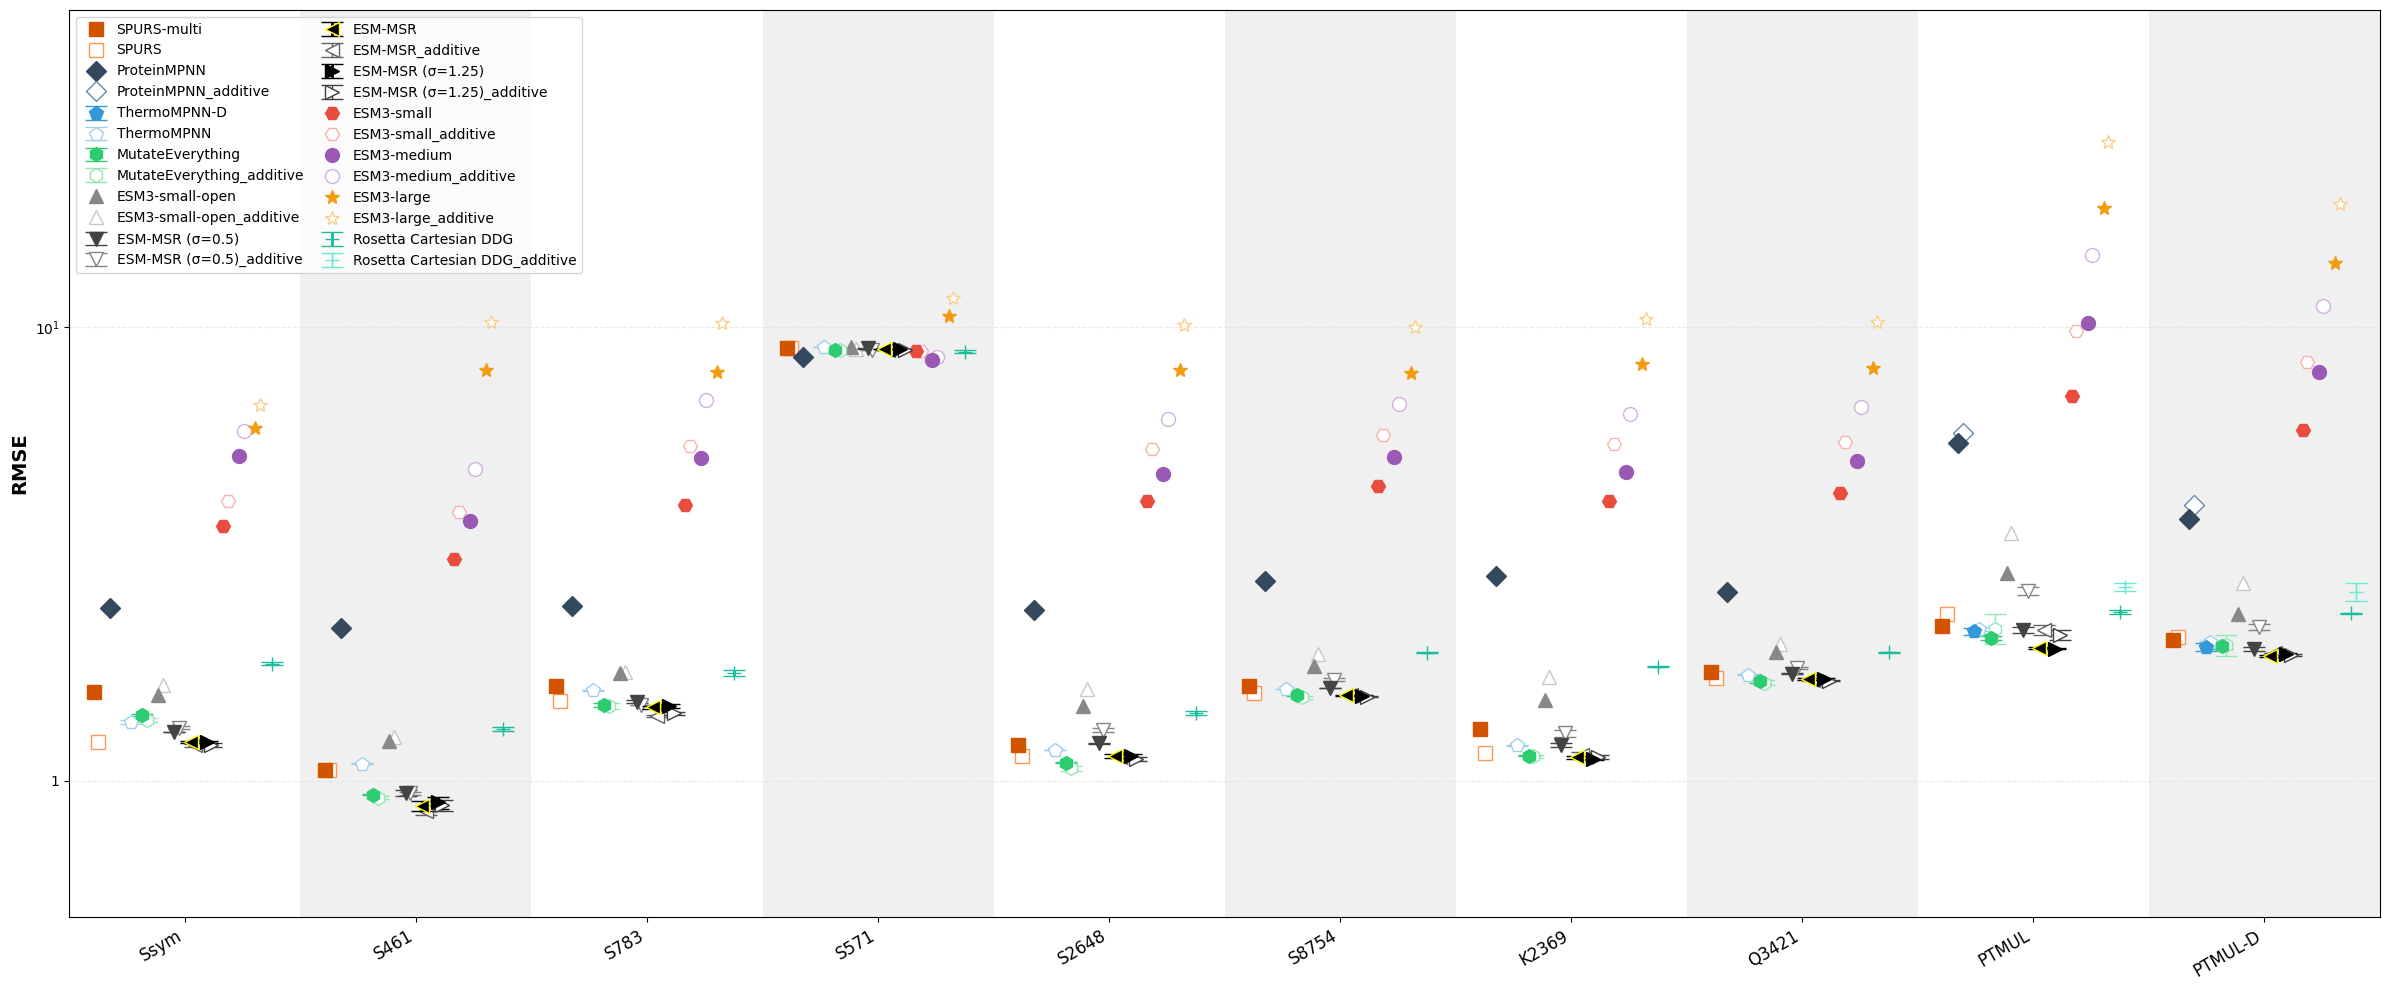

In [12]:
import importlib
importlib.reload(analysis_utils_msr)

df_rmse_custom = df_rmse.copy(deep=True)
df_rmse_custom.rename({'ssym': 'Ssym', 's461': 'S461', 'k2369': 'K2369', 'q3421': 'Q3421', 'ptmuld': 'PTMUL-D',
                      's571': 'S571', 's783': 'S783', 's8754': 'S8754', 's2648': 'S2648',
                      'hyperopt_splits-val': 'Megascale Validation\n(per-domain avg.)',
                      'hyperopt_splits-test': 'Megascale Test\n(per-domain avg.)',
                      'ESTA_BACSU_Nutschel_2020_dTm': 'Nutschel EstA ΔT_50',
                      'GB1_Wu_2016_binding_domain': 'Wu GB1 Binding',
                      'MYO_HUMAN_Kung_2025_display': 'Küng Myoglobin Display',
                      'DLG4_HUMAN_Faure_2021_abundance_domain': 'Faure DLG4 Abundance',
                      'DLG4_HUMAN_Faure_2021_binding_domain': 'Faure DLG4 Binding',
                      'GRB2_HUMAN_Faure_2021_abundance_domain': 'Faure GRB2 Abundance',
                      'GRB2_HUMAN_Faure_2021_binding_domain': 'Faure GRB2 Binding',
                      'domainome': 'Beltran Domainome Abundance\n(per-domain avg.)'}, inplace=True)
df_rmse_custom = df_rmse_custom

fig, ax = analysis_utils_msr.visualize_model_performance(df_rmse_custom.loc[['Ssym', 'S461', 'S783', 'S571', 'S2648', 'S8754', 'K2369', 'Q3421', 'PTMUL', 'PTMUL-D']], 
                                    title=None, ylabel='RMSE', highlighted_model='ESM-MSR', figsize=(24, 10), ylim=(0.5, 50), legend_loc='upper left', group_spread=0.07, yscale='symlog',
                                    colors=['#d35400','#34495e', '#3498db', '#2ecc71', "#888888", "#444444", "#222222", "#000000", '#e74c3c', '#9b59b6', '#f39c12', '#1abc9c', '#d35400',], additive_offset=0.02)

In [13]:
df_rho_custom = df_rho.copy(deep=True)
df_rho_custom.rename({'ssym': 'Ssym', 's461': 'S461', 'k2369': 'K2369', 'q3421': 'Q3421', 'ptmuld': 'PTMUL-D',
                      's571': 'S571', 's783': 'S783', 's8754': 'S8754', 's2648': 'S2648',
                      'hyperopt_splits-val': 'Megascale Validation\n(per-domain avg.)',
                      'hyperopt_splits-test': 'Megascale Test\n(per-domain avg.)',
                      'ESTA_BACSU_Nutschel_2020_dTm': 'Nutschel EstA ΔT_50',
                      'GB1_Wu_2016_binding_domain': 'Wu GB1 Binding',
                      'MYO_HUMAN_Kung_2025_display': 'Küng Myoglobin Display',
                      'DLG4_HUMAN_Faure_2021_abundance_domain': 'Faure DLG4 Abundance',
                      'DLG4_HUMAN_Faure_2021_binding_domain': 'Faure DLG4 Binding',
                      'GRB2_HUMAN_Faure_2021_abundance_domain': 'Faure GRB2 Abundance',
                      'GRB2_HUMAN_Faure_2021_binding_domain': 'Faure GRB2 Binding',
                      'domainome': 'Beltran Domainome Abundance\n(per-domain avg.)'}, inplace=True)
df_rho_custom = df_rho_custom

In [14]:
df_rho_custom.to_csv('/home/sareeves/software/esm-msr/external_test.csv')

In [15]:
df_rho_custom

,SPURS,SPURS-multi,ProteinMPNN_additive,ProteinMPNN,ThermoMPNN_1,ThermoMPNN_2,ThermoMPNN_3,ThermoMPNN-D_1,ThermoMPNN-D_2,ThermoMPNN-D_3,...,ESM3-large_additive,ESM3-small,ESM3-medium,ESM3-large,Rosetta Cartesian DDG_additive_1,Rosetta Cartesian DDG_additive_2,Rosetta Cartesian DDG_additive_3,Rosetta Cartesian DDG_1,Rosetta Cartesian DDG_2,Rosetta Cartesian DDG_3
Wu GB1 Binding,0.329866,0.257912,0.116154,0.136236,0.653674,0.661789,0.658846,0.561983,0.634715,0.608434,...,-0.041876,-0.049211,-0.038360,-0.012988,NaN,NaN,NaN,NaN,NaN,NaN
PTMUL,0.399556,0.359078,0.368905,0.377120,0.436558,0.462835,0.431653,0.451837,0.453192,0.412547,...,0.001297,0.316416,0.249900,0.042657,0.463504,0.489994,0.479552,0.539975,0.544326,0.545799
PTMUL-D,0.494933,0.465539,0.541864,0.544860,0.501528,0.514731,0.505011,0.563160,0.552702,0.529823,...,0.138464,0.441591,0.339018,0.144519,0.378529,0.415172,0.398276,0.471994,0.472259,0.474849
s669,0.501996,0.459206,NaN,0.327759,0.482985,0.479024,0.483750,NaN,NaN,NaN,...,0.278792,0.315384,0.323017,0.275160,NaN,NaN,NaN,0.431066,0.398201,0.412770
S461,0.654484,0.610066,NaN,0.441349,0.646886,0.653903,0.651478,NaN,NaN,NaN,...,0.349811,0.444854,0.421786,0.370618,NaN,NaN,NaN,0.617269,0.610757,0.608883
Ssym,0.783588,0.757726,NaN,0.693955,0.726696,0.709550,0.709090,NaN,NaN,NaN,...,0.520990,0.593735,0.616974,0.497899,NaN,NaN,NaN,0.621382,0.620038,0.614715
Q3421,0.614243,0.593583,NaN,0.494793,0.603618,0.595183,0.599979,NaN,NaN,NaN,...,0.316541,0.429053,0.414038,0.282215,NaN,NaN,NaN,0.553649,0.552825,0.555358
k3822,0.680844,0.627234,NaN,0.419894,0.657598,0.650912,0.647986,NaN,NaN,NaN,...,0.307975,0.463788,0.463298,0.281041,NaN,NaN,NaN,0.627742,0.624456,0.624133
K2369,0.698476,0.649764,NaN,0.435200,0.658931,0.654638,0.648975,NaN,NaN,NaN,...,0.359110,0.488280,0.476536,0.317996,NaN,NaN,NaN,0.617860,0.615500,0.613826
S571,0.476698,0.437820,NaN,0.336043,0.419626,0.407346,0.419417,NaN,NaN,NaN,...,0.207520,0.249286,0.340929,0.196059,NaN,NaN,NaN,0.356703,0.364484,0.350239


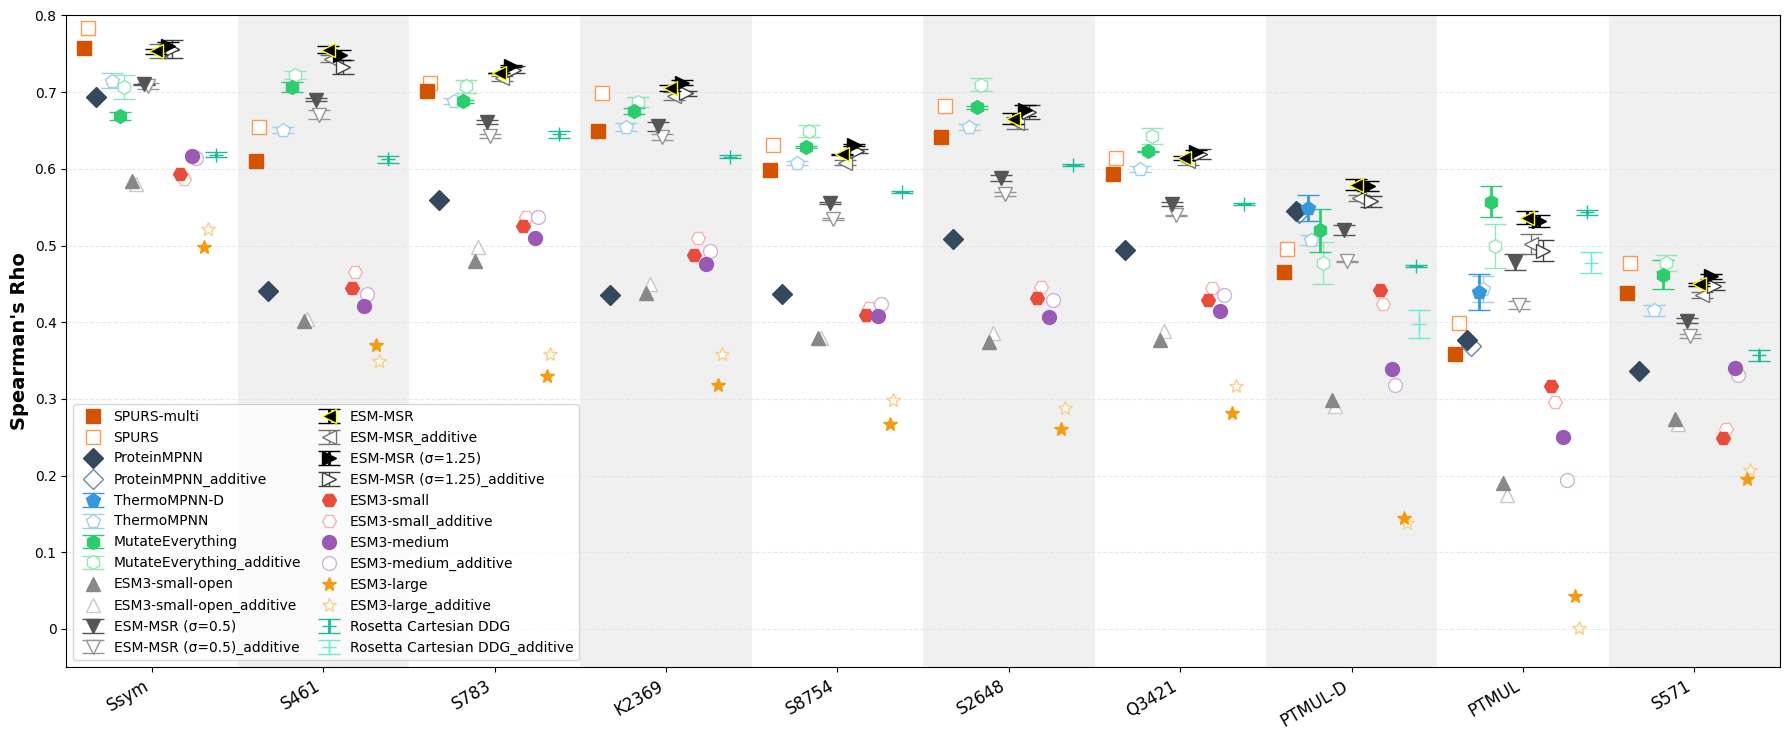

In [16]:
fig, ax = analysis_utils_msr.visualize_model_performance(df_rho_custom.loc[['Ssym', 'S461', 'S783', 'K2369', 'S8754', 'S2648', 'Q3421', 'PTMUL-D', 'PTMUL', 'S571']], 
                                    title=None, ylabel='Spearman\'s Rho', figsize=(18, 7.5), highlighted_model='ESM-MSR', group_spread=0.07, ylim=(-0.05,0.8),
                                    colors=['#d35400', '#34495e', '#3498db', '#2ecc71',  "#888888", "#555555", "#333333", "#000000", '#e74c3c', '#9b59b6', '#f39c12', '#1abc9c',], additive_offset=0.02)

In [17]:
df_rho_custom.loc[['Megascale Validation\n(per-domain avg.)', 'Megascale Test\n(per-domain avg.)'], ['SPURS-multi', 'SPURS']] = np.nan

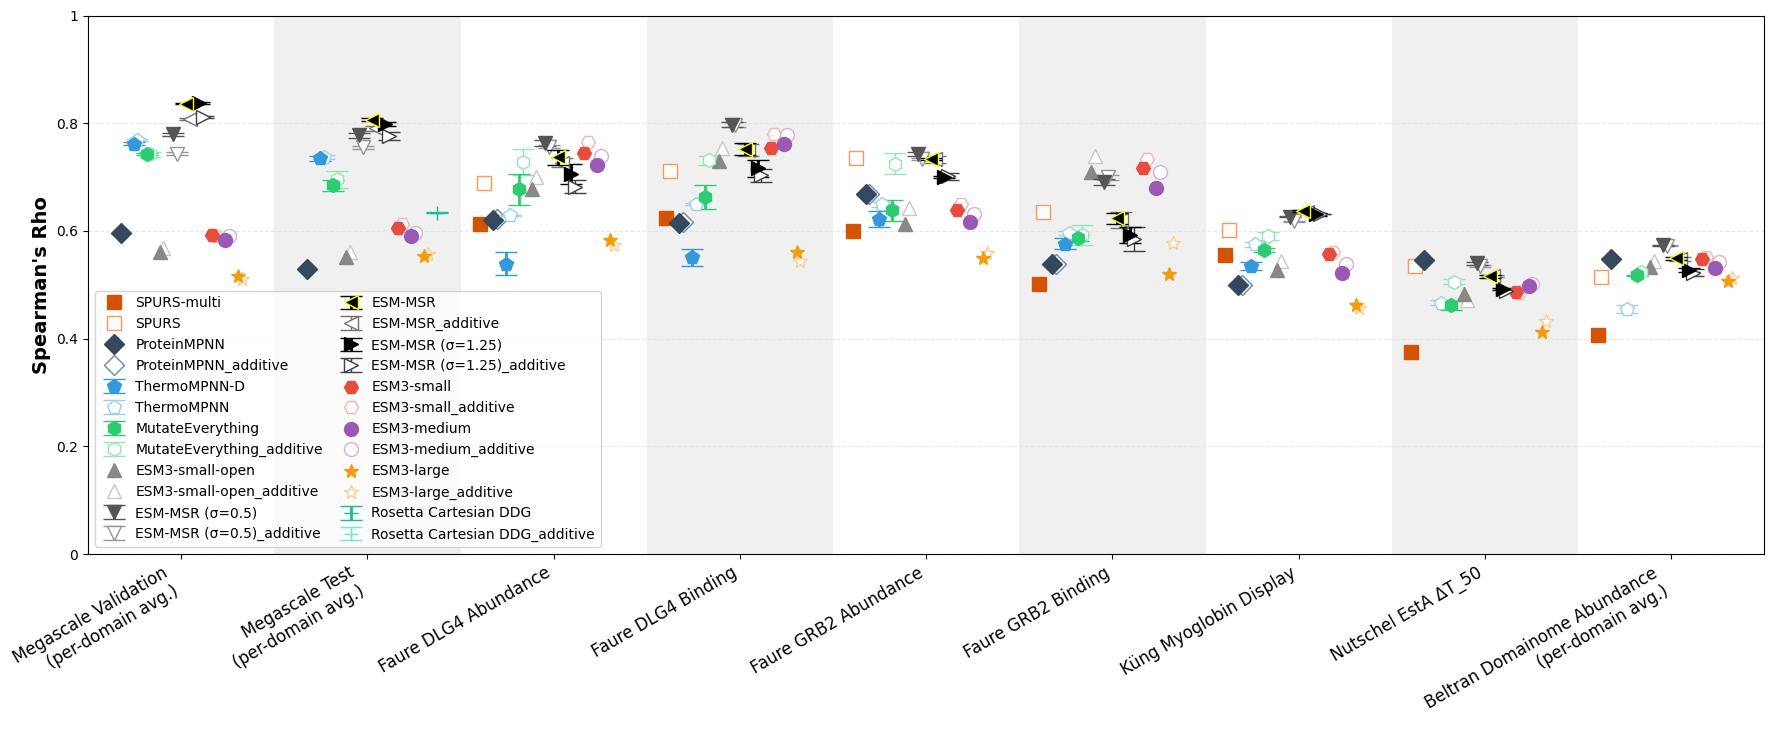

In [18]:
fig, ax = analysis_utils_msr.visualize_model_performance(df_rho_custom.loc[['Megascale Validation\n(per-domain avg.)', 'Megascale Test\n(per-domain avg.)', 'Faure DLG4 Abundance', 'Faure DLG4 Binding', 'Faure GRB2 Abundance', 'Faure GRB2 Binding', 'Küng Myoglobin Display', 'Nutschel EstA ΔT_50', 'Beltran Domainome Abundance\n(per-domain avg.)']], 
                                    title=None, ylabel='Spearman\'s Rho', highlighted_model='ESM-MSR', figsize=(18, 7.5), group_spread=0.07, ylim=(0,1), legend_loc=None,
                                    colors=['#d35400', '#34495e', '#3498db', '#2ecc71', "#888888", "#555555", "#333333", "#000000", '#e74c3c', '#9b59b6', '#f39c12', '#1abc9c', '#d35400',], additive_offset=0.02)

In [19]:
df_rho_custom.loc['Beltran Domainome Abundance\n(per-domain avg.)', :]

SPURS                               0.513666
SPURS-multi                         0.406012
ProteinMPNN_additive                     NaN
ProteinMPNN                         0.547869
ThermoMPNN_1                        0.461882
ThermoMPNN_2                        0.447233
ThermoMPNN_3                        0.456450
ThermoMPNN-D_1                           NaN
ThermoMPNN-D_2                           NaN
ThermoMPNN-D_3                           NaN
MutateEverything_additive_1         0.523193
MutateEverything_additive_2         0.524595
MutateEverything_additive_3         0.523804
MutateEverything_1                  0.516184
MutateEverything_2                  0.518385
MutateEverything_3                  0.517483
ESM3-small-open_additive            0.544762
ESM3-small-open                     0.533499
ESM-MSR (σ=0.5)_additive_1          0.571728
ESM-MSR (σ=0.5)_additive_2          0.572029
ESM-MSR (σ=0.5)_additive_3          0.573104
ESM-MSR (σ=0.5)_1                   0.572784
ESM-MSR (σ

In [20]:
df_gain_custom = df_gain_per_mut.copy(deep=True)
df_gain_custom.rename({'ssym': 'Ssym', 's461': 'S461', 'k2369': 'K2369', 'q3421': 'Q3421', 'ptmuld': 'PTMUL-D',
                      's571': 'S571', 's783': 'S783', 's8754': 'S8754', 's2648': 'S2648',
                      'ESTA_BACSU_Nutschel_2020_dTm': 'Nutschel EstA ΔT_50',
                      'GB1_Wu_2016_binding_domain': 'Wu GB1 Binding',
                      'MYO_HUMAN_Kung_2025_display': 'Küng Myoglobin Display',
                      'DLG4_HUMAN_Faure_2021_abundance_domain': 'Faure DLG4 abundance',
                      'DLG4_HUMAN_Faure_2021_binding_domain': 'Faure DLG4 binding',
                      'GRB2_HUMAN_Faure_2021_abundance_domain': 'Faure GRB2 abundance',
                      'GRB2_HUMAN_Faure_2021_binding_domain': 'Faure GRB2 binding',
                      'domainome': 'Beltran Domainome abundance*\n(grouped)'}, inplace=True)
df_gain_custom = df_gain_custom

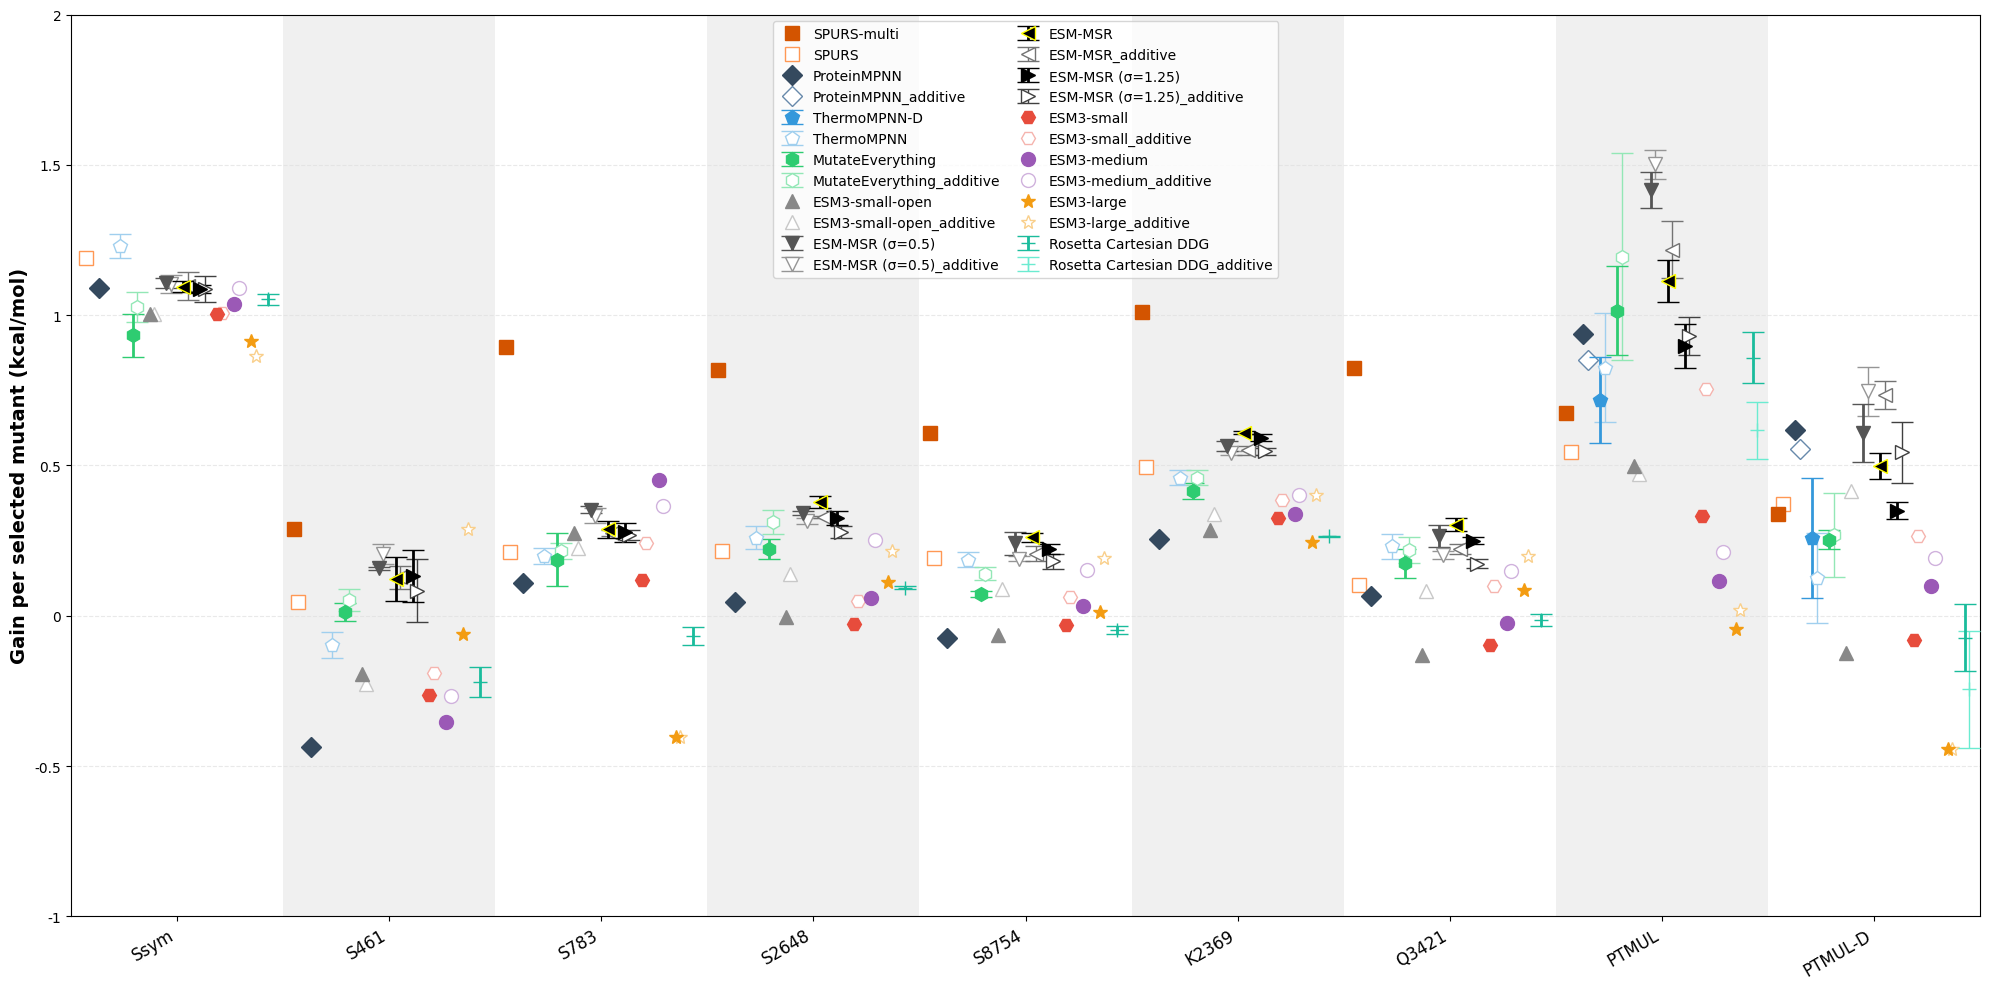

In [21]:
fig, ax = analysis_utils_msr.visualize_model_performance(df_gain_custom.loc[['Ssym', 'S461', 'S783', 'S2648', 'S8754', 'K2369', 'Q3421', 'PTMUL', 'PTMUL-D']], #'S571'
                                    title=None, ylabel='Gain per selected mutant (kcal/mol)', figsize=(20, 10), highlighted_model='ESM-MSR', group_spread=0.08, ylim=(-1, 2), legend_loc='upper center',
                                    colors=['#d35400', '#34495e', '#3498db', '#2ecc71',  "#888888", "#555555", "#333333", "#000000", '#e74c3c', '#9b59b6', '#f39c12', '#1abc9c',], additive_offset=0.02)

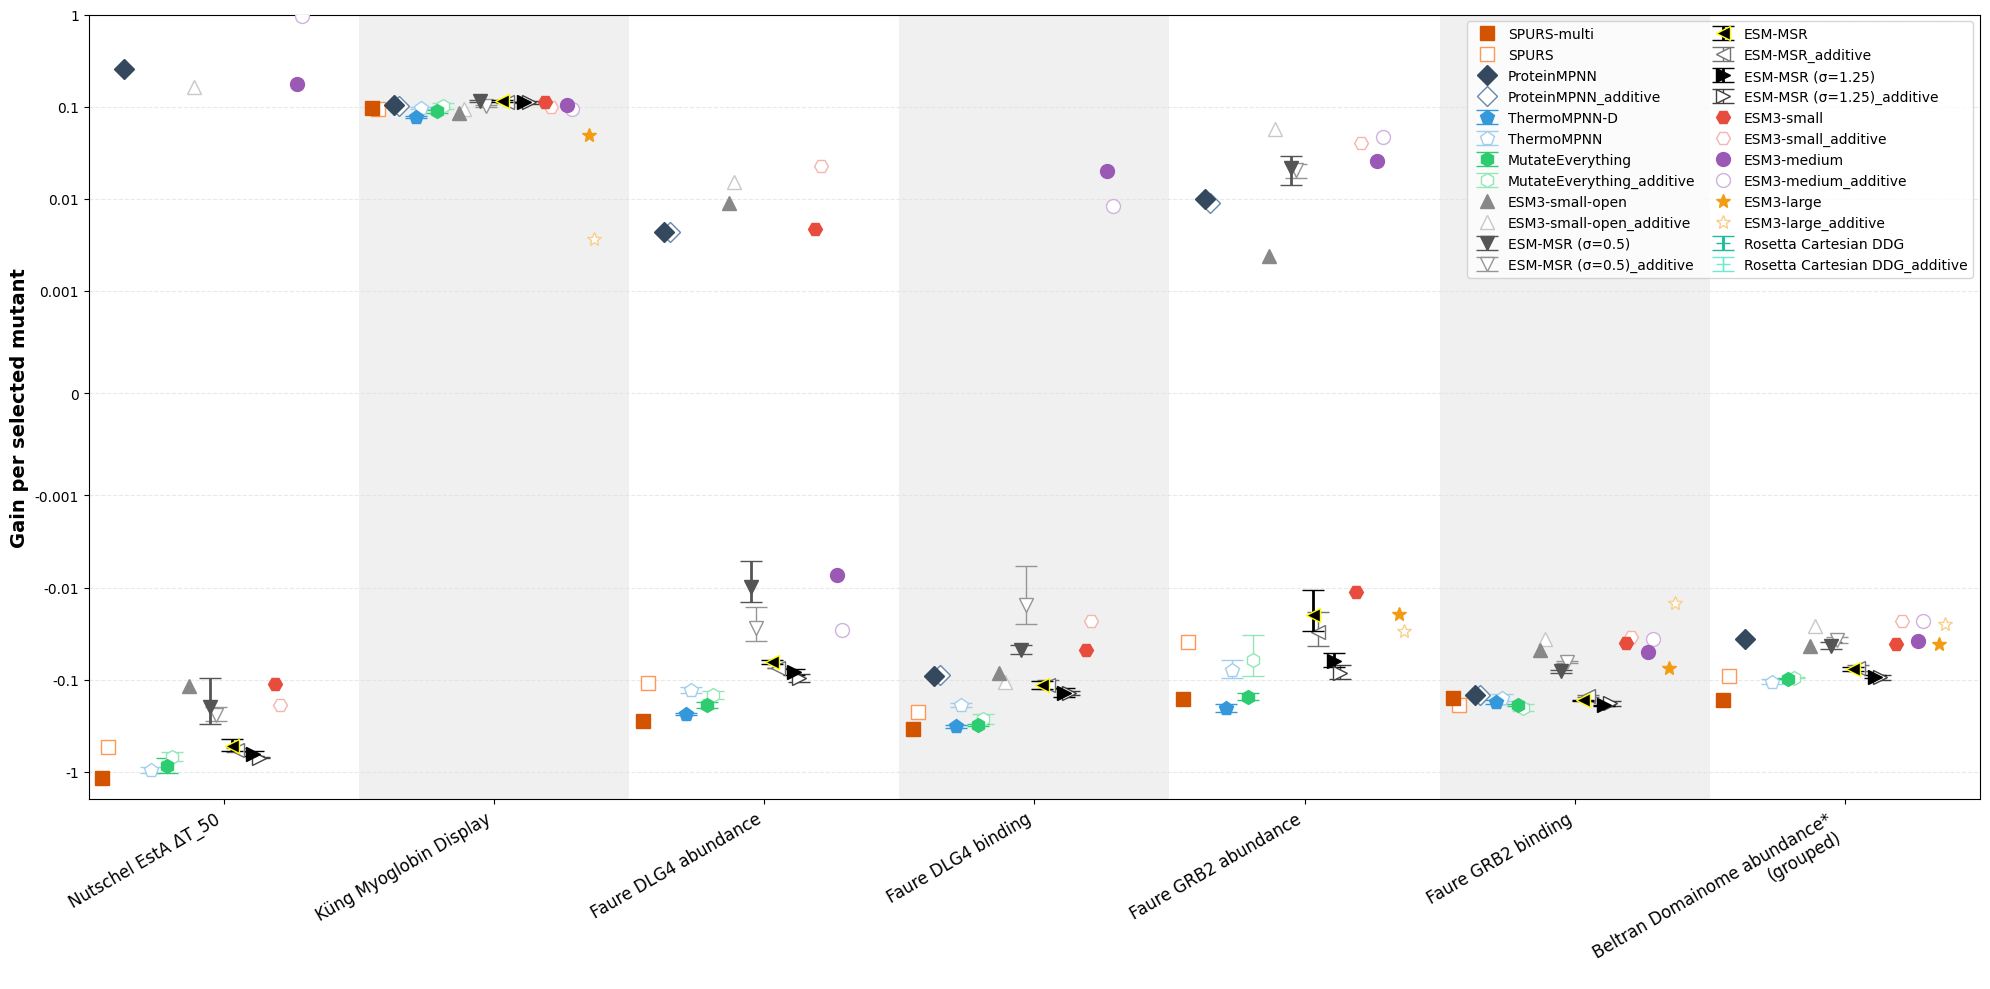

In [22]:
fig, ax = analysis_utils_msr.visualize_model_performance(df_gain_custom.loc[['Nutschel EstA ΔT_50', 'Küng Myoglobin Display', 'Faure DLG4 abundance', 'Faure DLG4 binding', 'Faure GRB2 abundance', 'Faure GRB2 binding', 'Beltran Domainome abundance*\n(grouped)']], 
                                    title=None, ylabel='Gain per selected mutant', highlighted_model='ESM-MSR', group_spread=0.08, figsize=(20, 10), ylim=(-2, 1), yscale='symlog', legend_loc='upper right',
                                    colors=['#d35400', '#34495e', '#3498db', '#2ecc71',  "#888888", "#555555", "#333333", "#000000", '#e74c3c', '#9b59b6', '#f39c12', '#1abc9c', '#d35400',], additive_offset=0.02)

In [23]:
df_gain_custom = df_gain_all.copy(deep=True)
df_gain_custom.rename({'ssym': 'Ssym', 's461': 'S461', 'k2369': 'K2369', 'q3421': 'Q3421', 'ptmuld': 'PTMUL-D',
                      's571': 'S571', 's783': 'S783', 's8754': 'S8754', 's2648': 'S2648',
                      'ESTA_BACSU_Nutschel_2020_dTm': 'Nutschel EstA ΔT_50',
                      'GB1_Wu_2016_binding_domain': 'Wu GB1 Binding',
                      'MYO_HUMAN_Kung_2025_display': 'Küng Myoglobin Display',
                      'DLG4_HUMAN_Faure_2021_abundance_domain': 'Faure DLG4 abundance',
                      'DLG4_HUMAN_Faure_2021_binding_domain': 'Faure DLG4 binding',
                      'GRB2_HUMAN_Faure_2021_abundance_domain': 'Faure GRB2 abundance',
                      'GRB2_HUMAN_Faure_2021_binding_domain': 'Faure GRB2 binding',
                      'domainome': 'Beltran Domainome abundance*\n(grouped)'}, inplace=True)
df_gain_custom = df_gain_custom

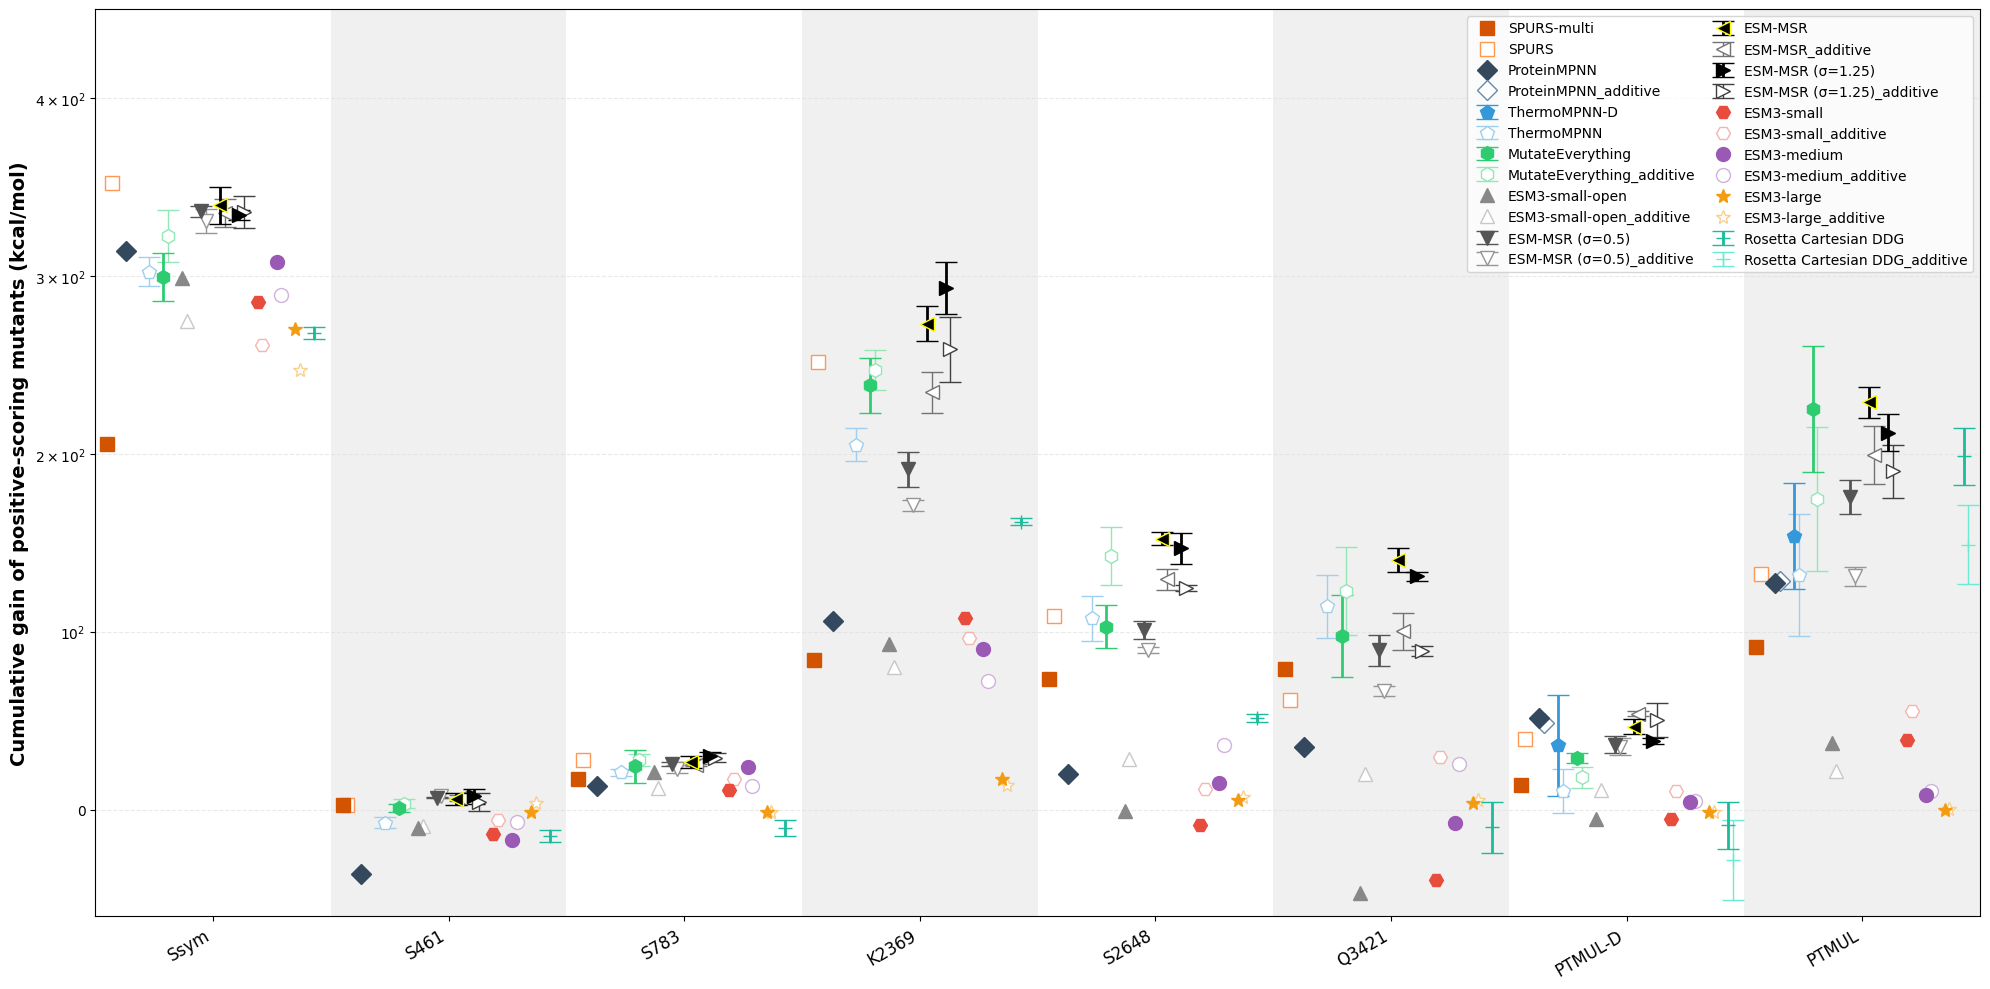

In [24]:
fig, ax = analysis_utils_msr.visualize_model_performance(df_gain_custom.loc[['Ssym', 'S461', 'S783', 'K2369', 'S2648', 'Q3421', 'PTMUL-D', 'PTMUL']], #'S8754', , 'S571'
                                    title=None, ylabel='Cumulative gain of positive-scoring mutants (kcal/mol)', figsize=(20, 10), highlighted_model='ESM-MSR', group_spread=0.08, ylim=(-60, 450), legend_loc='upper right',
                                    colors=['#d35400', '#34495e', '#3498db', '#2ecc71',  "#888888", "#555555", "#333333", "#000000", '#e74c3c', '#9b59b6', '#f39c12', '#1abc9c',], additive_offset=0.02)

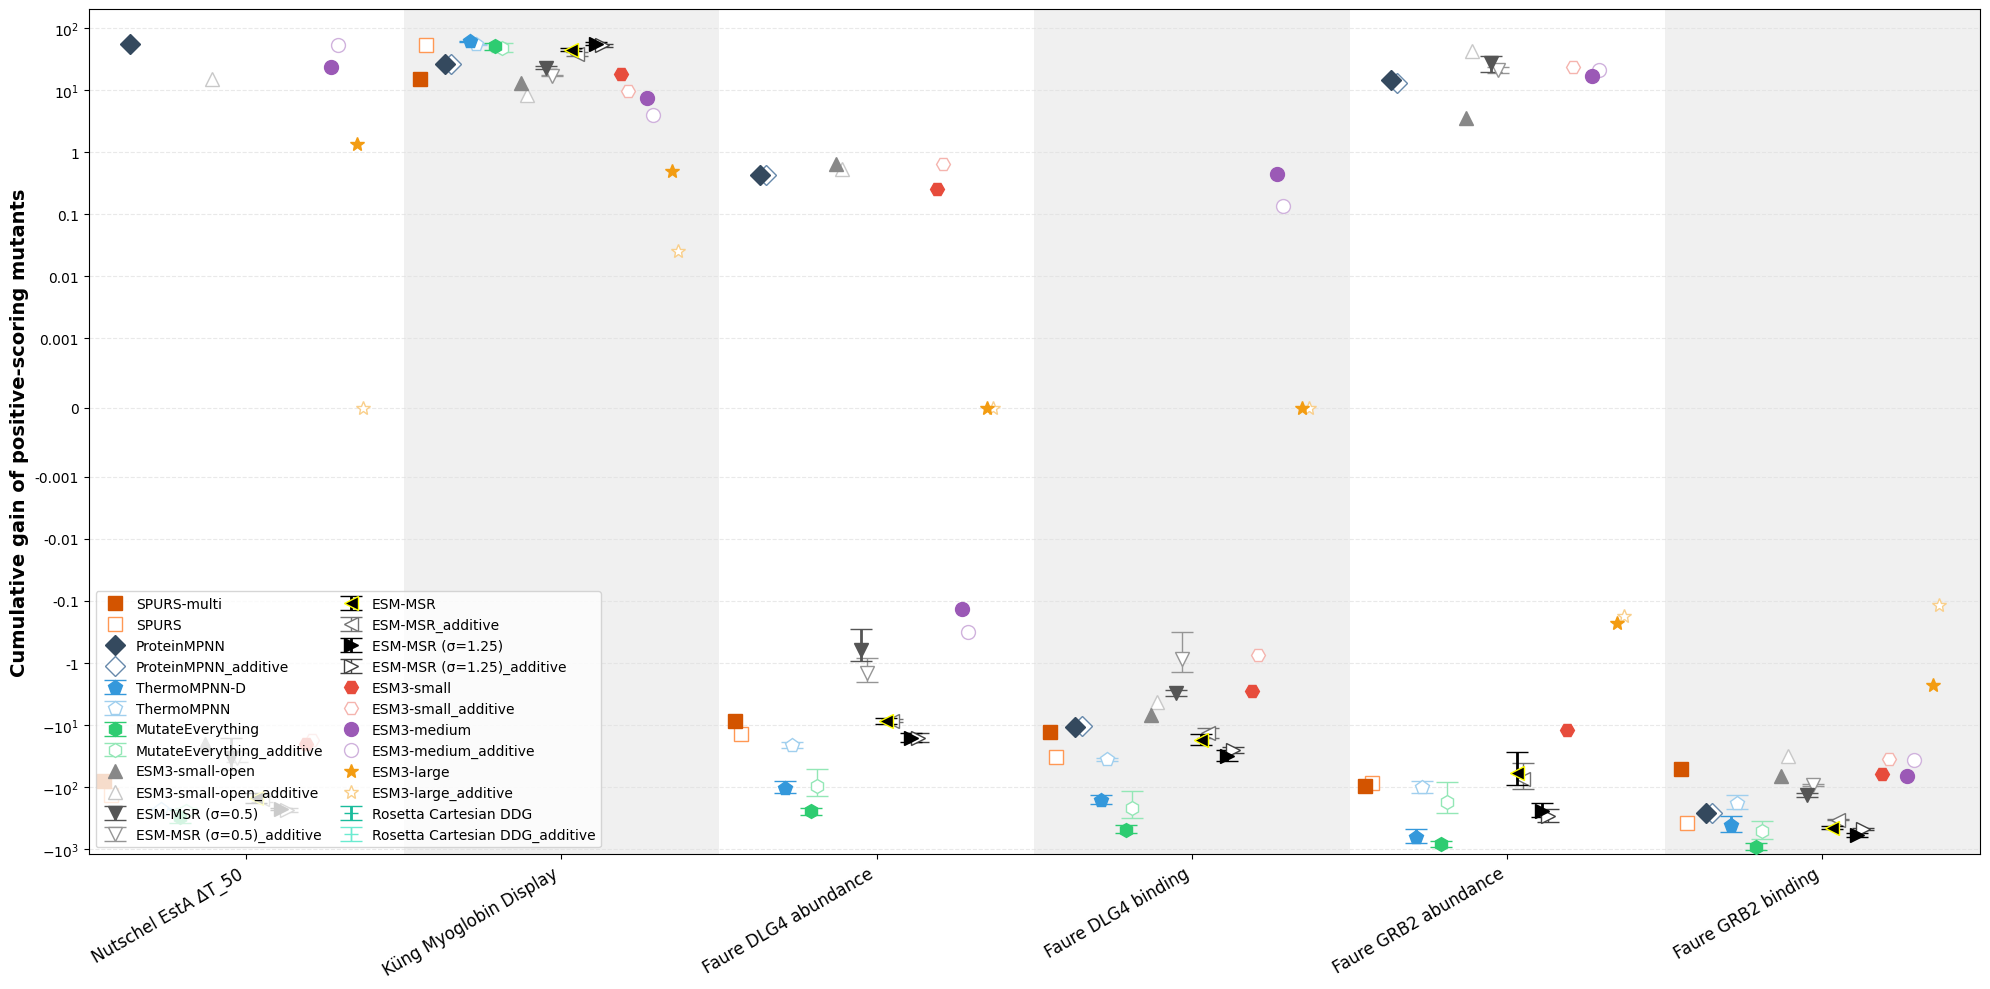

In [25]:
fig, ax = analysis_utils_msr.visualize_model_performance(df_gain_custom.loc[['Nutschel EstA ΔT_50', 'Küng Myoglobin Display', 'Faure DLG4 abundance', 'Faure DLG4 binding', 'Faure GRB2 abundance', 'Faure GRB2 binding']], #'Beltran Domainome abundance*\n(grouped)'
                                    title=None, ylabel='Cumulative gain of positive-scoring mutants', highlighted_model='ESM-MSR', figsize=(20, 10), ylim=(-1200, 200), group_spread=0.08, yscale='symlog',
                                    colors=['#d35400', '#34495e', '#3498db', '#2ecc71',  "#888888", "#555555", "#333333", "#000000", '#e74c3c', '#9b59b6', '#f39c12', '#1abc9c', '#d35400',], additive_offset=0.02)

In [26]:
df_gain_custom = df_gain_all_rect.copy(deep=True)
df_gain_custom.rename({'ssym': 'Ssym', 's461': 'S461', 'k2369': 'K2369', 'q3421': 'Q3421', 'ptmuld': 'PTMUL-D',
                      's571': 'S571', 's783': 'S783', 's8754': 'S8754', 's2648': 'S2648',
                      'ESTA_BACSU_Nutschel_2020_dTm': 'Nutschel EstA ΔT_50',
                      'GB1_Wu_2016_binding_domain': 'Wu GB1 Binding',
                      'MYO_HUMAN_Kung_2025_display': 'Küng Myoglobin Display',
                      'DLG4_HUMAN_Faure_2021_abundance_domain': 'Faure DLG4 abundance',
                      'DLG4_HUMAN_Faure_2021_binding_domain': 'Faure DLG4 binding',
                      'GRB2_HUMAN_Faure_2021_abundance_domain': 'Faure GRB2 abundance',
                      'GRB2_HUMAN_Faure_2021_binding_domain': 'Faure GRB2 binding',
                      'domainome': 'Beltran Domainome abundance*\n(grouped)'}, inplace=True)
df_gain_custom = df_gain_custom

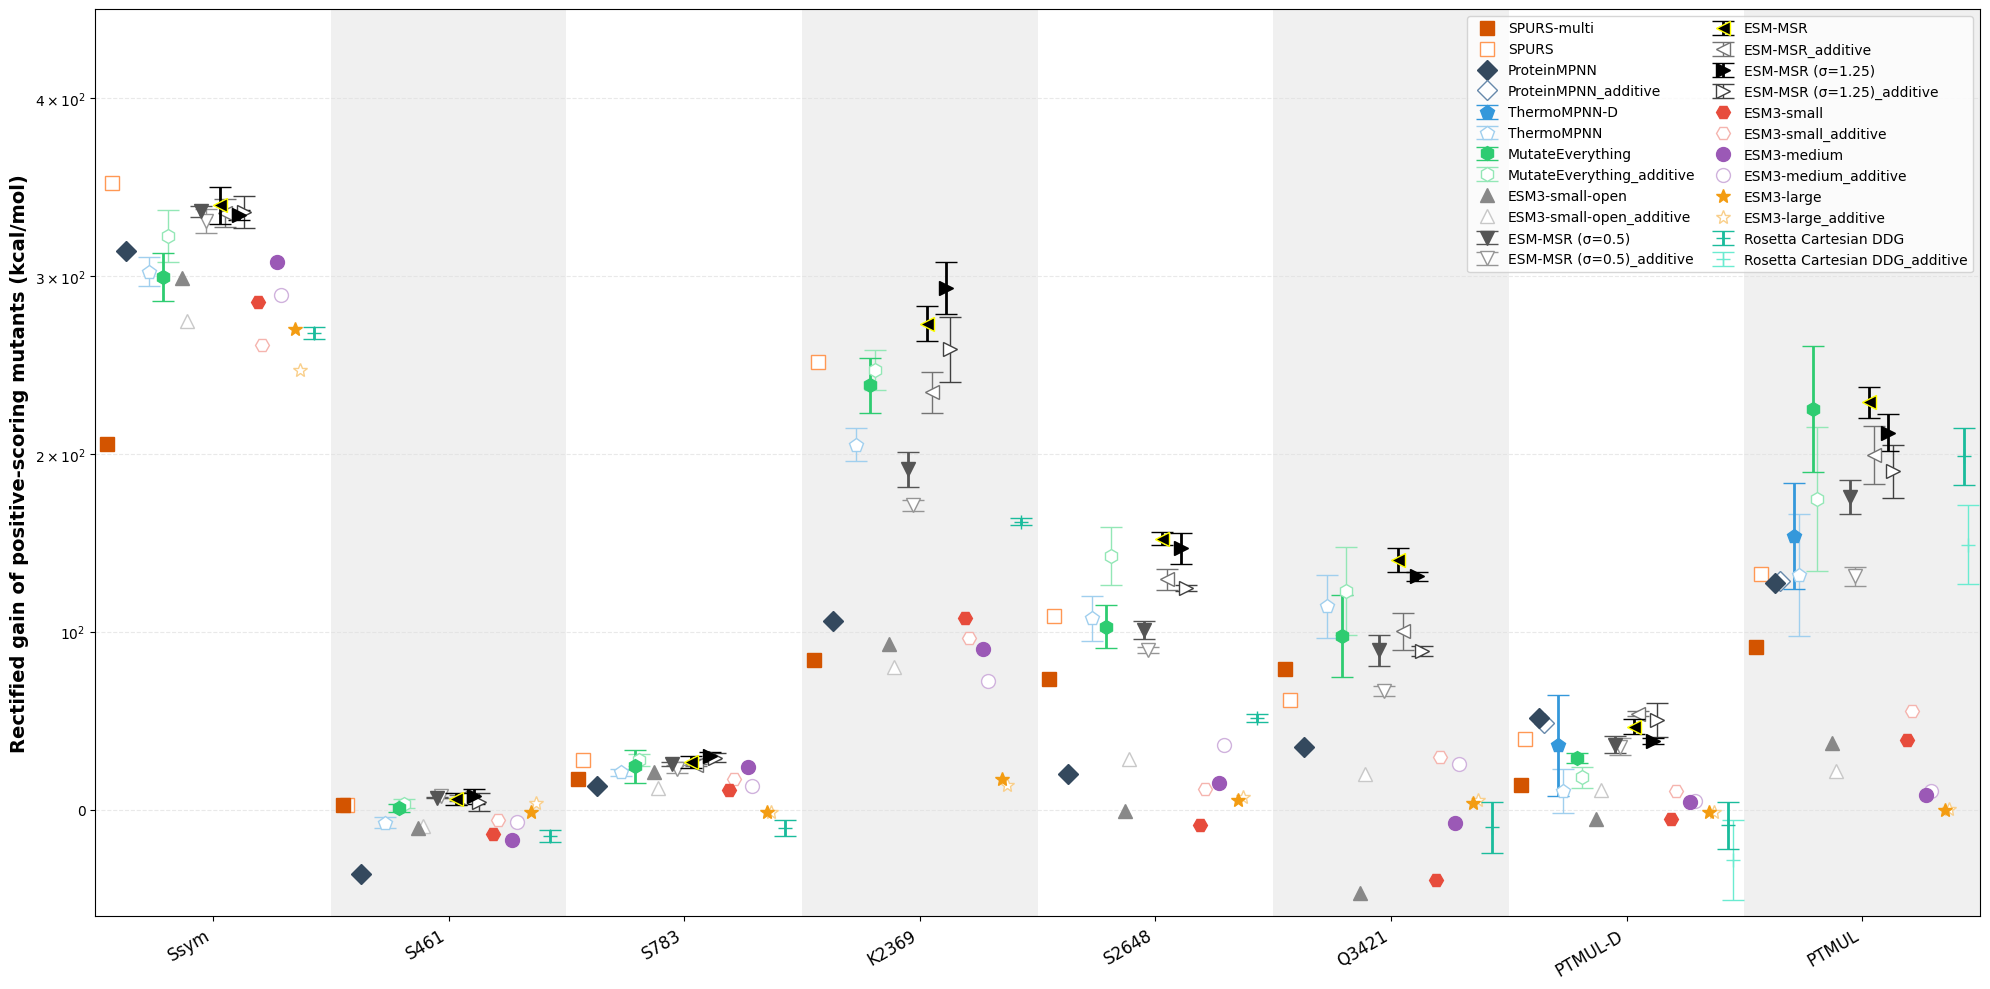

In [27]:
fig, ax = analysis_utils_msr.visualize_model_performance(df_gain_custom.loc[['Ssym', 'S461', 'S783', 'K2369', 'S2648', 'Q3421', 'PTMUL-D', 'PTMUL']], #'S8754', , 'S571'
                                    title=None, ylabel='Rectified gain of positive-scoring mutants (kcal/mol)', figsize=(20, 10), highlighted_model='ESM-MSR', group_spread=0.08, ylim=(-60, 450), legend_loc='upper right',
                                    colors=['#d35400', '#34495e', '#3498db', '#2ecc71',  "#888888", "#555555", "#333333", "#000000", '#e74c3c', '#9b59b6', '#f39c12', '#1abc9c',], additive_offset=0.02)

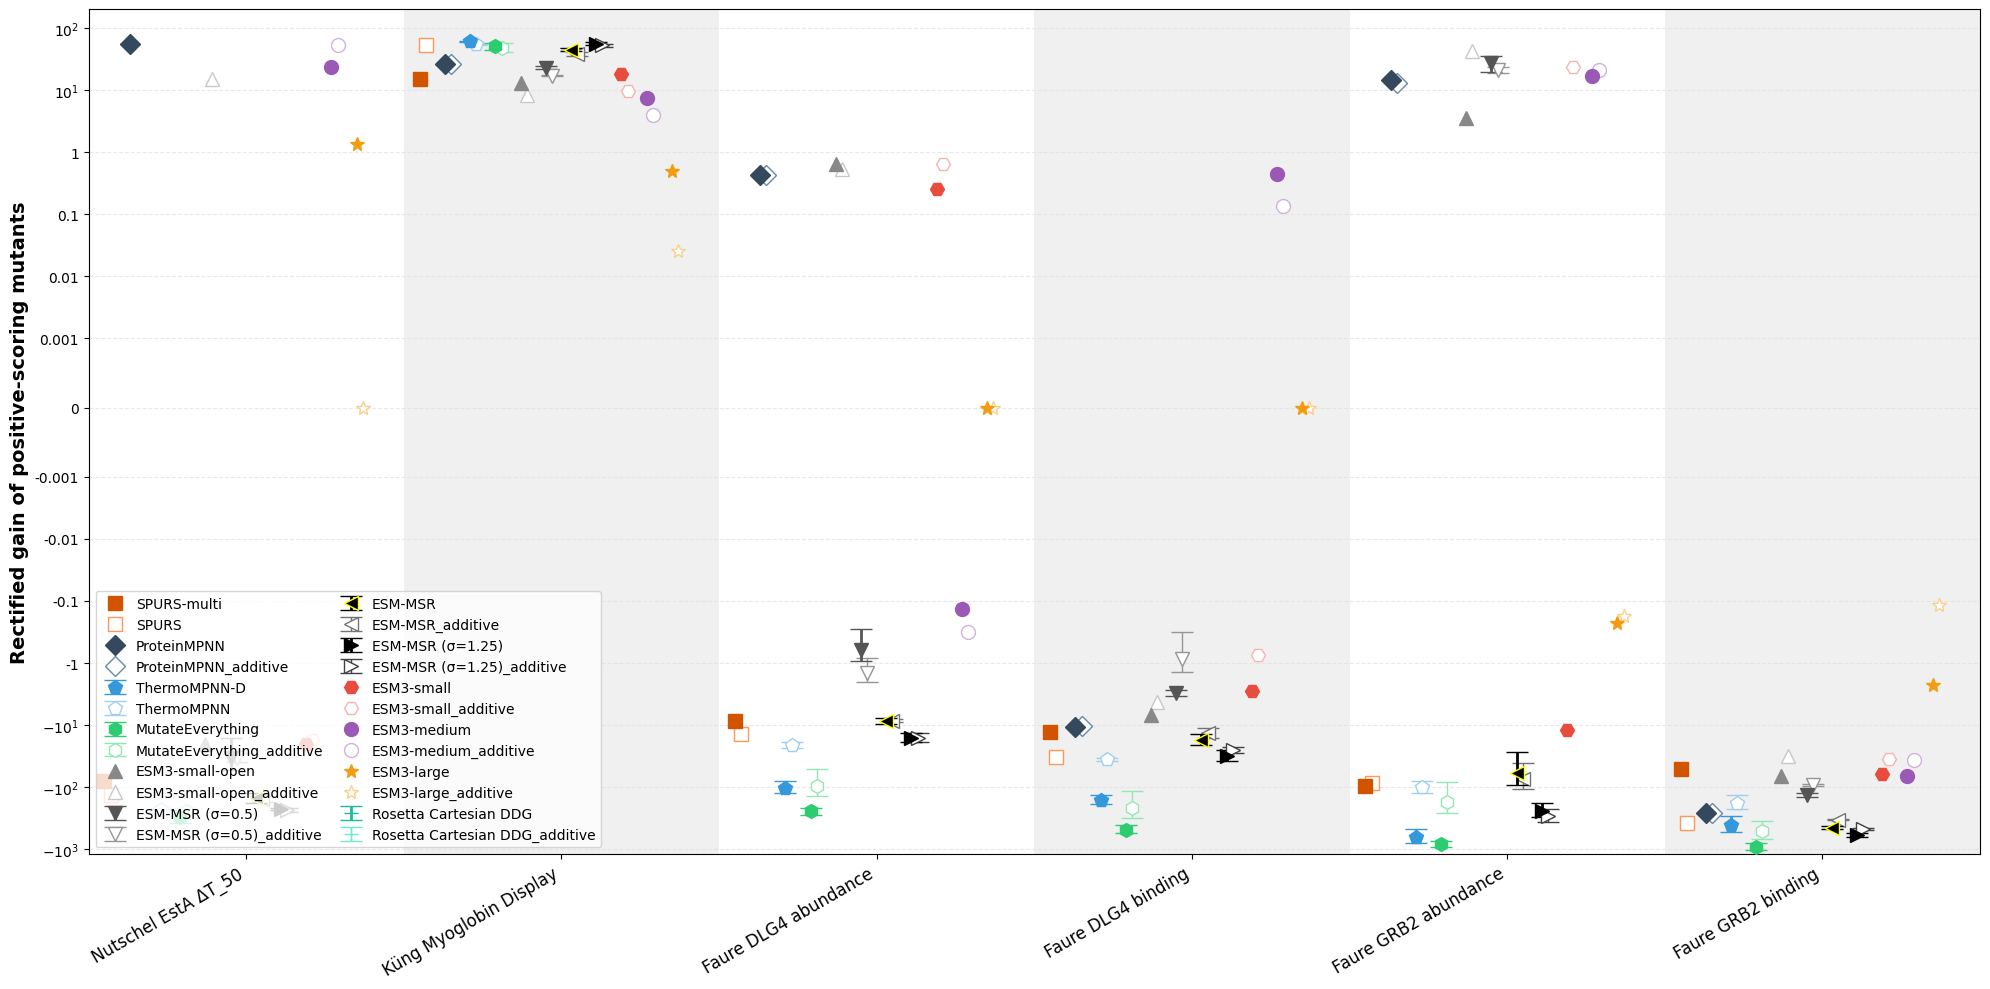

In [28]:
fig, ax = analysis_utils_msr.visualize_model_performance(df_gain_custom.loc[['Nutschel EstA ΔT_50', 'Küng Myoglobin Display', 'Faure DLG4 abundance', 'Faure DLG4 binding', 'Faure GRB2 abundance', 'Faure GRB2 binding']], #'Beltran Domainome abundance*\n(grouped)'
                                    title=None, ylabel='Rectified gain of positive-scoring mutants', highlighted_model='ESM-MSR', figsize=(20, 10), ylim=(-1200, 200), group_spread=0.08, yscale='symlog',
                                    colors=['#d35400', '#34495e', '#3498db', '#2ecc71',  "#888888", "#555555", "#333333", "#000000", '#e74c3c', '#9b59b6', '#f39c12', '#1abc9c', '#d35400',], additive_offset=0.02)

In [29]:
df_ndcg_custom_pos = df_ndcg_pos.copy(deep=True)
df_ndcg_custom_pos.rename({'ssym': 'Ssym', 's461': 'S461', 'k2369': 'K2369', 'q3421': 'Q3421', 'ptmuld': 'PTMUL-D',
                      's571': 'S571', 's783': 'S783', 's8754': 'S8754', 's2648': 'S2648',
                      'ESTA_BACSU_Nutschel_2020_dTm': 'Nutschel EstA ΔT_50',
                      'GB1_Wu_2016_binding_domain': 'Wu GB1 Binding',
                      'MYO_HUMAN_Kung_2025_display': 'Küng Myoglobin Display',
                      'DLG4_HUMAN_Faure_2021_abundance_domain': 'Faure DLG4 abundance',
                      'DLG4_HUMAN_Faure_2021_binding_domain': 'Faure DLG4 binding',
                      'GRB2_HUMAN_Faure_2021_abundance_domain': 'Faure GRB2 abundance',
                      'GRB2_HUMAN_Faure_2021_binding_domain': 'Faure GRB2 binding',
                      'domainome': 'Beltran Domainome abundance*\n(grouped)'}, inplace=True)
df_ndcg_custom_pos = df_ndcg_custom_pos

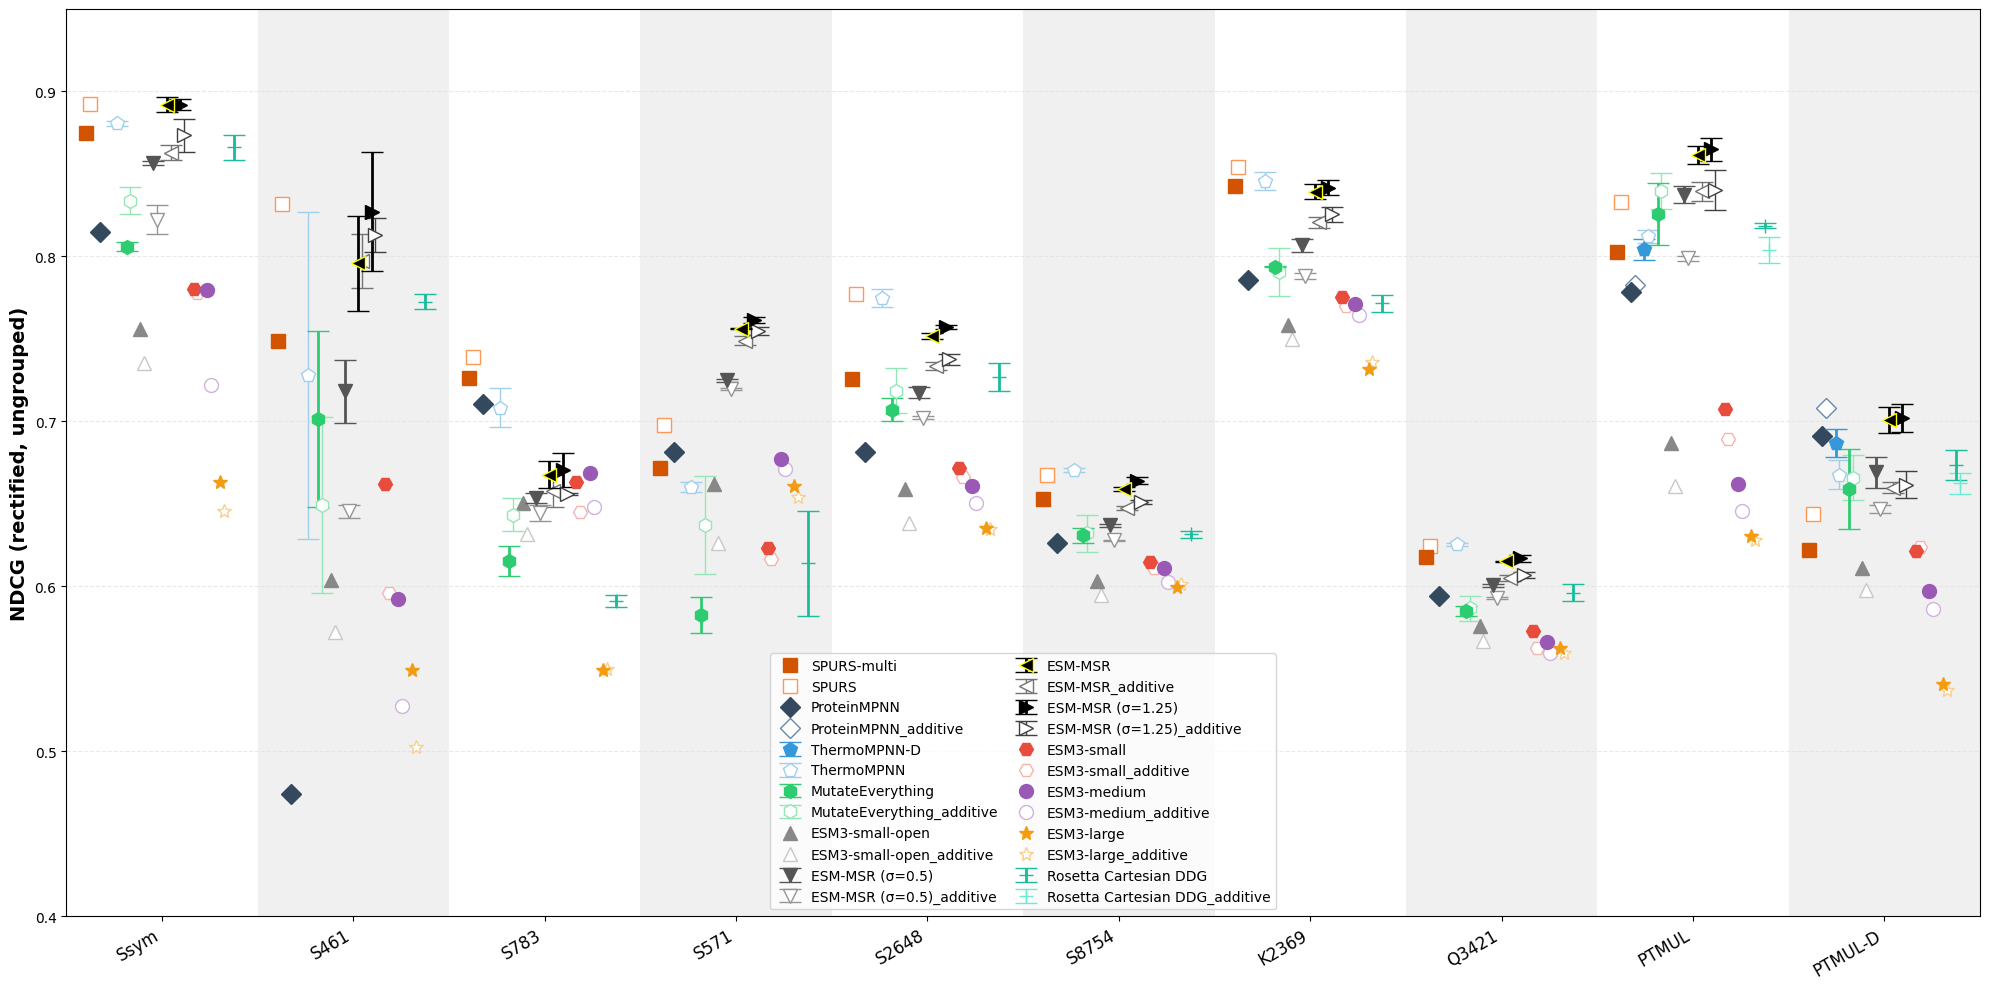

In [30]:
fig, ax = analysis_utils_msr.visualize_model_performance(df_ndcg_custom_pos.loc[['Ssym', 'S461', 'S783', 'S571', 'S2648', 'S8754', 'K2369', 'Q3421', 'PTMUL', 'PTMUL-D']], 
                                    title=None, ylabel='NDCG (rectified, ungrouped)', highlighted_model='ESM-MSR', figsize=(20, 10), ylim=(0.4, 0.95), group_spread=(0.07),
                                    colors=['#d35400', '#34495e', '#3498db', '#2ecc71',  "#888888", "#555555", "#333333", "#000000", '#e74c3c', '#9b59b6', '#f39c12', '#1abc9c', '#d35400',], additive_offset=0.02, legend_loc='lower center')

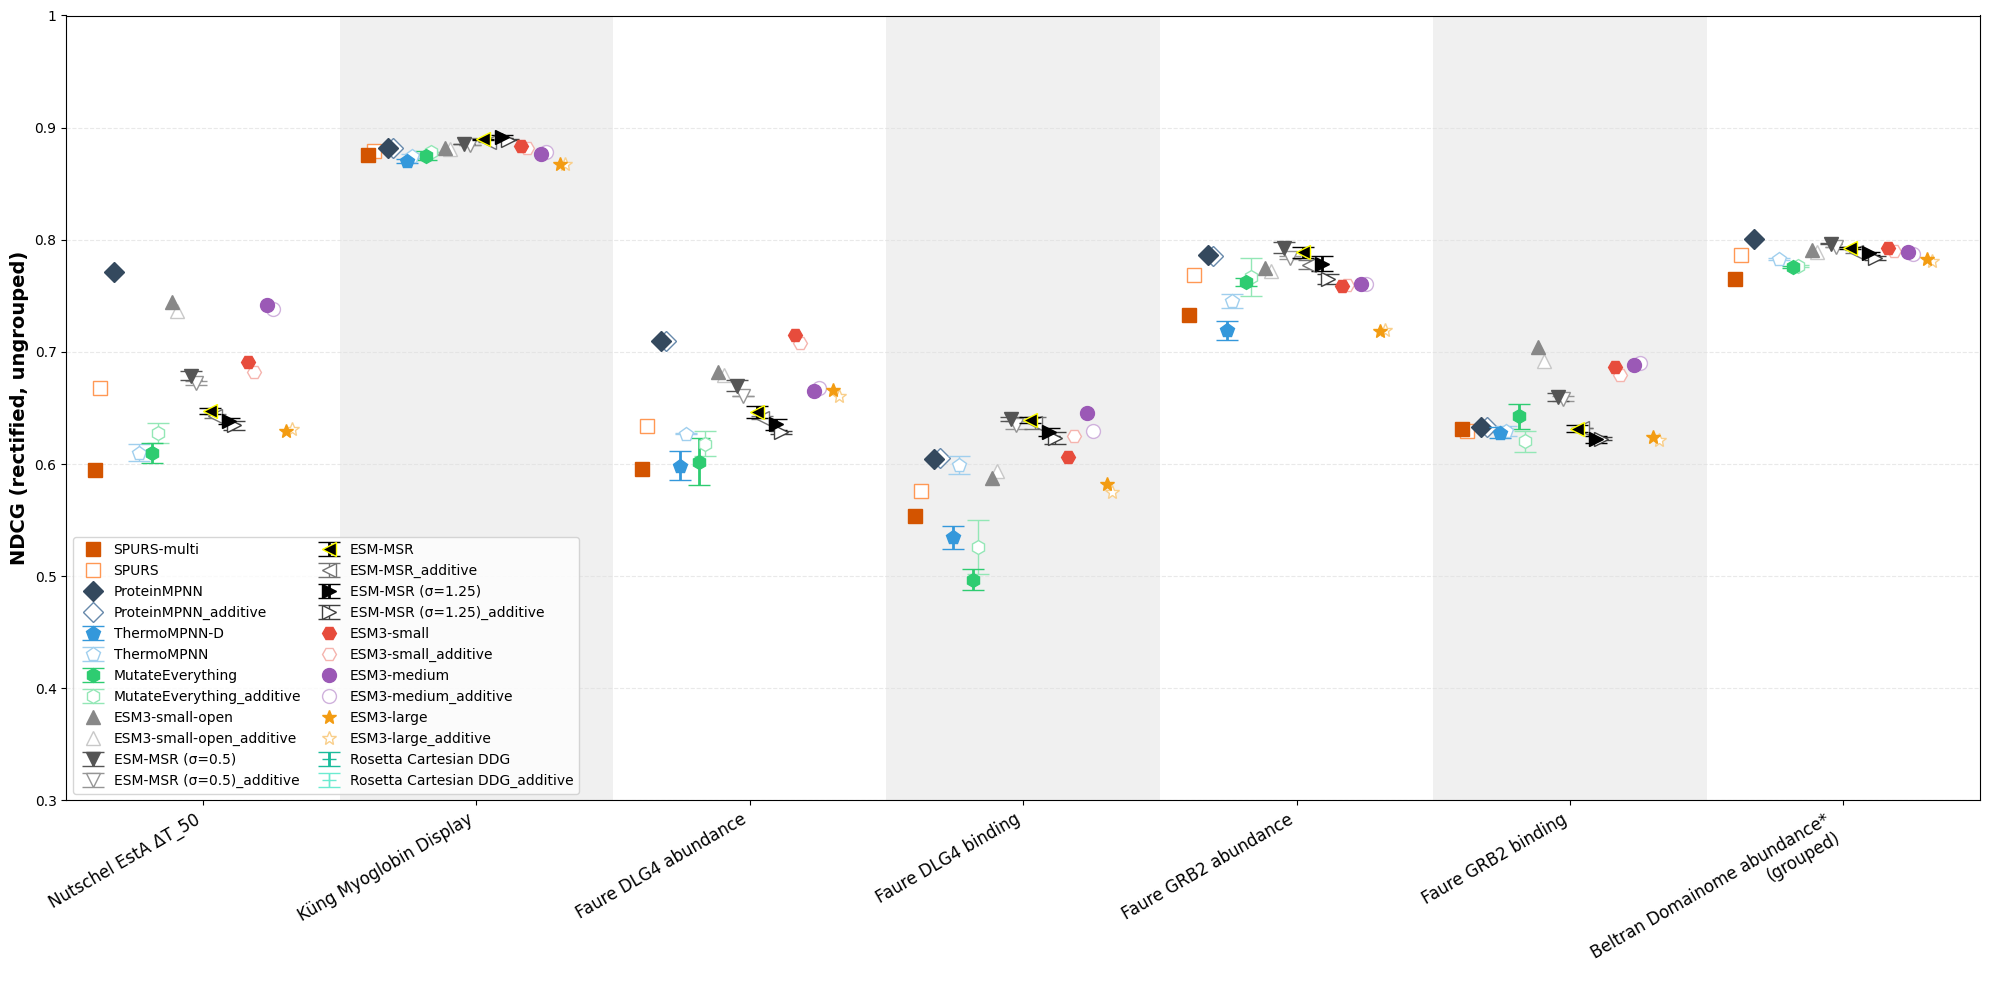

In [31]:
fig, ax = analysis_utils_msr.visualize_model_performance(df_ndcg_custom_pos.loc[['Nutschel EstA ΔT_50', 'Küng Myoglobin Display', 'Faure DLG4 abundance', 'Faure DLG4 binding', 'Faure GRB2 abundance', 'Faure GRB2 binding', 'Beltran Domainome abundance*\n(grouped)']], 
                                    title=None, ylabel='NDCG (rectified, ungrouped)', highlighted_model='ESM-MSR', figsize=(20, 10), ylim=(0.3,1), group_spread=(0.07),
                                    colors=['#d35400', '#34495e', '#3498db', '#2ecc71', "#888888", "#555555", "#333333", "#000000", '#e74c3c', '#9b59b6', '#f39c12', '#1abc9c', '#d35400',], additive_offset=0.02, legend_loc='lower left')

In [32]:
df_ndcg_grouped_custom_pos = df_ndcg_grouped_pos.copy(deep=True)
df_ndcg_grouped_custom_pos.rename({'ssym': 'Ssym', 's461': 'S461', 'k2369': 'K2369', 'q3421': 'Q3421', 'ptmuld': 'PTMUL-D',
                      's571': 'S571', 's783': 'S783', 's8754': 'S8754', 's2648': 'S2648',
                      'ESTA_BACSU_Nutschel_2020_dTm': 'Nutschel EstA ΔT_50',
                      'GB1_Wu_2016_binding_domain': 'Wu GB1 Binding',
                      'MYO_HUMAN_Kung_2025_display': 'Küng Myoglobin Display',
                      'DLG4_HUMAN_Faure_2021_abundance_domain': 'Faure DLG4 abundance',
                      'DLG4_HUMAN_Faure_2021_binding_domain': 'Faure DLG4 binding',
                      'GRB2_HUMAN_Faure_2021_abundance_domain': 'Faure GRB2 abundance',
                      'GRB2_HUMAN_Faure_2021_binding_domain': 'Faure GRB2 binding',
                      'domainome': 'Beltran Domainome abundance*\n(grouped)'}, inplace=True)
df_ndcg_grouped_custom_pos = df_ndcg_grouped_custom_pos

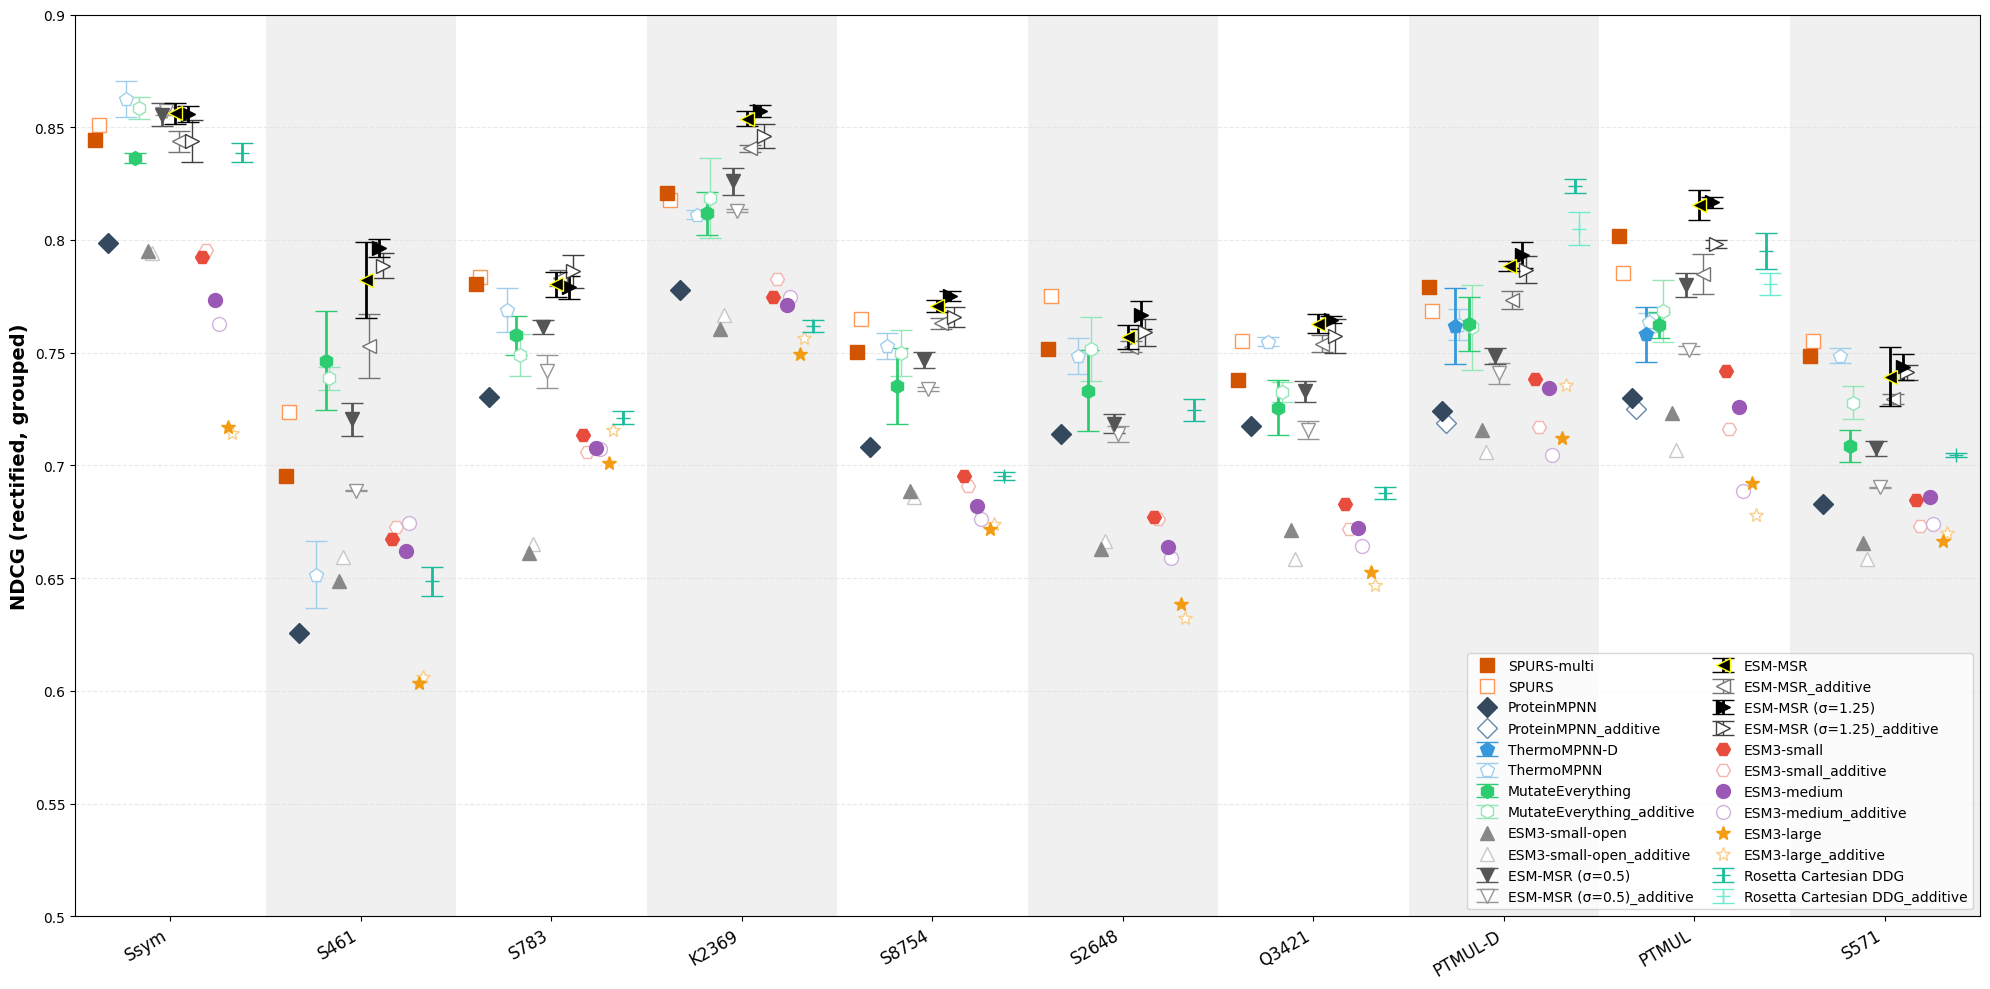

In [33]:
import analysis_utils_msr
fig, ax = analysis_utils_msr.visualize_model_performance(df_ndcg_grouped_custom_pos.loc[['Ssym', 'S461', 'S783', 'K2369', 'S8754', 'S2648', 'Q3421', 'PTMUL-D', 'PTMUL', 'S571']], 
                                    title=None, ylabel='NDCG (rectified, grouped)', highlighted_model='ESM-MSR', figsize=(20, 10), ylim=(0.5, 0.9), legend_loc='lower right', group_spread=(0.07),
                                    colors=['#d35400', '#34495e', '#3498db', '#2ecc71', "#888888", "#555555", "#333333", "#000000", '#e74c3c', '#9b59b6', '#f39c12', '#1abc9c', '#d35400',], additive_offset=0.02)

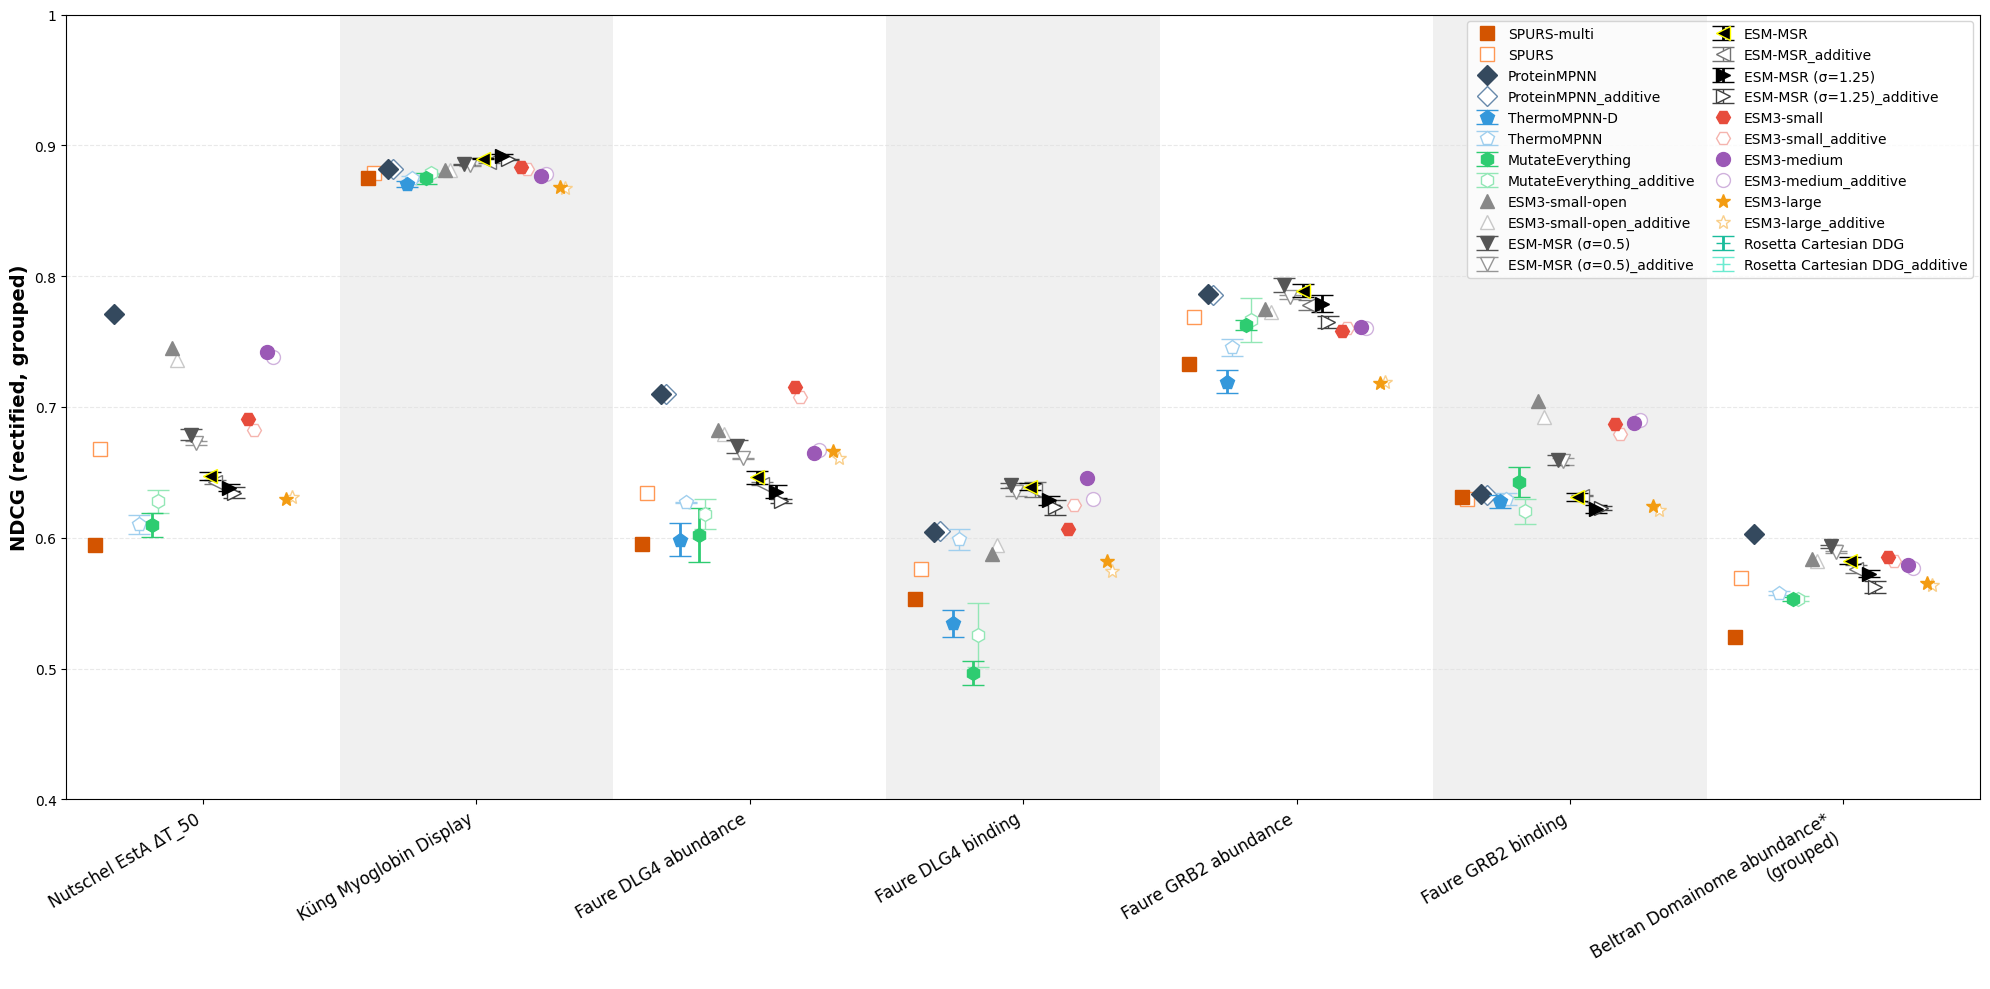

In [34]:
fig, ax = analysis_utils_msr.visualize_model_performance(df_ndcg_grouped_custom_pos.loc[['Nutschel EstA ΔT_50', 'Küng Myoglobin Display', 'Faure DLG4 abundance', 'Faure DLG4 binding', 'Faure GRB2 abundance', 'Faure GRB2 binding', 'Beltran Domainome abundance*\n(grouped)']], 
                                    title=None, ylabel='NDCG (rectified, grouped)', highlighted_model='ESM-MSR', figsize=(20, 10), ylim=(0.4,1), legend_loc='upper right', group_spread=(0.07),
                                    colors=['#d35400', '#34495e', '#3498db', '#2ecc71', "#888888", "#555555", "#333333", "#000000", '#e74c3c', '#9b59b6', '#f39c12', '#1abc9c', '#d35400',], additive_offset=0.02)

In [35]:
results['ssym']

,SPURS,SPURS-multi,ProteinMPNN,ThermoMPNN_1,ThermoMPNN_2,ThermoMPNN_3,MutateEverything_additive_1,MutateEverything_additive_2,MutateEverything_additive_3,MutateEverything_1,...,ESM3-large,Rosetta Cartesian DDG_1,Rosetta Cartesian DDG_2,Rosetta Cartesian DDG_3,mut_type,ddG_ML_esm,ddG_ML_me,ddG_ML_thermo,code,ground_truth
uid,,,,,,,,,,,,,,,,,,,,,
107LA_G44S,0.299109,-0.071098,1.583663,0.329867,0.423905,0.478700,0.245540,0.156222,0.106396,0.226256,...,7.582031,0.325510,0.326190,0.320068,G44S,0.5,-0.5,0.5,1L63,0.5
108LA_I44S,-0.440976,-0.794981,0.269440,-0.219323,-0.252505,-0.358556,-0.348797,-0.174106,-0.403685,-0.324788,...,6.464844,-0.987075,-0.987075,-0.987075,I44S,-0.3,0.3,-0.3,1L63,-0.3
109LA_K44S,-0.260952,-0.716214,-1.048504,-0.075490,-0.076200,-0.102194,-0.216011,0.051023,-0.217716,-0.192402,...,8.427734,-0.532653,-0.609524,-0.607483,K44S,-0.2,0.2,-0.2,1L63,-0.2
110LA_L44S,-0.309395,-0.780763,1.255608,-0.159791,-0.206419,-0.306643,-0.152406,0.041947,-0.106493,-0.096302,...,7.570312,-0.949320,-0.944898,-0.949320,L44S,-0.4,0.4,-0.4,1L63,-0.4
111LA_N44S,0.070881,-0.525196,0.218113,0.106670,0.096691,0.034578,0.051663,0.014656,-0.019643,-0.030167,...,7.398438,-0.267347,-0.267347,-0.267347,N44S,0.1,-0.1,0.1,1L63,0.1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
5PTIA_F22A,-1.995668,-1.355157,-3.331647,-1.723758,-1.698501,-2.050216,-2.264175,-1.507712,-1.694023,-2.084057,...,-4.562500,-3.078912,-3.084694,-3.080272,F22A,-1.2,1.2,-1.2,5PTI,-1.2
5PTIA_F45A,-3.203271,-1.931814,-5.421578,-2.234906,-2.146447,-2.350092,-3.529030,-3.396668,-3.688248,-3.587670,...,-7.070312,-3.932993,-3.933333,-3.935374,F45A,-6.9,6.9,-6.9,5PTI,-6.9
5PTIA_N43G,-1.686462,-1.708576,-5.378171,-1.426502,-1.494151,-1.438186,-2.322728,-1.849729,-2.229417,-2.315224,...,-5.832031,-4.677551,-4.680612,-5.269728,N43G,-5.7,5.7,-5.7,5PTI,-5.7


In [36]:
results['ssym']

,SPURS,SPURS-multi,ProteinMPNN,ThermoMPNN_1,ThermoMPNN_2,ThermoMPNN_3,MutateEverything_additive_1,MutateEverything_additive_2,MutateEverything_additive_3,MutateEverything_1,...,ESM3-large,Rosetta Cartesian DDG_1,Rosetta Cartesian DDG_2,Rosetta Cartesian DDG_3,mut_type,ddG_ML_esm,ddG_ML_me,ddG_ML_thermo,code,ground_truth
uid,,,,,,,,,,,,,,,,,,,,,
107LA_G44S,0.299109,-0.071098,1.583663,0.329867,0.423905,0.478700,0.245540,0.156222,0.106396,0.226256,...,7.582031,0.325510,0.326190,0.320068,G44S,0.5,-0.5,0.5,1L63,0.5
108LA_I44S,-0.440976,-0.794981,0.269440,-0.219323,-0.252505,-0.358556,-0.348797,-0.174106,-0.403685,-0.324788,...,6.464844,-0.987075,-0.987075,-0.987075,I44S,-0.3,0.3,-0.3,1L63,-0.3
109LA_K44S,-0.260952,-0.716214,-1.048504,-0.075490,-0.076200,-0.102194,-0.216011,0.051023,-0.217716,-0.192402,...,8.427734,-0.532653,-0.609524,-0.607483,K44S,-0.2,0.2,-0.2,1L63,-0.2
110LA_L44S,-0.309395,-0.780763,1.255608,-0.159791,-0.206419,-0.306643,-0.152406,0.041947,-0.106493,-0.096302,...,7.570312,-0.949320,-0.944898,-0.949320,L44S,-0.4,0.4,-0.4,1L63,-0.4
111LA_N44S,0.070881,-0.525196,0.218113,0.106670,0.096691,0.034578,0.051663,0.014656,-0.019643,-0.030167,...,7.398438,-0.267347,-0.267347,-0.267347,N44S,0.1,-0.1,0.1,1L63,0.1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
5PTIA_F22A,-1.995668,-1.355157,-3.331647,-1.723758,-1.698501,-2.050216,-2.264175,-1.507712,-1.694023,-2.084057,...,-4.562500,-3.078912,-3.084694,-3.080272,F22A,-1.2,1.2,-1.2,5PTI,-1.2
5PTIA_F45A,-3.203271,-1.931814,-5.421578,-2.234906,-2.146447,-2.350092,-3.529030,-3.396668,-3.688248,-3.587670,...,-7.070312,-3.932993,-3.933333,-3.935374,F45A,-6.9,6.9,-6.9,5PTI,-6.9
5PTIA_N43G,-1.686462,-1.708576,-5.378171,-1.426502,-1.494151,-1.438186,-2.322728,-1.849729,-2.229417,-2.315224,...,-5.832031,-4.677551,-4.680612,-5.269728,N43G,-5.7,5.7,-5.7,5PTI,-5.7


In [37]:
df_sym = results['ssym'].reset_index()
df_sym['wt_code'] = df_sym['code']
df_sym['code'] = df_sym['uid'].apply(lambda x: x.split('_')[0][:-1])
#df_sym['position'] = df_sym['mut_type'].str[1:-1].astype(int)
df_sym_rev = df_sym.loc[df_sym['code']!=df_sym['wt_code']]
df_sym_for = df_sym.loc[df_sym['code']==df_sym['wt_code']]
df_sym_for['uid2'] = df_sym_for['wt_code'] + '_' + df_sym_for['mut_type']
df_sym_for = df_sym_for.set_index('uid2')
df_sym_for = df_sym_for.drop(columns=['uid', 'code', 'wt_code', 'mut_type'])
df_sym_for

,SPURS,SPURS-multi,ProteinMPNN,ThermoMPNN_1,ThermoMPNN_2,ThermoMPNN_3,MutateEverything_additive_1,MutateEverything_additive_2,MutateEverything_additive_3,MutateEverything_1,...,ESM3-small,ESM3-medium,ESM3-large,Rosetta Cartesian DDG_1,Rosetta Cartesian DDG_2,Rosetta Cartesian DDG_3,ddG_ML_esm,ddG_ML_me,ddG_ML_thermo,ground_truth
uid2,,,,,,,,,,,,,,,,,,,,,
1AMQ_C180Y,-1.779581,-1.247848,-5.057691,-0.892225,-0.804074,-0.649290,-0.972029,-0.479557,-0.868697,-0.382846,...,-11.781250,-8.772461,-6.867188,-1.932313,-1.809864,-2.290136,-2.3,2.3,-2.3,-2.3
1AMQ_C180F,-1.508680,-0.971771,-5.282454,-0.722760,-0.677464,-0.437595,-0.552296,-0.423081,-0.586255,-0.098492,...,-10.898438,-9.365234,-7.343750,-8.001020,-9.232993,-9.225170,-1.6,1.6,-1.6,-1.6
1AMQ_C180W,-1.865367,-0.991156,-5.405746,-1.232206,-1.142232,-0.891763,-0.913353,-0.128473,-0.427713,-0.516004,...,-12.703125,-11.656250,-9.531250,-1.402381,-1.363605,-1.690476,-3.9,3.9,-3.9,-3.9
1AMQ_C180S,0.138561,-0.707929,-2.240716,-0.029416,-0.103480,0.102704,-0.233981,-0.628681,-0.140456,0.193454,...,-3.992188,-7.476562,-4.812500,-0.915646,-0.936054,-0.941156,-1.9,1.9,-1.9,-1.9
1BNI_S91A,-1.138973,-0.761650,-4.256861,-0.456861,-0.245097,-0.499580,-0.933912,-0.657525,-0.361552,-0.664234,...,-6.093750,-5.468750,-3.546875,0.051020,0.521429,0.718027,-1.8,1.8,-1.8,-1.8
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
5PTI_Y23A,-3.675945,-2.511314,-5.349803,-2.676788,-2.658009,-2.485431,-3.299113,-2.827299,-3.397907,-3.663168,...,-10.852783,-11.290222,-6.406250,-4.778912,-4.779252,-4.779252,-5.9,5.9,-5.9,-5.9
5PTI_F22A,-1.995668,-1.355157,-3.331647,-1.723758,-1.698501,-2.050216,-2.264175,-1.507712,-1.694023,-2.084057,...,-3.742188,-7.775391,-4.562500,-3.078912,-3.084694,-3.080272,-1.2,1.2,-1.2,-1.2
5PTI_F45A,-3.203271,-1.931814,-5.421578,-2.234906,-2.146447,-2.350092,-3.529030,-3.396668,-3.688248,-3.587670,...,-11.834717,-11.501465,-7.070312,-3.932993,-3.933333,-3.935374,-6.9,6.9,-6.9,-6.9


In [38]:
df_sym_rev['uid2'] = df_sym_rev['wt_code'] + '_' + df_sym_rev['mut_type'].str[-1] + df_sym_rev['mut_type'].str[1:-1] + df_sym_rev['mut_type'].str[0]
df_sym_rev = df_sym_rev.set_index('uid2')
df_sym_rev = df_sym_rev.drop(columns=['uid', 'code', 'wt_code', 'mut_type'])
df_sym_rev

,SPURS,SPURS-multi,ProteinMPNN,ThermoMPNN_1,ThermoMPNN_2,ThermoMPNN_3,MutateEverything_additive_1,MutateEverything_additive_2,MutateEverything_additive_3,MutateEverything_1,...,ESM3-small,ESM3-medium,ESM3-large,Rosetta Cartesian DDG_1,Rosetta Cartesian DDG_2,Rosetta Cartesian DDG_3,ddG_ML_esm,ddG_ML_me,ddG_ML_thermo,ground_truth
uid2,,,,,,,,,,,,,,,,,,,,,
1L63_S44G,0.299109,-0.071098,1.583663,0.329867,0.423905,0.478700,0.245540,0.156222,0.106396,0.226256,...,1.492188,2.501953,7.582031,0.325510,0.326190,0.320068,0.5,-0.5,0.5,0.5
1L63_S44I,-0.440976,-0.794981,0.269440,-0.219323,-0.252505,-0.358556,-0.348797,-0.174106,-0.403685,-0.324788,...,-0.635254,1.247559,6.464844,-0.987075,-0.987075,-0.987075,-0.3,0.3,-0.3,-0.3
1L63_S44K,-0.260952,-0.716214,-1.048504,-0.075490,-0.076200,-0.102194,-0.216011,0.051023,-0.217716,-0.192402,...,-1.236084,4.056641,8.427734,-0.532653,-0.609524,-0.607483,-0.2,0.2,-0.2,-0.2
1L63_S44L,-0.309395,-0.780763,1.255608,-0.159791,-0.206419,-0.306643,-0.152406,0.041947,-0.106493,-0.096302,...,-0.160034,1.719727,7.570312,-0.949320,-0.944898,-0.949320,-0.4,0.4,-0.4,-0.4
1L63_S44N,0.070881,-0.525196,0.218113,0.106670,0.096691,0.034578,0.051663,0.014656,-0.019643,-0.030167,...,0.541992,1.261719,7.398438,-0.267347,-0.267347,-0.267347,0.1,-0.1,0.1,0.1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2LZM_R96M,1.189510,-0.436186,4.558629,0.298094,0.292050,0.164820,0.475416,0.285765,0.293861,0.129959,...,5.658203,8.724243,8.430664,0.904082,0.770408,0.182993,2.7,-2.7,2.7,2.7
2LZM_R96H,1.541855,-0.026362,4.174042,0.758488,0.802349,0.759084,0.534267,0.655106,0.326871,0.318195,...,0.312500,3.359375,-1.671875,0.344558,0.335374,0.330952,3.1,-3.1,3.1,3.1
2LZM_R96W,0.988813,-0.309533,4.704620,0.009856,-0.017527,-0.090957,-0.421815,-0.072185,-0.722409,-0.628401,...,6.343750,7.030273,4.678711,-1.663605,-1.346259,-1.811224,4.5,-4.5,4.5,4.5


In [39]:
df_sym_for.loc[df_sym_for.index.str.contains('1CEY')]

,SPURS,SPURS-multi,ProteinMPNN,ThermoMPNN_1,ThermoMPNN_2,ThermoMPNN_3,MutateEverything_additive_1,MutateEverything_additive_2,MutateEverything_additive_3,MutateEverything_1,...,ESM3-small,ESM3-medium,ESM3-large,Rosetta Cartesian DDG_1,Rosetta Cartesian DDG_2,Rosetta Cartesian DDG_3,ddG_ML_esm,ddG_ML_me,ddG_ML_thermo,ground_truth
uid2,,,,,,,,,,,,,,,,,,,,,
1CEY_D11A,0.078394,-0.540639,0.792954,-0.081792,0.222154,0.108261,-1.132732,-1.118774,-1.165563,-1.083025,...,-4.751953,-6.807617,-2.335938,-1.581293,-1.581633,-1.848980,2.5,-2.5,2.5,2.5
1CEY_D12A,0.367107,-0.210520,-0.855212,0.132490,0.281508,0.157691,-0.107391,-0.219424,0.194771,-0.297879,...,-2.926758,-6.500000,-3.593750,-0.675170,-0.413946,-0.296939,2.7,-2.7,2.7,2.7
1CEY_D56A,-0.105851,-0.466643,0.090761,-0.066748,0.064828,-0.003897,0.360845,-0.303310,0.289161,-0.505388,...,-5.616211,-5.738281,-2.859375,-1.963605,-1.702381,-2.007823,3.3,-3.3,3.3,3.3


In [40]:
#df_sym_rev.loc[df_sym_rev.index.str.contains('1BNI')]
df_sym_rev.loc[df_sym_rev.index.str.contains('1CEY')]
#df_sym_rev.loc[df_sym_rev.index.str.contains('1EY0')]

,SPURS,SPURS-multi,ProteinMPNN,ThermoMPNN_1,ThermoMPNN_2,ThermoMPNN_3,MutateEverything_additive_1,MutateEverything_additive_2,MutateEverything_additive_3,MutateEverything_1,...,ESM3-small,ESM3-medium,ESM3-large,Rosetta Cartesian DDG_1,Rosetta Cartesian DDG_2,Rosetta Cartesian DDG_3,ddG_ML_esm,ddG_ML_me,ddG_ML_thermo,ground_truth
uid2,,,,,,,,,,,,,,,,,,,,,
1CEY_D13A,1.334084,-0.056746,5.390996,0.496412,0.939342,0.702899,0.415911,-0.321053,0.176744,-0.128402,...,6.289062,6.414062,1.718750,-3.589116,-3.564966,-3.439456,-2.5,2.5,-2.5,-2.5
1CEY_D11A,-0.527115,-1.008629,4.583488,-0.447273,-0.585412,-0.225413,-0.329596,-0.320636,-0.074360,-0.204699,...,8.247955,8.285156,1.046875,-1.968367,-1.968367,-1.968367,-2.7,2.7,-2.7,-2.7
1CEY_D56A,0.254369,-0.545022,4.526256,-0.108542,0.050086,-0.197958,-0.010929,0.084991,0.292355,0.049295,...,8.517578,7.793945,3.109375,-3.188095,-2.285374,-3.189796,-3.3,3.3,-3.3,-3.3


In [41]:
df_sym_rev = df_sym_rev.rename({'1BNI_F5L': '1BNI_F7L'})
df_sym_rev = df_sym_rev.rename({'1CEY_D13A': '1CEY_D12A'}) #{'1CEY_D12A': '1CEY_D11A', '1CEY_D13A': '1CEY_D10A'}
df_sym_rev = df_sym_rev.rename({'1EY0_K111G': '1EY0_K116G'})

In [42]:
df_sym_comb = df_sym_for.join(df_sym_rev, lsuffix='_dir', rsuffix='_inv')
df_sym_comb

,SPURS_dir,SPURS-multi_dir,ProteinMPNN_dir,ThermoMPNN_1_dir,ThermoMPNN_2_dir,ThermoMPNN_3_dir,MutateEverything_additive_1_dir,MutateEverything_additive_2_dir,MutateEverything_additive_3_dir,MutateEverything_1_dir,...,ESM3-small_inv,ESM3-medium_inv,ESM3-large_inv,Rosetta Cartesian DDG_1_inv,Rosetta Cartesian DDG_2_inv,Rosetta Cartesian DDG_3_inv,ddG_ML_esm_inv,ddG_ML_me_inv,ddG_ML_thermo_inv,ground_truth_inv
uid2,,,,,,,,,,,,,,,,,,,,,
1AMQ_C180Y,-1.779581,-1.247848,-5.057691,-0.892225,-0.804074,-0.649290,-0.972029,-0.479557,-0.868697,-0.382846,...,11.039062,7.755859,2.875000,-1.204422,-1.145238,-1.170408,2.3,-2.3,2.3,2.3
1AMQ_C180F,-1.508680,-0.971771,-5.282454,-0.722760,-0.677464,-0.437595,-0.552296,-0.423081,-0.586255,-0.098492,...,10.679688,8.511719,4.210938,-1.711905,-1.718707,-1.710544,1.6,-1.6,1.6,1.6
1AMQ_C180W,-1.865367,-0.991156,-5.405746,-1.232206,-1.142232,-0.891763,-0.913353,-0.128473,-0.427713,-0.516004,...,11.906250,10.613281,3.843750,-1.808163,-1.643537,-1.922789,3.9,-3.9,3.9,3.9
1AMQ_C180S,0.138561,-0.707929,-2.240716,-0.029416,-0.103480,0.102704,-0.233981,-0.628681,-0.140456,0.193454,...,3.718750,6.585938,4.515625,0.794218,0.821088,0.797279,1.9,-1.9,1.9,1.9
1BNI_S91A,-1.138973,-0.761650,-4.256861,-0.456861,-0.245097,-0.499580,-0.933912,-0.657525,-0.361552,-0.664234,...,4.539062,5.046875,3.140625,-0.814966,-0.830612,-0.830952,1.8,-1.8,1.8,1.8
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
5PTI_Y23A,-3.675945,-2.511314,-5.349803,-2.676788,-2.658009,-2.485431,-3.299113,-2.827299,-3.397907,-3.663168,...,10.438477,8.691406,4.656250,2.608503,2.558844,2.809864,5.9,-5.9,5.9,5.9
5PTI_F22A,-1.995668,-1.355157,-3.331647,-1.723758,-1.698501,-2.050216,-2.264175,-1.507712,-1.694023,-2.084057,...,1.085938,-1.929688,1.296875,2.625510,2.290816,2.437075,1.2,-1.2,1.2,1.2
5PTI_F45A,-3.203271,-1.931814,-5.421578,-2.234906,-2.146447,-2.350092,-3.529030,-3.396668,-3.688248,-3.587670,...,8.310547,8.177734,4.460938,3.495238,4.261565,3.874150,6.9,-6.9,6.9,6.9


In [43]:
df_sym_comb.drop(df_sym_comb.dropna().index)

,SPURS_dir,SPURS-multi_dir,ProteinMPNN_dir,ThermoMPNN_1_dir,ThermoMPNN_2_dir,ThermoMPNN_3_dir,MutateEverything_additive_1_dir,MutateEverything_additive_2_dir,MutateEverything_additive_3_dir,MutateEverything_1_dir,...,ESM3-small_inv,ESM3-medium_inv,ESM3-large_inv,Rosetta Cartesian DDG_1_inv,Rosetta Cartesian DDG_2_inv,Rosetta Cartesian DDG_3_inv,ddG_ML_esm_inv,ddG_ML_me_inv,ddG_ML_thermo_inv,ground_truth_inv
uid2,,,,,,,,,,,,,,,,,,,,,


In [44]:
import pandas as pd
import numpy as np
from scipy import stats
import re

def calculate_antisymmetry_and_bias_series(df, model_groups):
    """
    Calculates Antisymmetry (Pearson r) and Bias (<delta>) for models in a DataFrame.
    
    Formulae:
    - Antisymmetry: Pearson correlation(dir, inv)
    - Bias: Mean((dir + inv) / 2)
    
    Capabilities:
    - Auto-detects replicates (e.g., 'esm_0_dir' and 'esm_0_inv').
    - Returns flat Series compatible with 'create_metric_comparison_chart_epistatic'.
    
    Parameters:
    -----------
    df : pd.DataFrame
        Dataframe containing columns with suffixes '_dir' and '_inv'.
    model_groups : list
        List of model prefixes (e.g., ['esm', 'mpnn']).
        
    Returns:
    --------
    (pd.Series, pd.Series)
        Tuple of (s_antisymmetry, s_bias).
    """
    
    anti_data = {}
    bias_data = {}
    
    def _calc_single_pair(dframe, c_dir, c_inv):
        """Helper to compute metrics for one pair of columns."""
        # Drop NaNs pairwise
        subset = dframe[[c_dir, c_inv]].dropna()
        if len(subset) < 2:
            return None, None, 0
            
        vals_dir = subset[c_dir].values
        vals_inv = subset[c_inv].values
        
        # 1. Antisymmetry (Pearson r)
        # Note: If variance is 0 (constant prediction), Pearson is undefined (NaN)
        with np.errstate(all='ignore'):
            r_val, _ = stats.pearsonr(vals_dir, vals_inv)
            
        # 2. Bias (<delta>)
        bias_val = np.mean(vals_dir + vals_inv) / 2.0
        
        return r_val, bias_val, len(subset)

    for model in model_groups:
        # --- 1. Check for Replicates (model_0_dir, model_1_dir, ...) ---
        # Regex to find any column matching "{model}_{number}_dir"
        pattern = re.compile(rf"^{re.escape(model)}_(\d+)_dir$")
        
        replicate_suffixes = []
        for col in df.columns:
            match = pattern.match(col)
            if match:
                replicate_suffixes.append(match.group(1))
        
        if replicate_suffixes:
            # Calculate metrics for each replicate individually
            # This allows the plotter to show error bars for the metric itself
            for rep in replicate_suffixes:
                col_dir = f"{model}_{rep}_dir"
                col_inv = f"{model}_{rep}_inv"
                
                # Ensure inverse column exists
                if col_inv not in df.columns:
                    continue
                    
                r, b, n = _calc_single_pair(df, col_dir, col_inv)
                
                if n > 0:
                    # Key format: "model_0"
                    key = f"{model}_{rep}"
                    
                    if r is not None: anti_data[key] = r
                    if b is not None: bias_data[key] = b
                    
                    # Store N count for the plotter (key: "model_0_n")
                    anti_data[f"{key}_n"] = n
                    bias_data[f"{key}_n"] = n
                    
        # --- 2. Check for Single Instance (model_dir) ---
        # Only process if explicitly present (even if replicates exist, 
        # sometimes a base model exists too)
        col_dir = f"{model}_dir"
        col_inv = f"{model}_inv"
        
        if col_dir in df.columns and col_inv in df.columns:
            r, b, n = _calc_single_pair(df, col_dir, col_inv)
            if n > 0:
                # Key format: "model"
                if r is not None: anti_data[model] = r
                if b is not None: bias_data[model] = b
                
                # Store N count (key: "model_n")
                anti_data[f"{model}_n"] = n
                bias_data[f"{model}_n"] = n

    return pd.Series(anti_data), pd.Series(bias_data)

array([[<Axes: title={'center': 'ESM3-small-open_dir'}>]], dtype=object)

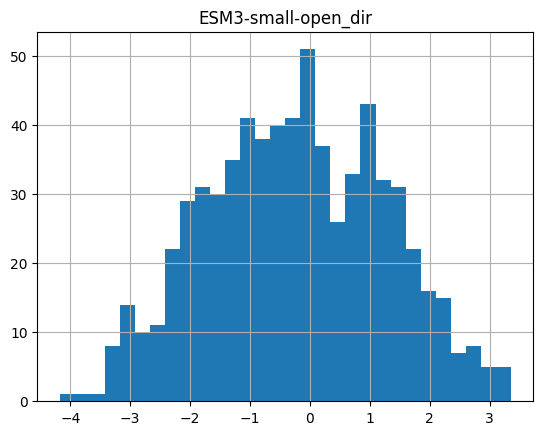

In [45]:
pd.concat([df_sym_comb[['ESM3-small-open_dir']] , df_sym_comb[['ESM3-small-open_inv']].rename({'ESM3-small-open_inv': 'ESM3-small-open_dir'}, axis=1)]).hist(bins=30)

In [46]:
df_sym_comb[['ThermoMPNN_1_dir']]

,ThermoMPNN_1_dir
uid2,
1AMQ_C180Y,-0.892225
1AMQ_C180F,-0.722760
1AMQ_C180W,-1.232206
1AMQ_C180S,-0.029416
1BNI_S91A,-0.456861
...,...
5PTI_Y23A,-2.676788
5PTI_F22A,-1.723758
5PTI_F45A,-2.234906


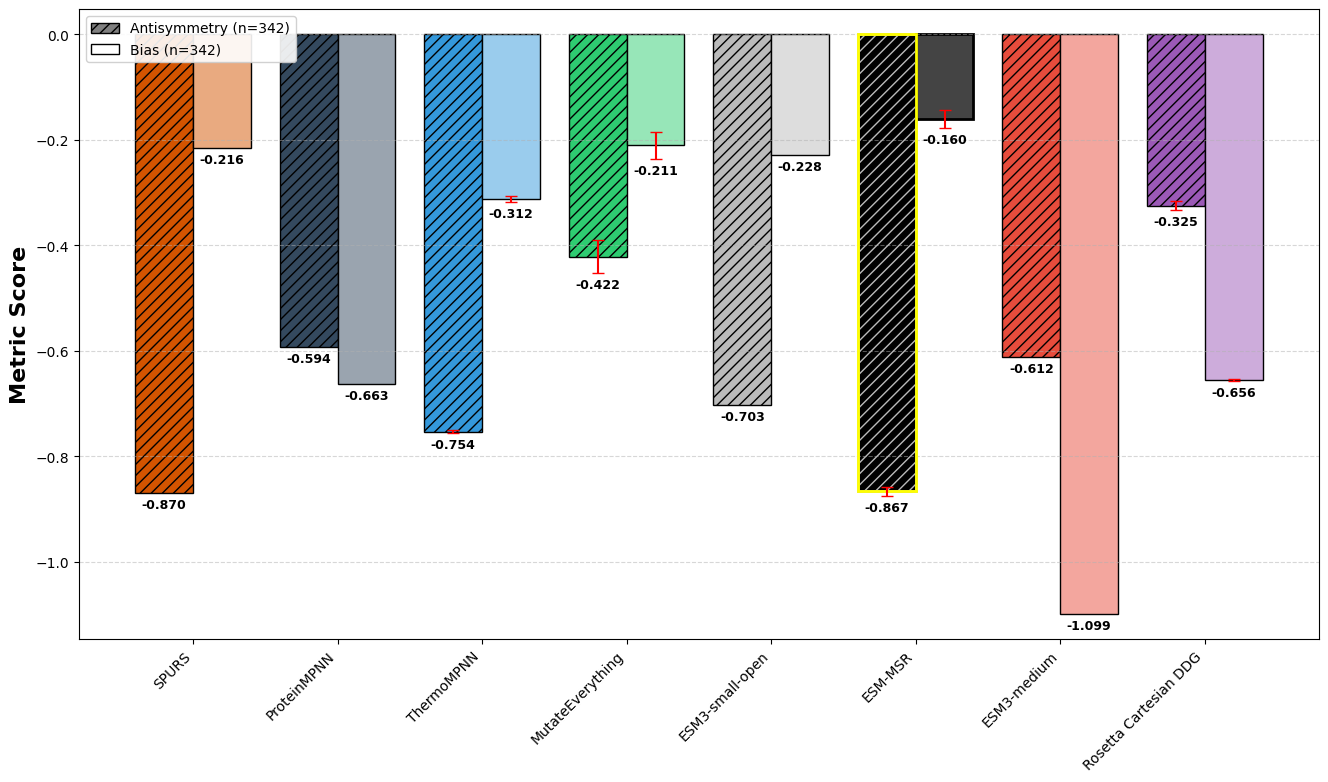

In [47]:
import analysis_utils_msr
import importlib
importlib.reload(analysis_utils_msr)

model_list = ['SPURS', 'ProteinMPNN', 'ThermoMPNN', 'MutateEverything', 'ESM3-small-open', 'ESM-MSR', 'ESM3-medium', 'Rosetta Cartesian DDG'] # 'ESM3-small', 'ESM3-medium', 'ESM3-large',

# 1. Generate the series
s_anti, s_bias = calculate_antisymmetry_and_bias_series(df_sym_comb, model_list)

# 2. Plot using the "Two Series" mode
fig, ax = analysis_utils_msr.create_metric_comparison_chart_epistatic(
    series=s_anti,
    series2=s_bias,
    model_groups=model_list,
    title="",
    y_label="Metric Score",
    series_names=("Antisymmetry", "Bias"),
    highlighted_model='ESM-MSR',
    fontsize_multiplier=1.,
    figsize=(16,10),
    show_significance=False,
    legend_loc='upper left',
    is_grouped=False
    #colors=['#d35400', '#34495e', '#3498db', '#2ecc71', "#bbbbbb", '#1abc9c']
)

In [48]:
import importlib
importlib.reload(analysis_utils_msr)
from analysis_utils_msr import density_scatter, calculate_epistasis, add_additive_predictions

df_wu = results['GB1_Wu_2016_binding_domain']
df_wu_ref = pd.read_csv('/home/sareeves/software/esm-msr/data/preprocessed/GB1_Wu_2016_binding_domain.csv', index_col=0)
df_wu_ref['id'] = df_wu_ref['code'] + '_' + df_wu_ref['mut_info']
df_wu_ref = df_wu_ref.set_index('id')
df_wu = df_wu_ref[['Fitness', 'Abundance', 'HD']].join(df_wu)

df_wu['ddG_ML'] = df_wu['Fitness']
#min_val = df_wu.loc[df_wu['ddG_ML']>0, 'ddG_ML'].min()
#df_wu['ddG_ML'] += min_val
df_wu = df_wu.loc[df_wu['ddG_ML']>0]
df_wu['ddG_ML'] = np.log10(df_wu['ddG_ML'])
df_wu['ddG_pred'] = df_wu['ddG_ML']

df_wu = add_additive_predictions(df_wu.loc[df_wu['HD']==1], df_wu).rename(columns={'ddG_pred_additive': 'ddG_ML_add'})
df_wu = df_wu.T.drop_duplicates().T
df_wu = calculate_epistasis(df_wu, val_col=None)
df_wu = df_wu.rename(columns={'ddG_ML_dddG': 'dddG_ML'})
#df_wu = df_wu[[c for c in df_wu.columns if not '_additive' in c]]
df_wu

,Fitness,Abundance,HD,SPURS,SPURS-multi,ProteinMPNN_additive,ProteinMPNN,ThermoMPNN_1,ThermoMPNN_2,ThermoMPNN_3,...,ESM3-large_additive,ESM3-small,ESM3-medium,ESM3-large,code,mut_type,ddG_ML_me,ddG_ML_thermo,ddG_ML,ddG_ML_add
id,,,,,,,,,,,,,,,,,,,,,
GB1_V39A,0.06191,0.000367,1,-1.335301,-1.417465,-3.858448,-3.858448,-1.233589,-1.112716,-1.28195,...,-8.53125,-3.192078,-2.75,-8.007812,GB1,V39A,-0.06191,0.06191,-1.208242,-1.208242
GB1_V39C,0.242237,0.009166,1,-0.882483,-0.94719,-4.252182,-4.252182,-0.49339,-0.374908,-0.458946,...,-9.007812,-3.131348,-4.186523,-7.636719,GB1,V39C,-0.242237,0.242237,-0.615759,-0.615759
GB1_V39D,0.006472,0.000679,1,-2.316198,-2.048575,-4.001671,-4.001671,-1.697326,-1.493111,-1.698431,...,-12.34375,-3.276367,-5.062988,-9.789062,GB1,V39D,-0.006472,0.006472,-2.188955,-2.188955
GB1_V39E,0.032719,0.009069,1,-2.137121,-1.844287,-4.041277,-4.041277,-1.498644,-1.441197,-1.67252,...,-9.28125,1.175781,-1.554688,-7.703125,GB1,V39E,-0.032719,0.032719,-1.485198,-1.485198
GB1_V39F,0.377101,0.001467,1,0.028618,-0.588013,-3.832241,-3.832241,-0.238575,-0.218351,-0.327377,...,-8.328125,-2.443359,-4.410156,-8.046875,GB1,V39F,-0.377101,0.377101,-0.423543,-0.423543
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
GB1_V39Y:D40Y:G41Y:V54R,0.00135,0.002189,4,-4.922779,-3.739684,-16.606225,-15.390179,NaN,NaN,NaN,...,-8.570312,-1.945312,-3.623047,-5.113281,GB1,V39Y:D40Y:G41Y:V54R,-0.00135,NaN,-2.869613,-4.625126
GB1_V39Y:D40Y:G41Y:V54S,0.004421,0.002006,4,-4.609638,-4.245296,-17.078558,-15.545582,NaN,NaN,NaN,...,-8.570312,-1.945312,-3.623047,-5.113281,GB1,V39Y:D40Y:G41Y:V54S,-0.004421,NaN,-2.354509,-2.719969
GB1_V39Y:D40Y:G41Y:V54T,0.0212,0.001952,4,-4.395459,-4.440325,-16.890073,-15.336368,NaN,NaN,NaN,...,-8.570312,-1.945312,-3.623047,-5.113281,GB1,V39Y:D40Y:G41Y:V54T,-0.0212,NaN,-1.673668,-2.626231


In [49]:
df_wu_clean = df_wu[['ddG_ML_add', 'ddG_ML', 'HD']].dropna()
df_wu_clean = df_wu_clean.loc[df_wu_clean['HD']<4]

ax = density_scatter(df_wu_clean['ddG_ML_add'], df_wu_clean['ddG_ML'], point_alpha=0.05, s=8, cmap="plasma")

TypeError: ufunc 'isfinite' not supported for the input types, and the inputs could not be safely coerced to any supported types according to the casting rule ''safe''

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

def plot_replicate_performance(data_dict, dodge_width=0.4, plot_lines=False, colors=('#3498db', '#2ecc71', '#e74c3c', '#9b59b6', '#f39c12', '#1abc9c', '#d35400', '#34495e'), markers=('s', 'D', 'p', '^', 'v', '<', '>', 'h', 'H', 'o', '*', '+', 'x')):
    """
    Plots mean Spearman correlations and standard deviations for total
    ddG predictions across dataframes with x-axis dodging and visible error bars.
    """
    
    if not data_dict:
        raise NotImplementedError("NotImplementedError: Logic for empty data_dict not implemented.")
        
    first_df = next(iter(data_dict.values()))
    if 'HD' not in first_df.columns:
        raise AssertionError("AssertionError: 'HD' column not found in the first dataframe.")
        
    counts = first_df.groupby('HD').size().rename('Count').reset_index()
    all_hds = np.array(sorted(counts['HD'].unique()))
    
    fig, ax1 = plt.subplots(1, 1, figsize=(10, 4), dpi=300)
    
    ax1_count = ax1.twinx()
    ax1_count.bar(counts['HD'], counts['Count'], alpha=0.15, color='gray')
    ax1_count.set_yscale('log')
    ax1_count.tick_params(axis='y', labelcolor='gray')
    ax1_count.set_ylabel('Sample Count (N) [Log Scale]', color='gray')
    
    num_datasets = len(data_dict)
    offsets = np.linspace(-dodge_width/2, dodge_width/2, num_datasets) if num_datasets > 1 else [0]

    for idx, (prefix, df) in enumerate(data_dict.items()):
        color = colors[idx % len(colors)]
        marker = markers[idx % len(markers)]
        current_offset = offsets[idx]
        
        # Use linestyle instead of modifying fmt to ensure error bars remain visible
        ls = '-' if plot_lines else ''
        
        ddg_cols = [c for c in df.columns if c.startswith(prefix) and 'dddG' not in c]

        if not ddg_cols:
            print(f"Warning: No valid prediction columns found for prefix '{prefix}'. Skipping.")
            continue
            
        if 'ddG_ML' not in df.columns:
            raise AssertionError(f"AssertionError: Ground truth column 'ddG_ML' not found in dataframe for '{prefix}'.")
            
        means_ddg, stds_ddg = [], []
        
        for hd in all_hds:
            hd_mask = df['HD'] == hd
            subset = df[hd_mask]
            
            if len(subset) < 2:
                means_ddg.append(np.nan)
                stds_ddg.append(np.nan)
                continue
            
            corr_ddg = [subset[col].corr(subset['ddG_ML'], method='spearman') for col in ddg_cols]
            
            means_ddg.append(np.nanmean(corr_ddg) if len(corr_ddg) > 0 else np.nan)
            stds_ddg.append(np.nanstd(corr_ddg, ddof=1) if len(corr_ddg) > 1 else 0)
            
        dodged_hds = all_hds + current_offset
        
        # elinewidth ensures the vertical stem is visible regardless of plot_lines
        # capthick ensures the horizontal whiskers (caps) are visible
        ax1.errorbar(dodged_hds, means_ddg, yerr=stds_ddg, 
                     fmt=marker, linestyle=ls, color=color, 
                     linewidth=2, elinewidth=1.5, capsize=4, capthick=1.5, 
                     label=f'{prefix}')
        
    ax1.set_xlabel('Hamming Distance (HD)')
    ax1.set_ylim(0, 1) 
    ax1.set_xticks(all_hds)
    ax1.grid(True, linestyle=':', alpha=0.7)
    ax1.legend(loc='upper right', framealpha=0.9, fontsize=9)
    ax1.set_ylabel('Mean Spearman Correlation (ρ) ± SD')
    
    plt.tight_layout()
    plt.show()
    
    return fig, ax1

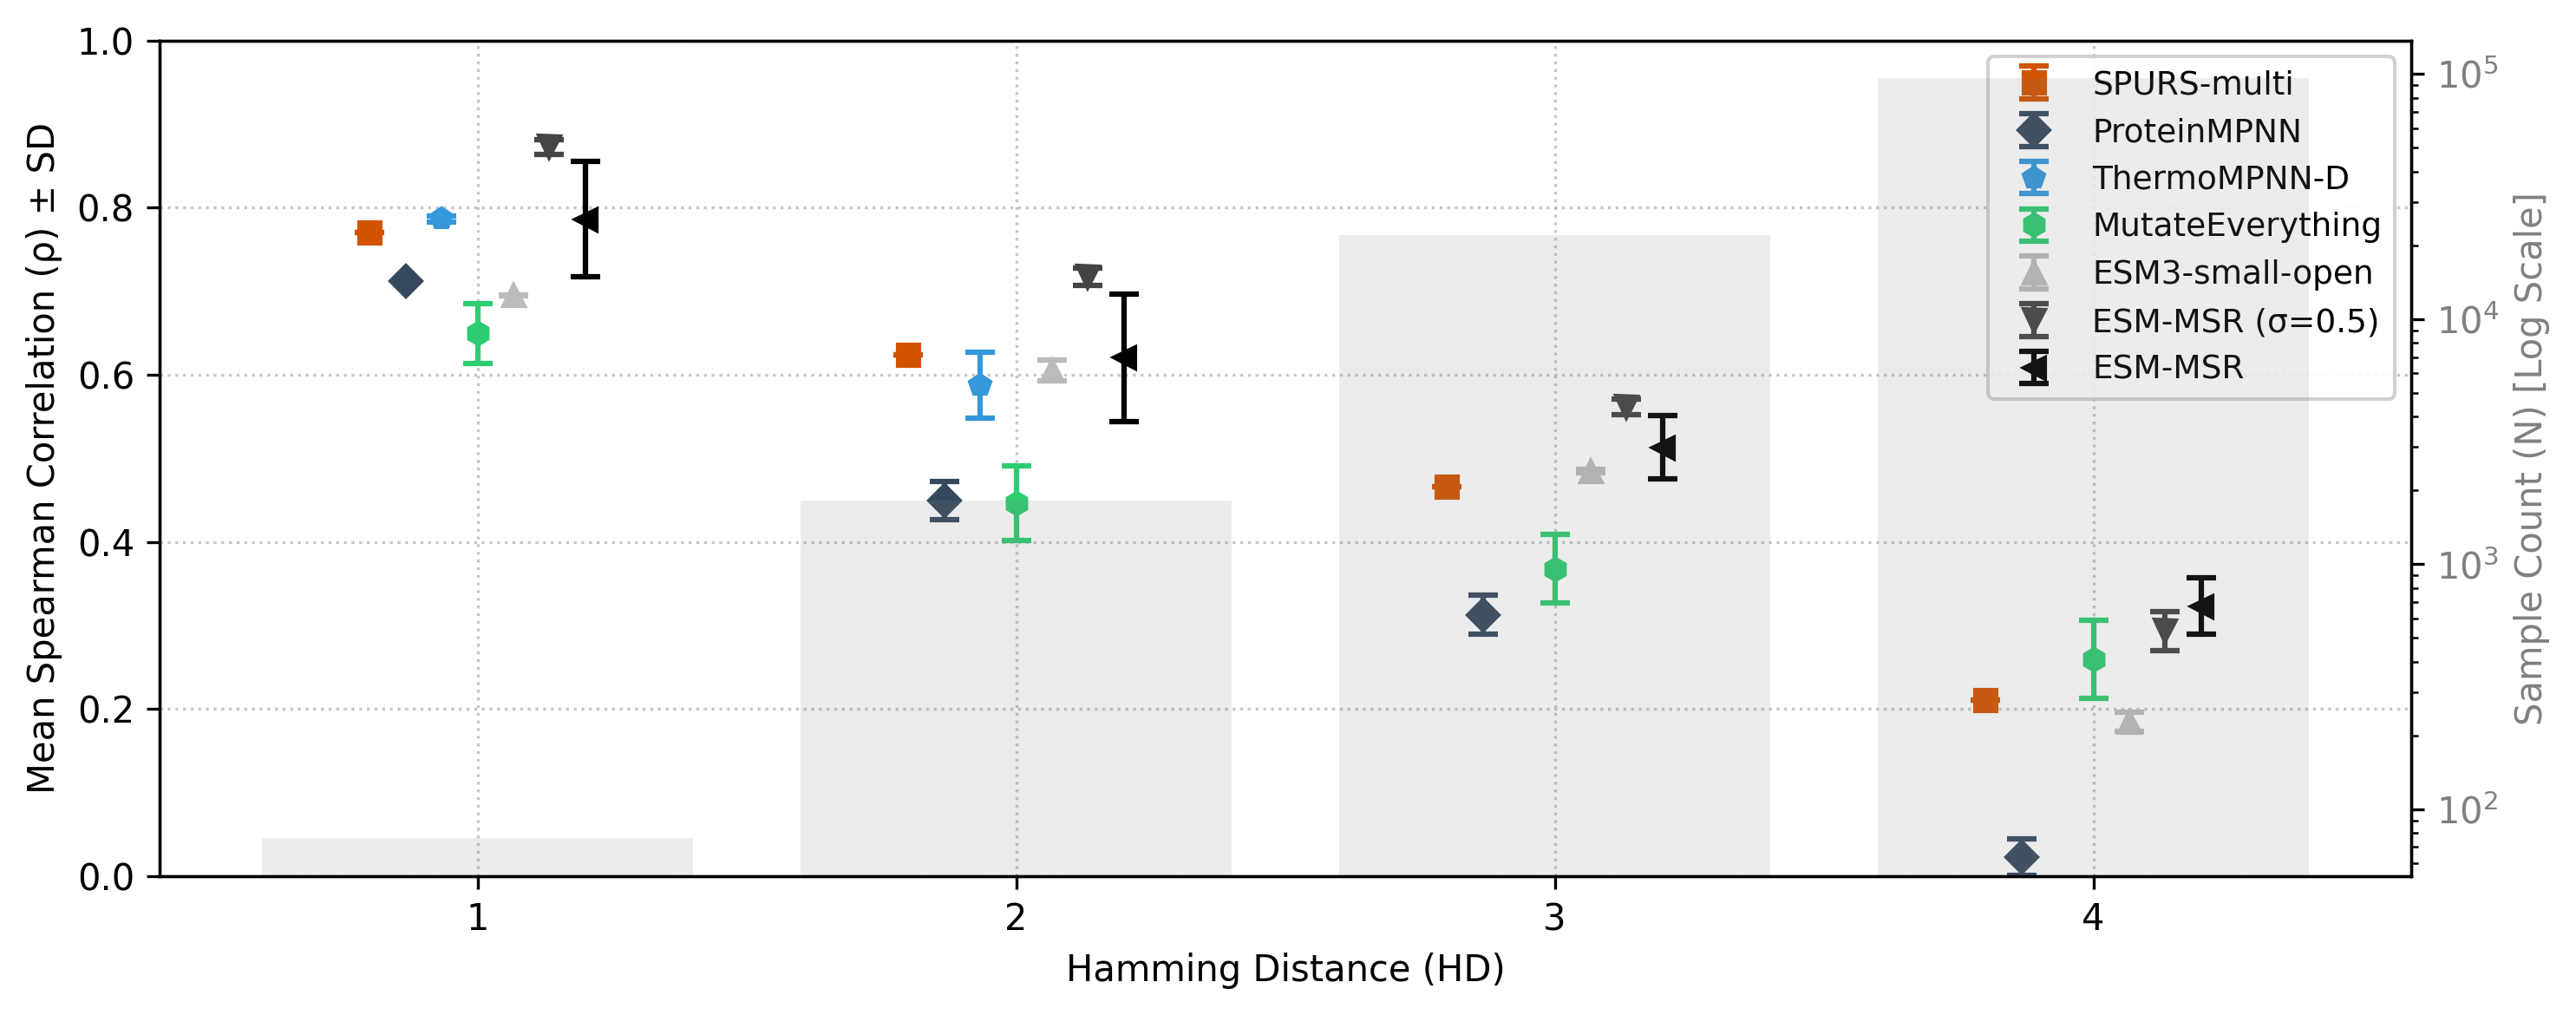

(<Figure size 3000x1200 with 2 Axes>,
 <Axes: xlabel='Hamming Distance (HD)', ylabel='Mean Spearman Correlation (ρ) ± SD'>)

In [ ]:
data_dict = {'SPURS-multi': df_wu, 'ProteinMPNN': df_wu, 'ThermoMPNN-D': df_wu.loc[df_wu['HD']<=2], 'MutateEverything': df_wu, 'ESM3-small-open': df_wu, 'ESM-MSR (σ=0.5)': df_wu, 'ESM-MSR': df_wu} #, 'ddG_ML_add': df_wu}
plot_replicate_performance(data_dict, colors=('#d35400', '#34495e', '#3498db', '#2ecc71', "#bbbbbb", "#444444", "#000000", '#f39c12', '#9b59b6',  '#1abc9c', '#3498db',), markers=('s', 'D', 'p', 'h', '^', 'v', '<', '>', 'h', 'H', 'o', '*', '+', 'x'))

array([[<Axes: title={'center': 'ddG_ML'}>,
        <Axes: title={'center': 'dddG_ML'}>]], dtype=object)

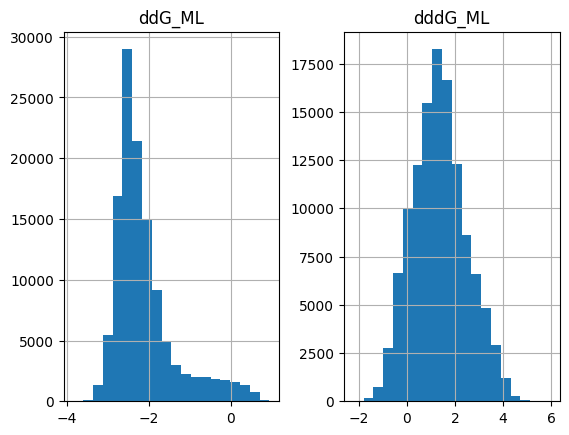

In [ ]:
df_wu_clean = df_wu[['ddG_ML', 'dddG_ML']].dropna()
df_wu_clean[['ddG_ML', 'dddG_ML']].dropna().hist(bins=20)

<Axes: xlabel='ddG_ML', ylabel='dddG_ML'>

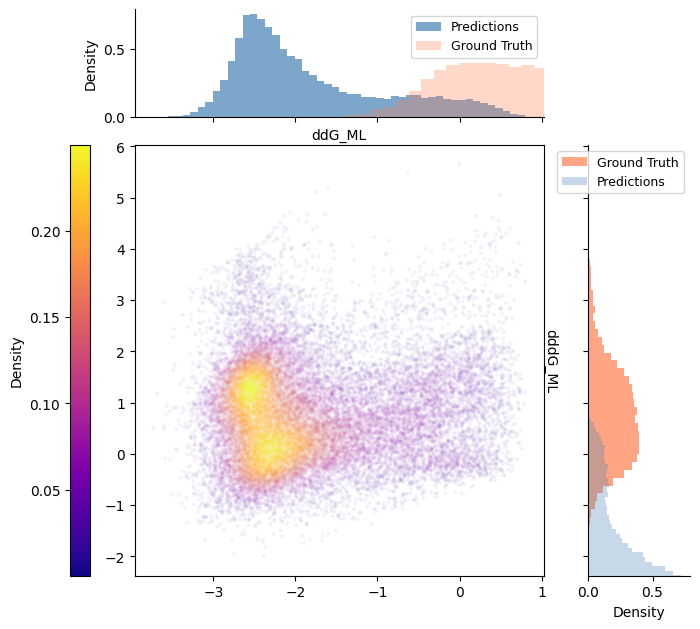

In [ ]:
from analysis_utils_msr import density_scatter

df_wu_clean = df_wu[['ddG_ML', 'dddG_ML', 'HD']].dropna()
df_wu_clean = df_wu_clean.loc[df_wu_clean['HD']<4]

density_scatter(df_wu_clean['ddG_ML'], df_wu_clean['dddG_ML'], point_alpha=0.05, s=8, cmap="plasma", stats=False)

<Axes: xlabel='ddG_ML_add', ylabel='dddG_ML'>

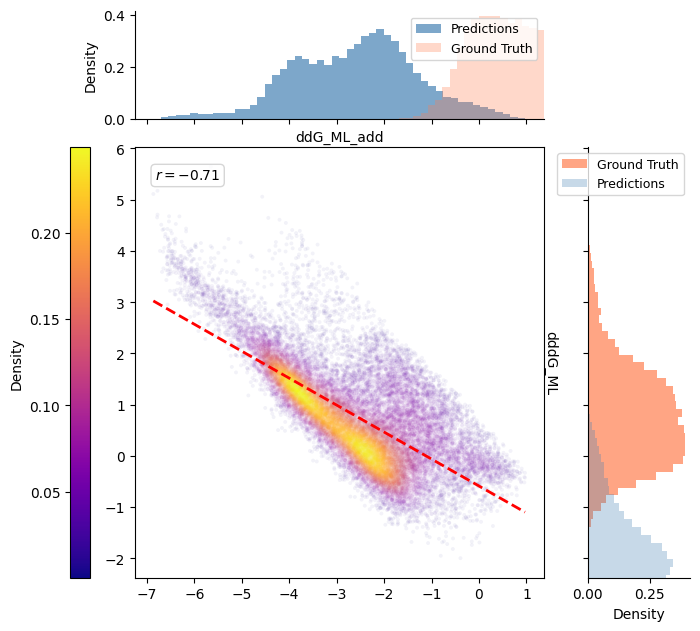

In [ ]:
df_wu_clean = df_wu[['ddG_ML_add', 'dddG_ML', 'HD']].dropna()
df_wu_clean = df_wu_clean.loc[df_wu_clean['HD']<4]

density_scatter(df_wu_clean['ddG_ML_add'], df_wu_clean['dddG_ML'], point_alpha=0.05, s=8, cmap="plasma", stats=True)

In [ ]:
df_wu = results['GB1_Wu_2016_binding_domain']
df_wu_ref = pd.read_csv('/home/sareeves/software/esm-msr/data/preprocessed/GB1_Wu_2016_binding_domain.csv', index_col=0)
df_wu_ref['id'] = df_wu_ref['code'] + '_' + df_wu_ref['mut_info']
df_wu_ref = df_wu_ref.set_index('id')
df_wu = df_wu_ref[['Fitness', 'Abundance', 'HD']].join(df_wu)

df_wu['ddG_ML'] = df_wu['Abundance']
#min_val = df_wu.loc[df_wu['ddG_ML']>0, 'ddG_ML'].min()
#df_wu['ddG_ML'] += min_val
df_wu = df_wu.loc[df_wu['ddG_ML']>0]
df_wu['ddG_ML'] = np.log10(df_wu['ddG_ML'])
df_wu['ddG_pred'] = df_wu['ddG_ML']

df_wu = add_additive_predictions(df_wu.loc[df_wu['HD']==1], df_wu).rename(columns={'ddG_pred_additive': 'ddG_ML_add'})
df_wu = calculate_epistasis(df_wu, val_col=None)
df_wu = df_wu.rename(columns={'ddG_ML_dddG': 'dddG_ML'})
#df_wu = df_wu[[c for c in df_wu.columns if not '_additive' in c]]
df_wu

,Fitness,Abundance,HD,SPURS,SPURS-multi,ProteinMPNN_additive,ProteinMPNN,ThermoMPNN_1,ThermoMPNN_2,ThermoMPNN_3,...,ddG_ML_thermo_additive,ddG_ML_thermo_dddG,ground_truth_additive,ground_truth_dddG,ddG_ML_additive,dddG_ML,ddG_pred_additive,ddG_pred_dddG,ddG_ML_add_additive,ddG_ML_add_dddG
id,,,,,,,,,,,,,,,,,,,,,
GB1_V39A,0.061910,0.000367,1,-1.335301,-1.417465,NaN,-3.858448,-1.233589,-1.112716,-1.281950,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
GB1_V39C,0.242237,0.009166,1,-0.882483,-0.947190,NaN,-4.252182,-0.493390,-0.374908,-0.458946,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
GB1_V39D,0.006472,0.000679,1,-2.316198,-2.048575,NaN,-4.001671,-1.697326,-1.493111,-1.698431,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
GB1_V39E,0.032719,0.009069,1,-2.137121,-1.844287,NaN,-4.041277,-1.498644,-1.441197,-1.672520,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
GB1_V39F,0.377101,0.001467,1,0.028618,-0.588013,NaN,-3.832241,-0.238575,-0.218351,-0.327377,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
GB1_V39Y:D40Y:G41Y:V54R,0.001350,0.002189,4,-4.922779,-3.739684,-16.888142,-15.390179,NaN,NaN,NaN,...,3.983366,NaN,3.983366,-3.982015,-9.158751,6.499003,-9.158751,6.499003,-9.158751,0.0
GB1_V39Y:D40Y:G41Y:V54S,0.004421,0.002006,4,-4.609638,-4.245296,-16.877470,-15.545582,NaN,NaN,NaN,...,4.472958,NaN,4.472958,-4.468537,-9.111158,6.413427,-9.111158,6.413427,-9.111158,0.0
GB1_V39Y:D40Y:G41Y:V54T,0.021200,0.001952,4,-4.395459,-4.440325,-17.010039,-15.336368,NaN,NaN,NaN,...,4.592387,NaN,4.592387,-4.571187,-9.157670,6.448105,-9.157670,6.448105,-9.157670,0.0


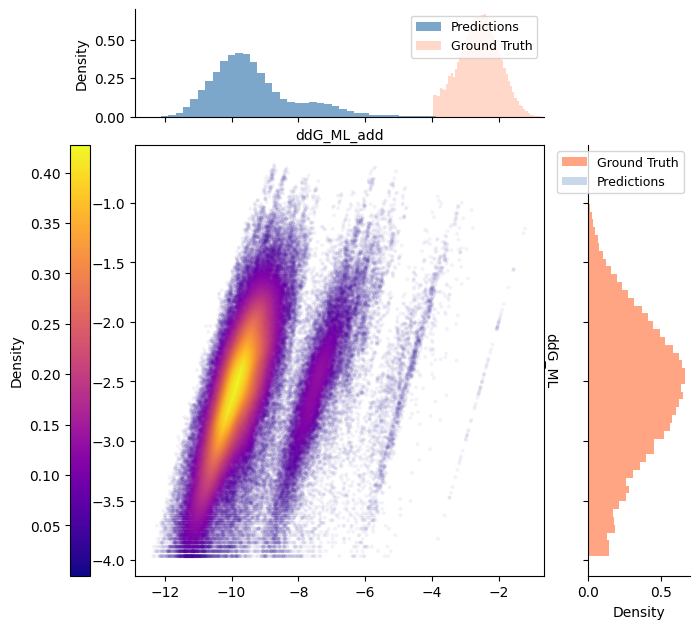

In [ ]:
df_wu_clean = df_wu[['ddG_ML_add', 'ddG_ML', 'HD']].dropna()
#df_wu_clean = df_wu_clean.loc[df_wu_clean['HD']<4]

ax = density_scatter(df_wu_clean['ddG_ML_add'], df_wu_clean['ddG_ML'], point_alpha=0.05, s=8, cmap="plasma")

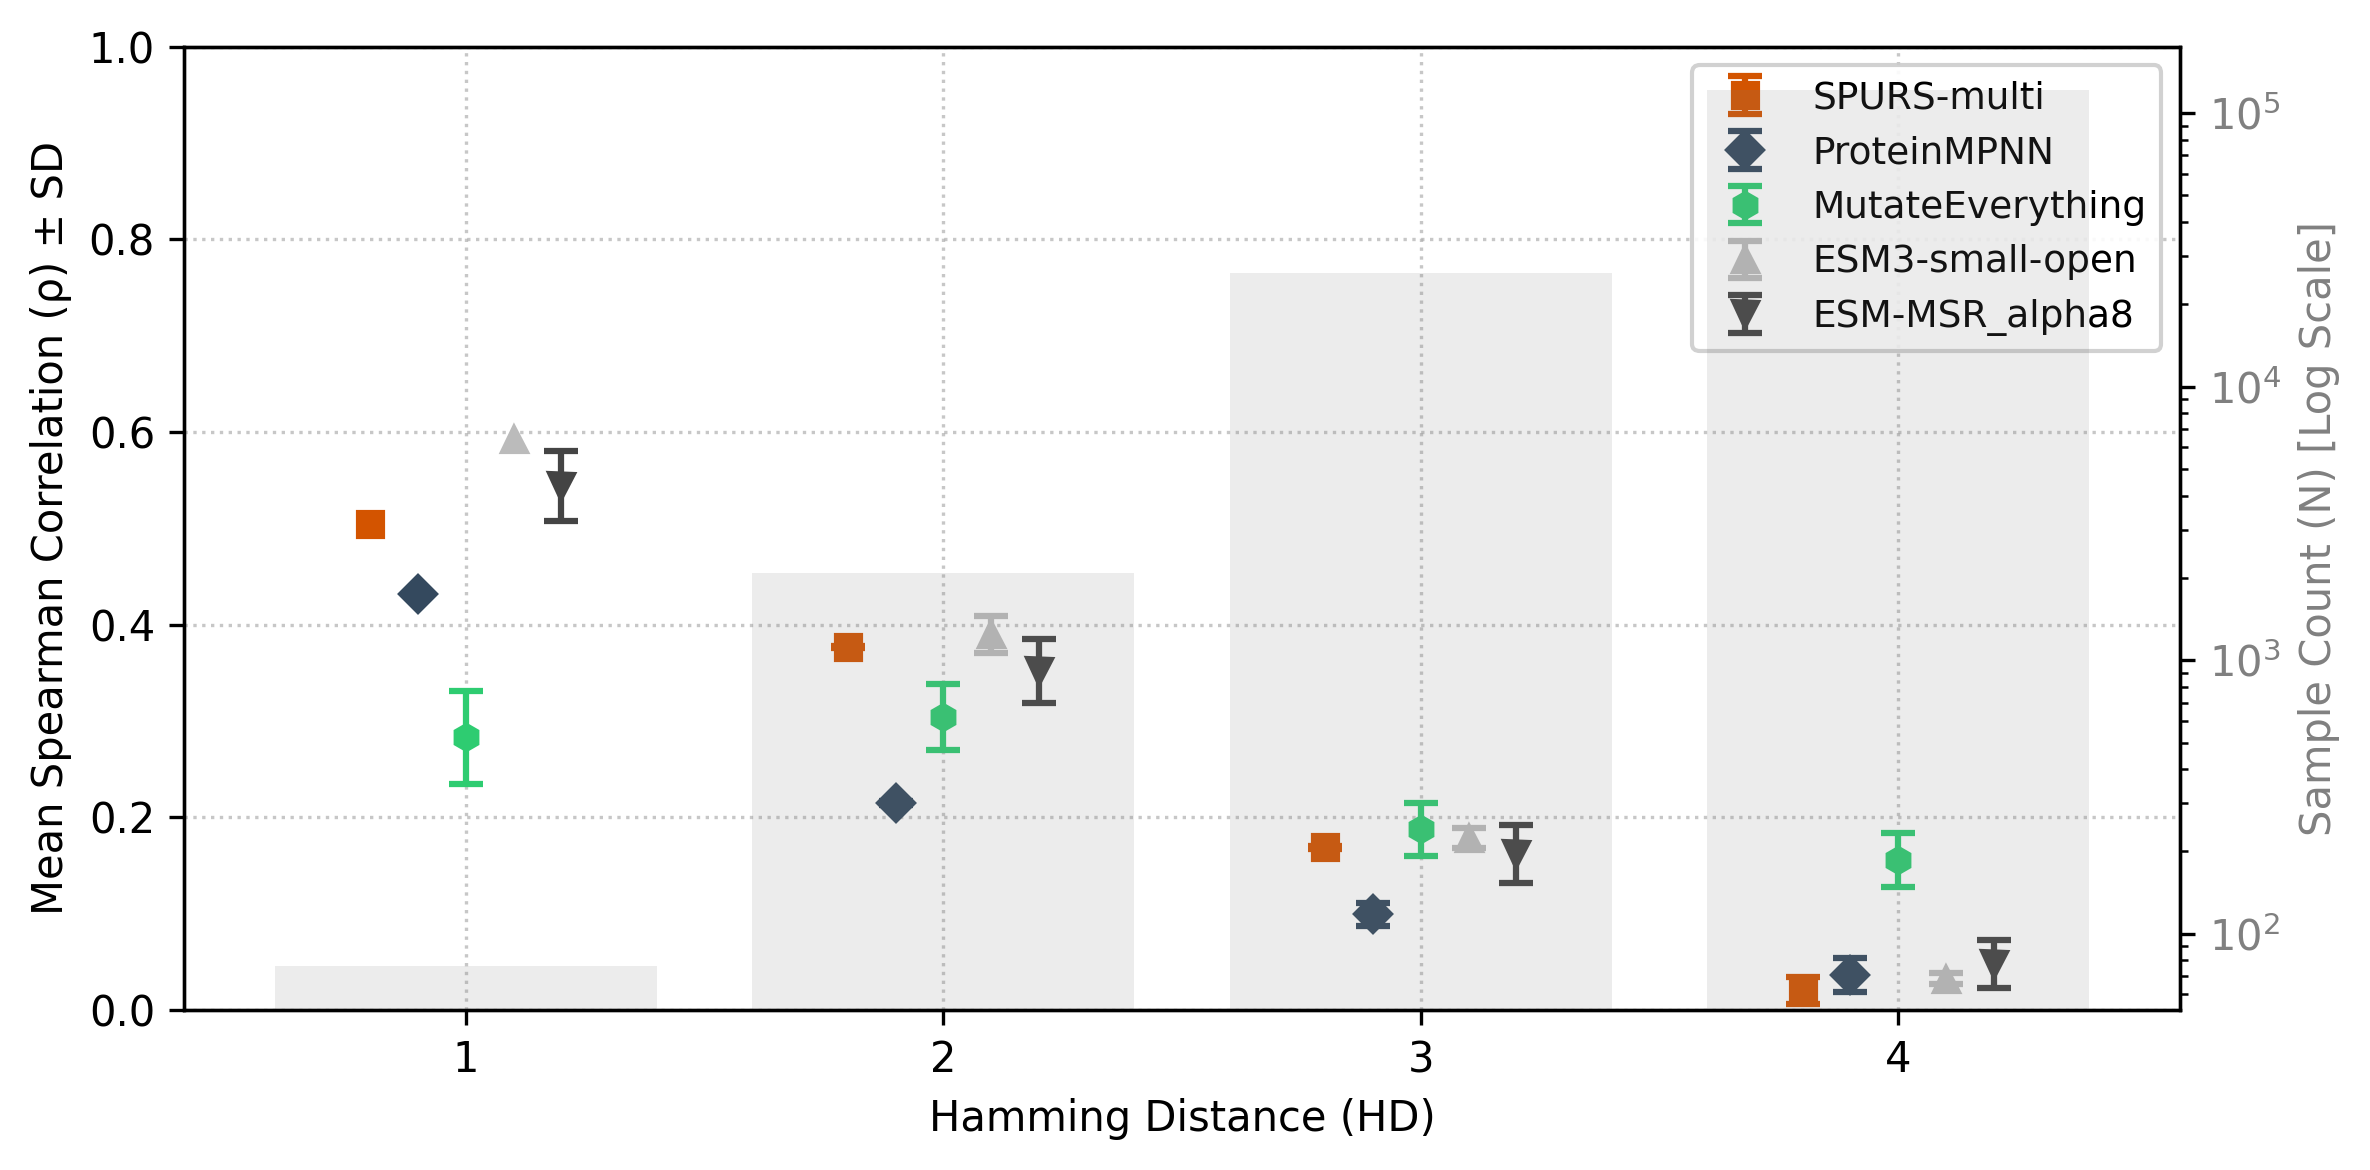

(<Figure size 2400x1200 with 2 Axes>,
 <Axes: xlabel='Hamming Distance (HD)', ylabel='Mean Spearman Correlation (ρ) ± SD'>)

In [ ]:
data_dict = {'SPURS-multi': df_wu, 'ProteinMPNN': df_wu, 'MutateEverything': df_wu, 'ESM3-small-open': df_wu, 'ESM-MSR_alpha8': df_wu} #, 'ddG_ML_add': df_wu}
plot_replicate_performance(data_dict, colors=('#d35400', '#34495e',  '#2ecc71', "#bbbbbb", "#444444",  '#f39c12', '#9b59b6',  '#1abc9c', '#3498db',), markers=('s', 'D', 'h', '^', 'v', '<', '>', 'h', 'H', 'o', '*', '+', 'x'))

array([[<Axes: title={'center': 'ddG_ML'}>,
        <Axes: title={'center': 'dddG_ML'}>]], dtype=object)

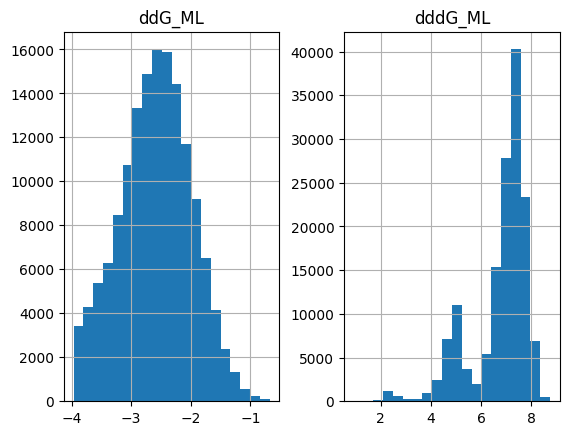

In [ ]:
df_wu_clean = df_wu[['ddG_ML', 'dddG_ML']].dropna()
df_wu_clean[['ddG_ML', 'dddG_ML']].dropna().hist(bins=20)

<Axes: xlabel='ddG_ML', ylabel='dddG_ML'>

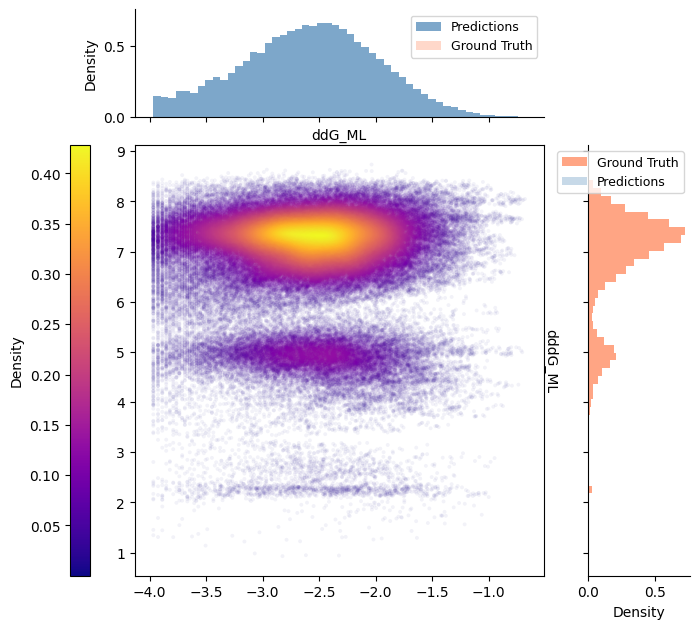

In [ ]:
from analysis_utils_msr import density_scatter

df_wu_clean = df_wu[['ddG_ML', 'dddG_ML']].dropna()

density_scatter(df_wu_clean['ddG_ML'], df_wu_clean['dddG_ML'], point_alpha=0.05, s=8, cmap="plasma", stats=False)

<Axes: xlabel='ddG_ML_add', ylabel='dddG_ML'>

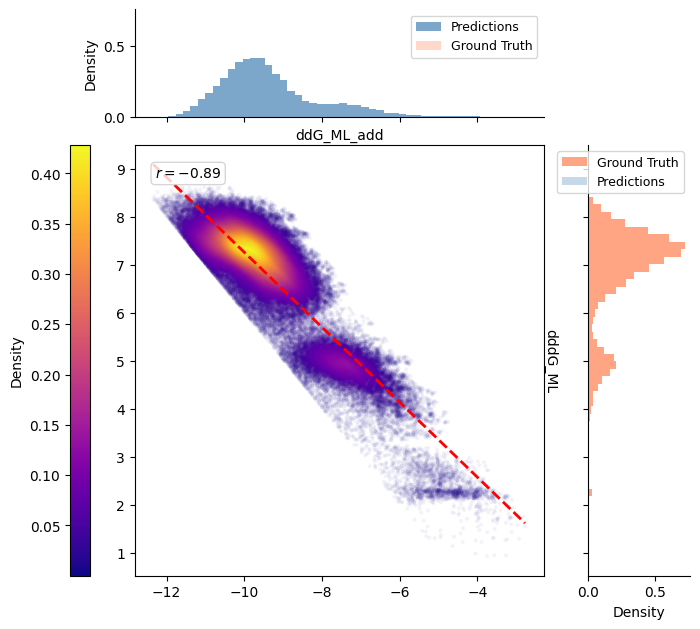

In [ ]:
df_wu_clean = df_wu[['ddG_ML_add', 'dddG_ML']].dropna()

density_scatter(df_wu_clean['ddG_ML_add'], df_wu_clean['dddG_ML'], point_alpha=0.05, s=8, cmap="plasma", stats=True)